# 🎵 스펙트로그램 패턴 및 파동 분석

이 노트북에서는 Mel Spectrogram을 사용하여 다양한 패턴과 파동 분석을 수행합니다.

## 📋 목차
1. **데이터 로드 및 스펙트로그램 추출**
2. **기본 통계 분석** (max, min, mean, std, median, quartiles)
3. **시간 축 패턴 분석** (각 주파수 밴드의 시간적 변화)
4. **주파수 축 패턴 분석** (각 시간 프레임의 주파수 분포)
5. **에너지 분포 분석**
6. **주파수 밴드별 통계 비교**
7. **시간 구간별 통계 분석**
8. **스펙트로그램 변화율 분석** (gradient)
9. **PCA 시각화 및 군집 분석**



In [117]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import random

# 과학 계산
from scipy import ndimage
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 공통 유틸리티
from utils import setup_plotting, get_data_dir, get_state_names

# 머신러닝
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, 
    normalized_mutual_info_score,
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 프로젝트 모듈
from app.ml.features.extractor import AudioFeatureExtractor, AudioConfig

# 시각화 설정
setup_plotting()

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ 라이브러리 로드 완료!")
print(f"🖥️ Device: {device}")



✅ 라이브러리 로드 완료!
🖥️ Device: cpu


## 1. 데이터 로드 및 스펙트로그램 추출



In [118]:
# ============================================================
# 데이터 로드 및 스펙트로그램 추출
# ============================================================

import librosa

# 피처 추출기 초기화
config = AudioConfig()
feature_extractor = AudioFeatureExtractor(config)

# 데이터 경로
data_dir = get_data_dir()
all_files = []
all_states = []

# 상태 매핑
from utils import get_state_mapping
state_mapping = get_state_mapping()
state_names = get_state_names()

# 파일 수집
print("📂 데이터 파일 수집 중...")
for state_dir in sorted(data_dir.iterdir()):
    if not state_dir.is_dir() or state_dir.name == 'augmented':
        continue
    
    state_name = state_dir.name
    state_idx = state_mapping.get(state_name, -1)
    
    if state_idx == -1:
        continue
    
    for problem_dir in state_dir.iterdir():
        if not problem_dir.is_dir() or problem_dir.name == 'combined':
            continue
        
        for file_path in problem_dir.glob('*.wav'):
            all_files.append(file_path)
            all_states.append(state_idx)

print(f"✅ 총 {len(all_files)}개 파일 수집 완료!")

def remove_silent_frames(spectrogram_2d, energy_threshold_percentile=5):
    """
    스펙트로그램에서 소리가 없는 부분(무음 구간)을 제거
    
    Args:
        spectrogram_2d: (frequency, time) 스펙트로그램
        energy_threshold_percentile: 에너지 임계값 (백분위수)
    
    Returns:
        trimmed_spectrogram: 무음 구간이 제거된 스펙트로그램
    """
    # 각 시간 프레임별 에너지 계산 (주파수 평균)
    time_frame_energy = np.mean(spectrogram_2d, axis=0)  # (time,)
    
    # 에너지 임계값 계산 (백분위수 기반)
    energy_threshold = np.percentile(time_frame_energy, energy_threshold_percentile)
    
    # 에너지가 임계값보다 높은 프레임만 유지
    # 추가로 음수 값이 많은 프레임도 제거 (dB 스케일에서 -80dB 이하는 무음으로 간주)
    valid_frames = (time_frame_energy > energy_threshold) & (time_frame_energy > -75)
    
    # 유효한 프레임이 없으면 원본 반환
    if not np.any(valid_frames):
        return spectrogram_2d
    
    # 무음 구간 제거
    trimmed_spectrogram = spectrogram_2d[:, valid_frames]
    
    return trimmed_spectrogram

# 스펙트로그램 추출 (2D 배열로 유지)
print("\n🔄 스펙트로그램 추출 중 (무음 구간 제거 포함)...")
all_spectrograms = []
all_spectrograms_2d = []  # 2D 배열로 저장 (패턴 분석용)
all_original_durations = []  # 원본 파일 길이 저장
all_trimmed_lengths = []  # 무음 제거 후 길이 저장

for file_path in tqdm(all_files, desc="스펙트로그램 추출"):
    try:
        # 실제 오디오 파일 길이 확인
        actual_duration = librosa.get_duration(path=str(file_path))
        all_original_durations.append(actual_duration)
        
        # 오디오 로드 (실제 길이만큼만)
        y, sr = librosa.load(
            str(file_path),
            sr=config.sample_rate,
            duration=None  # 전체 길이 로드
        )
        
        # Mel Spectrogram 추출 (2D 배열: frequency × time)
        mel_spec = feature_extractor.extract_mel_spectrogram(y, sr)
        
        # 무음 구간 제거
        mel_spec_trimmed = remove_silent_frames(mel_spec, energy_threshold_percentile=5)
        all_trimmed_lengths.append(mel_spec_trimmed.shape[1])
        
        # 2D 배열 저장 (패턴 분석용) - 나중에 정규화
        all_spectrograms_2d.append(mel_spec_trimmed)
        
    except Exception as e:
        print(f"⚠️  오류: {file_path} - {e}")
        # 오류 시 0으로 채운 배열 추가
        default_shape = (128, 216)  # 기본 shape
        all_spectrograms_2d.append(np.zeros(default_shape))
        all_spectrograms.append(np.zeros(128 * 216))
        all_original_durations.append(0.0)
        all_trimmed_lengths.append(0)

# 모든 스펙트로그램을 동일한 시간 프레임 길이로 맞추기
print("\n🔄 시간 프레임 길이 정규화 중...")
max_time_frames = max([s.shape[1] for s in all_spectrograms_2d])
normalized_spectrograms_2d = []

for spec_2d in all_spectrograms_2d:
    if spec_2d.shape[1] < max_time_frames:
        # 패딩 추가 (최소값으로)
        padding = np.zeros((spec_2d.shape[0], max_time_frames - spec_2d.shape[1]))
        padding.fill(spec_2d.min())
        spec_padded = np.concatenate([spec_2d, padding], axis=1)
    else:
        spec_padded = spec_2d
    normalized_spectrograms_2d.append(spec_padded)
    
    # Flatten: 2D → 1D 벡터로 변환 (PCA/클러스터링용)
    all_spectrograms.append(spec_padded.flatten())

# NumPy 배열로 변환
X_flat = np.array(all_spectrograms)  # (samples, features) - flatten된 버전
X_2d = np.array(normalized_spectrograms_2d)  # (samples, frequency, time) - 2D 버전
y_states = np.array(all_states)

state_names = ['braking', 'idle', 'startup']

print(f"\n✅ 스펙트로그램 추출 완료!")
print(f"   X_flat shape: {X_flat.shape}")
print(f"   X_2d shape: {X_2d.shape}")
print(f"   y_states shape: {y_states.shape}")
print(f"\n📊 오디오 파일 길이 통계:")
print(f"   원본 평균 길이: {np.mean(all_original_durations):.2f}초")
print(f"   원본 최대 길이: {np.max(all_original_durations):.2f}초")
print(f"   원본 최소 길이: {np.min(all_original_durations):.2f}초")
print(f"\n📊 무음 제거 후 시간 프레임 통계:")
print(f"   평균 시간 프레임: {np.mean(all_trimmed_lengths):.1f}프레임")
print(f"   최대 시간 프레임: {np.max(all_trimmed_lengths)}프레임")
print(f"   최소 시간 프레임: {np.min(all_trimmed_lengths)}프레임")
print(f"   정규화된 시간 프레임: {max_time_frames}프레임")



📂 데이터 파일 수집 중...
✅ 총 949개 파일 수집 완료!

🔄 스펙트로그램 추출 중 (무음 구간 제거 포함)...


스펙트로그램 추출: 100%|██████████| 949/949 [00:11<00:00, 79.72it/s]



🔄 시간 프레임 길이 정규화 중...

✅ 스펙트로그램 추출 완료!
   X_flat shape: (949, 8960)
   X_2d shape: (949, 128, 70)
   y_states shape: (949,)

📊 오디오 파일 길이 통계:
   원본 평균 길이: 1.54초
   원본 최대 길이: 1.70초
   원본 최소 길이: 1.50초

📊 무음 제거 후 시간 프레임 통계:
   평균 시간 프레임: 62.2프레임
   최대 시간 프레임: 70프레임
   최소 시간 프레임: 17프레임
   정규화된 시간 프레임: 70프레임


## 2. 기본 통계 분석 (max, min, mean, std, median, quartiles)



In [119]:
# ============================================================
# 기본 통계 분석 (max, min, mean, std, median, quartiles)
# ============================================================

def extract_statistical_features(spectrogram_2d):
    """
    스펙트로그램의 다양한 통계적 특징을 추출
    
    Returns:
        dict: 통계적 특징들
    """
    features = {}
    
    # 전체 스펙트로그램 통계
    features['mean'] = np.mean(spectrogram_2d)
    features['std'] = np.std(spectrogram_2d)
    features['max'] = np.max(spectrogram_2d)
    features['min'] = np.min(spectrogram_2d)
    features['median'] = np.median(spectrogram_2d)
    features['q25'] = np.percentile(spectrogram_2d, 25)
    features['q75'] = np.percentile(spectrogram_2d, 75)
    features['iqr'] = features['q75'] - features['q25']  # Interquartile Range
    features['range'] = features['max'] - features['min']
    features['skewness'] = np.mean(((spectrogram_2d - features['mean']) / features['std']) ** 3) if features['std'] > 0 else 0
    features['kurtosis'] = np.mean(((spectrogram_2d - features['mean']) / features['std']) ** 4) if features['std'] > 0 else 0
    
    # 에너지 관련
    features['energy'] = np.sum(spectrogram_2d ** 2)
    features['rms'] = np.sqrt(np.mean(spectrogram_2d ** 2))  # Root Mean Square
    
    return features

# 모든 샘플에 대해 통계 특징 추출
print("🔄 통계 특징 추출 중...")
statistical_features = []

for spec_2d in tqdm(X_2d, desc="통계 특징 추출"):
    features = extract_statistical_features(spec_2d)
    statistical_features.append(features)

# DataFrame으로 변환
df_stats = pd.DataFrame(statistical_features)

print(f"\n✅ 통계 특징 추출 완료! (Shape: {df_stats.shape})")
print(f"\n📊 추출된 통계 특징 목록:")
print(df_stats.columns.tolist())

# 상태별 통계 요약
print("\n" + "=" * 70)
print("📊 상태별 통계 요약")
print("=" * 70)
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    print(f"\n🔵 {state_name.upper()}:")
    print(df_stats[mask].describe().round(4))



🔄 통계 특징 추출 중...


통계 특징 추출:   0%|          | 0/949 [00:00<?, ?it/s]

통계 특징 추출: 100%|██████████| 949/949 [00:01<00:00, 544.63it/s]



✅ 통계 특징 추출 완료! (Shape: (949, 13))

📊 추출된 통계 특징 목록:
['mean', 'std', 'max', 'min', 'median', 'q25', 'q75', 'iqr', 'range', 'skewness', 'kurtosis', 'energy', 'rms']

📊 상태별 통계 요약

🔵 BRAKING:
           mean       std       max       min    median       q25       q75  \
count  153.0000  153.0000  153.0000  153.0000  153.0000  153.0000  153.0000   
mean   -41.4117   16.6502   -0.0085  -73.2293  -39.4711  -49.7026  -29.5937   
std     11.1807    2.6643    0.1047    7.4139   13.9460   12.0928   12.8432   
min    -73.4445   10.2344   -1.2955  -80.0000  -80.0000  -80.0000  -67.9744   
25%    -45.8226   14.7390    0.0000  -80.0000  -43.1046  -54.0789  -34.2553   
50%    -39.0283   16.6373    0.0000  -75.0759  -36.2813  -47.4628  -25.7048   
75%    -34.5304   18.5050    0.0000  -68.1959  -29.9099  -42.2507  -20.7757   
max    -24.4443   23.8176    0.0000  -52.0630  -19.9588  -28.7108  -13.8770   

            iqr     range  skewness  kurtosis        energy       rms  
count  153.0000  153.0000  1

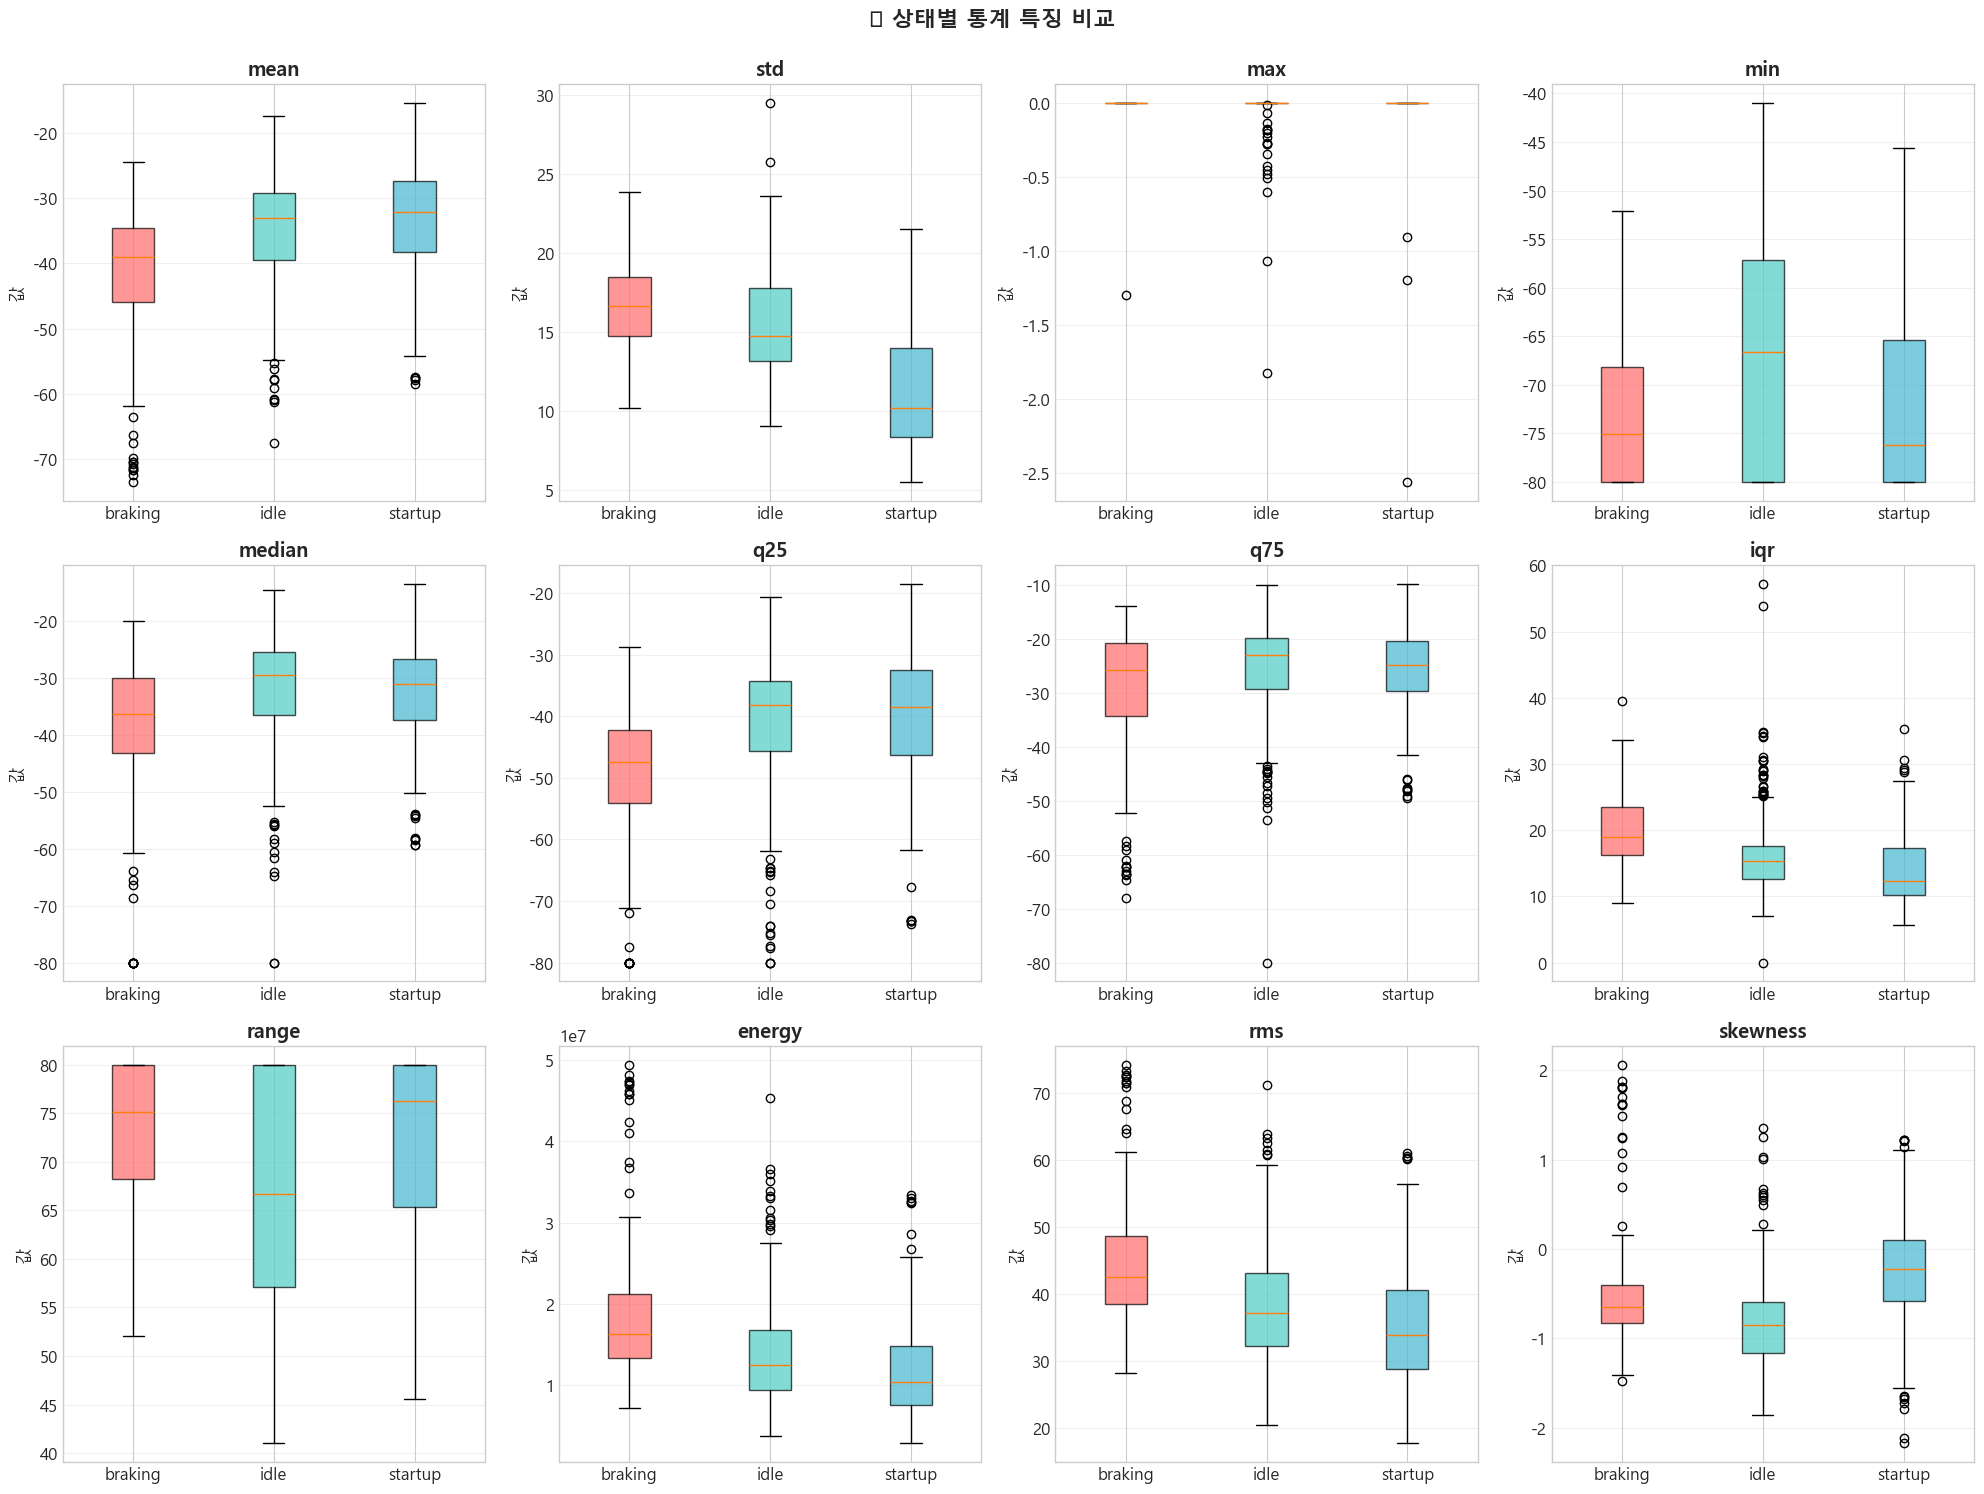

In [120]:
# ============================================================
# 상태별 통계 특징 비교 시각화
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

# 주요 통계 특징들
key_features = ['mean', 'std', 'max', 'min', 'median', 'q25', 'q75', 'iqr', 
                'range', 'energy', 'rms', 'skewness']

for idx, feature_name in enumerate(key_features):
    ax = axes[idx]
    
    # 상태별 박스플롯
    data_to_plot = [df_stats[y_states == i][feature_name].values for i in range(3)]
    
    bp = ax.boxplot(data_to_plot, labels=state_names, patch_artist=True)
    
    # 박스 색상 설정
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{feature_name}', fontweight='bold')
    ax.set_ylabel('값')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('📊 상태별 통계 특징 비교', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



In [121]:
# ============================================================
# 시간 축 패턴 분석 (각 주파수 밴드의 시간적 변화)
# ============================================================

def extract_time_pattern_features(spectrogram_2d):
    """
    각 주파수 밴드의 시간적 변화 패턴을 분석
    
    Returns:
        dict: 시간 축 패턴 특징들
    """
    features = {}
    
    # 각 주파수 밴드별 시간 평균 및 표준편차
    freq_band_means = np.mean(spectrogram_2d, axis=1)  # (frequency,)
    freq_band_stds = np.std(spectrogram_2d, axis=1)    # (frequency,)
    
    # 주파수 밴드별 통계
    features['freq_band_mean_mean'] = np.mean(freq_band_means)
    features['freq_band_mean_std'] = np.std(freq_band_means)
    features['freq_band_std_mean'] = np.mean(freq_band_stds)
    features['freq_band_std_std'] = np.std(freq_band_stds)
    
    # 시간 축 변화율 (gradient)
    time_gradient = np.gradient(spectrogram_2d, axis=1)  # 시간 축으로 미분
    features['time_gradient_mean'] = np.mean(time_gradient)
    features['time_gradient_std'] = np.std(time_gradient)
    features['time_gradient_max'] = np.max(time_gradient)
    features['time_gradient_min'] = np.min(time_gradient)
    
    # 시간 축 변화율의 변화율 (가속도)
    time_gradient2 = np.gradient(time_gradient, axis=1)
    features['time_gradient2_mean'] = np.mean(time_gradient2)
    features['time_gradient2_std'] = np.std(time_gradient2)
    
    # 저주파/중주파/고주파 영역대별 시간 패턴
    n_freq = spectrogram_2d.shape[0]
    low_band = spectrogram_2d[:n_freq//3, :]
    mid_band = spectrogram_2d[n_freq//3:2*n_freq//3, :]
    high_band = spectrogram_2d[2*n_freq//3:, :]
    
    for band_name, band_data in [('low', low_band), ('mid', mid_band), ('high', high_band)]:
        band_time_mean = np.mean(band_data, axis=0)  # 각 시간 프레임의 평균
        features[f'{band_name}_time_mean'] = np.mean(band_time_mean)
        features[f'{band_name}_time_std'] = np.std(band_time_mean)
        features[f'{band_name}_time_max'] = np.max(band_time_mean)
        features[f'{band_name}_time_min'] = np.min(band_time_mean)
    
    return features

# 모든 샘플에 대해 시간 패턴 특징 추출
print("🔄 시간 패턴 특징 추출 중...")
time_pattern_features = []

for spec_2d in tqdm(X_2d, desc="시간 패턴 추출"):
    features = extract_time_pattern_features(spec_2d)
    time_pattern_features.append(features)

# DataFrame으로 변환
df_time_pattern = pd.DataFrame(time_pattern_features)

print(f"\n✅ 시간 패턴 특징 추출 완료! (Shape: {df_time_pattern.shape})")



🔄 시간 패턴 특징 추출 중...


시간 패턴 추출: 100%|██████████| 949/949 [00:00<00:00, 1020.98it/s]


✅ 시간 패턴 특징 추출 완료! (Shape: (949, 22))


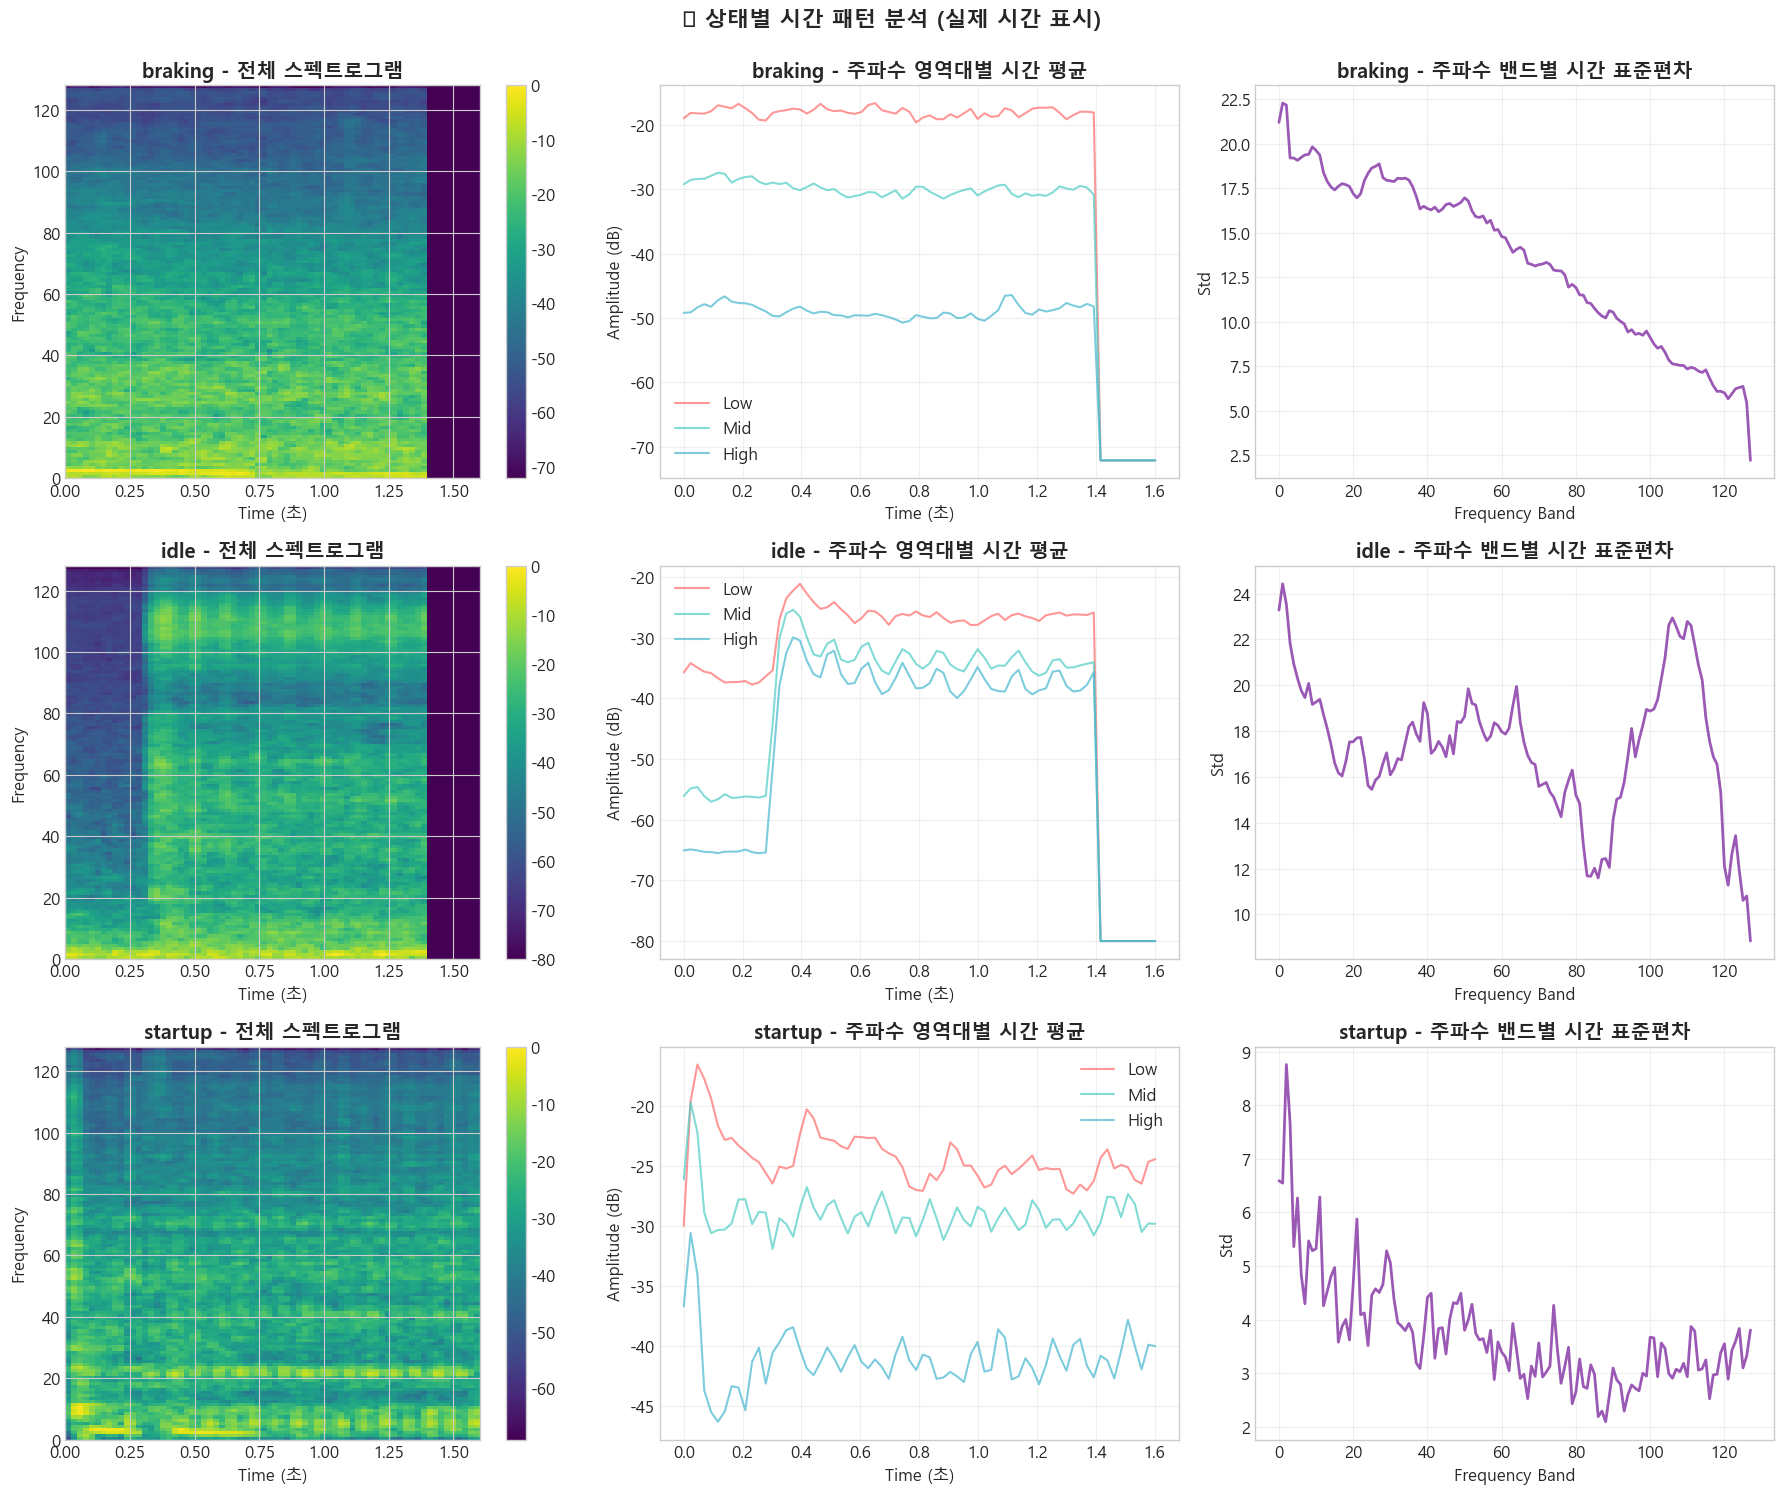

In [122]:
# ============================================================
# 시간 패턴 시각화 (샘플 예시)
# ============================================================

# 시간 프레임을 실제 시간(초)으로 변환하는 함수
hop_length = config.hop_length
sample_rate = config.sample_rate

def frames_to_time(frames, hop_length=hop_length, sr=sample_rate):
    """시간 프레임을 실제 시간(초)으로 변환"""
    return frames * hop_length / sr

# 각 상태별로 대표 샘플 선택
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for state_idx, state_name in enumerate(state_names):
    # 해당 상태의 첫 번째 샘플 선택
    state_mask = y_states == state_idx
    sample_idx = np.where(state_mask)[0][0]
    sample_spec = X_2d[sample_idx]
    
    # 시간 축 생성 (초 단위)
    n_time_frames = sample_spec.shape[1]
    time_axis = frames_to_time(np.arange(n_time_frames))
    
    # 1. 전체 스펙트로그램
    im1 = axes[state_idx, 0].imshow(sample_spec, aspect='auto', origin='lower', cmap='viridis',
                                    extent=[time_axis[0], time_axis[-1], 0, sample_spec.shape[0]])
    axes[state_idx, 0].set_title(f'{state_name} - 전체 스펙트로그램', fontweight='bold')
    axes[state_idx, 0].set_xlabel('Time (초)')
    axes[state_idx, 0].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[state_idx, 0])
    
    # 2. 저주파/중주파/고주파 영역대별 시간 평균
    n_freq = sample_spec.shape[0]
    low_mean = np.mean(sample_spec[:n_freq//3, :], axis=0)
    mid_mean = np.mean(sample_spec[n_freq//3:2*n_freq//3, :], axis=0)
    high_mean = np.mean(sample_spec[2*n_freq//3:, :], axis=0)
    
    axes[state_idx, 1].plot(time_axis, low_mean, label='Low', color='#FF6B6B', alpha=0.7)
    axes[state_idx, 1].plot(time_axis, mid_mean, label='Mid', color='#4ECDC4', alpha=0.7)
    axes[state_idx, 1].plot(time_axis, high_mean, label='High', color='#45B7D1', alpha=0.7)
    axes[state_idx, 1].set_title(f'{state_name} - 주파수 영역대별 시간 평균', fontweight='bold')
    axes[state_idx, 1].set_xlabel('Time (초)')
    axes[state_idx, 1].set_ylabel('Amplitude (dB)')
    axes[state_idx, 1].legend()
    axes[state_idx, 1].grid(True, alpha=0.3)
    
    # 3. 주파수 밴드별 시간 표준편차
    freq_band_stds = np.std(sample_spec, axis=1)
    axes[state_idx, 2].plot(freq_band_stds, color='#9B59B6', linewidth=2)
    axes[state_idx, 2].set_title(f'{state_name} - 주파수 밴드별 시간 표준편차', fontweight='bold')
    axes[state_idx, 2].set_xlabel('Frequency Band')
    axes[state_idx, 2].set_ylabel('Std')
    axes[state_idx, 2].grid(True, alpha=0.3)

plt.suptitle('🎵 상태별 시간 패턴 분석 (실제 시간 표시)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



## 4. 주파수 축 패턴 분석 (각 시간 프레임의 주파수 분포)



In [123]:
# ============================================================
# 주파수 축 패턴 분석 (각 시간 프레임의 주파수 분포)
# ============================================================

def extract_frequency_pattern_features(spectrogram_2d):
    """
    각 시간 프레임의 주파수 분포 패턴을 분석
    
    Returns:
        dict: 주파수 축 패턴 특징들
    """
    features = {}
    
    # 각 시간 프레임별 주파수 평균 및 표준편차
    time_frame_means = np.mean(spectrogram_2d, axis=0)  # (time,)
    time_frame_stds = np.std(spectrogram_2d, axis=0)    # (time,)
    
    # 시간 프레임별 통계
    features['time_frame_mean_mean'] = np.mean(time_frame_means)
    features['time_frame_mean_std'] = np.std(time_frame_means)
    features['time_frame_std_mean'] = np.mean(time_frame_stds)
    features['time_frame_std_std'] = np.std(time_frame_stds)
    
    # 주파수 축 변화율 (gradient)
    freq_gradient = np.gradient(spectrogram_2d, axis=0)  # 주파수 축으로 미분
    features['freq_gradient_mean'] = np.mean(freq_gradient)
    features['freq_gradient_std'] = np.std(freq_gradient)
    features['freq_gradient_max'] = np.max(freq_gradient)
    features['freq_gradient_min'] = np.min(freq_gradient)
    
    # 주파수 축 변화율의 변화율 (가속도)
    freq_gradient2 = np.gradient(freq_gradient, axis=0)
    features['freq_gradient2_mean'] = np.mean(freq_gradient2)
    features['freq_gradient2_std'] = np.std(freq_gradient2)
    
    # 주파수 중심 (Spectral Centroid 유사)
    freq_indices = np.arange(spectrogram_2d.shape[0])
    weighted_freq = np.sum(freq_indices[:, np.newaxis] * spectrogram_2d, axis=0) / (np.sum(spectrogram_2d, axis=0) + 1e-10)
    features['spectral_centroid_mean'] = np.mean(weighted_freq)
    features['spectral_centroid_std'] = np.std(weighted_freq)
    
    # 주파수 대역별 에너지 비율
    n_freq = spectrogram_2d.shape[0]
    low_energy = np.sum(spectrogram_2d[:n_freq//3, :] ** 2)
    mid_energy = np.sum(spectrogram_2d[n_freq//3:2*n_freq//3, :] ** 2)
    high_energy = np.sum(spectrogram_2d[2*n_freq//3:, :] ** 2)
    total_energy = low_energy + mid_energy + high_energy + 1e-10
    
    features['low_energy_ratio'] = low_energy / total_energy
    features['mid_energy_ratio'] = mid_energy / total_energy
    features['high_energy_ratio'] = high_energy / total_energy
    
    return features

# 모든 샘플에 대해 주파수 패턴 특징 추출
print("🔄 주파수 패턴 특징 추출 중...")
freq_pattern_features = []

for spec_2d in tqdm(X_2d, desc="주파수 패턴 추출"):
    features = extract_frequency_pattern_features(spec_2d)
    freq_pattern_features.append(features)

# DataFrame으로 변환
df_freq_pattern = pd.DataFrame(freq_pattern_features)

print(f"\n✅ 주파수 패턴 특징 추출 완료! (Shape: {df_freq_pattern.shape})")



🔄 주파수 패턴 특징 추출 중...


주파수 패턴 추출: 100%|██████████| 949/949 [00:00<00:00, 1283.36it/s]


✅ 주파수 패턴 특징 추출 완료! (Shape: (949, 15))


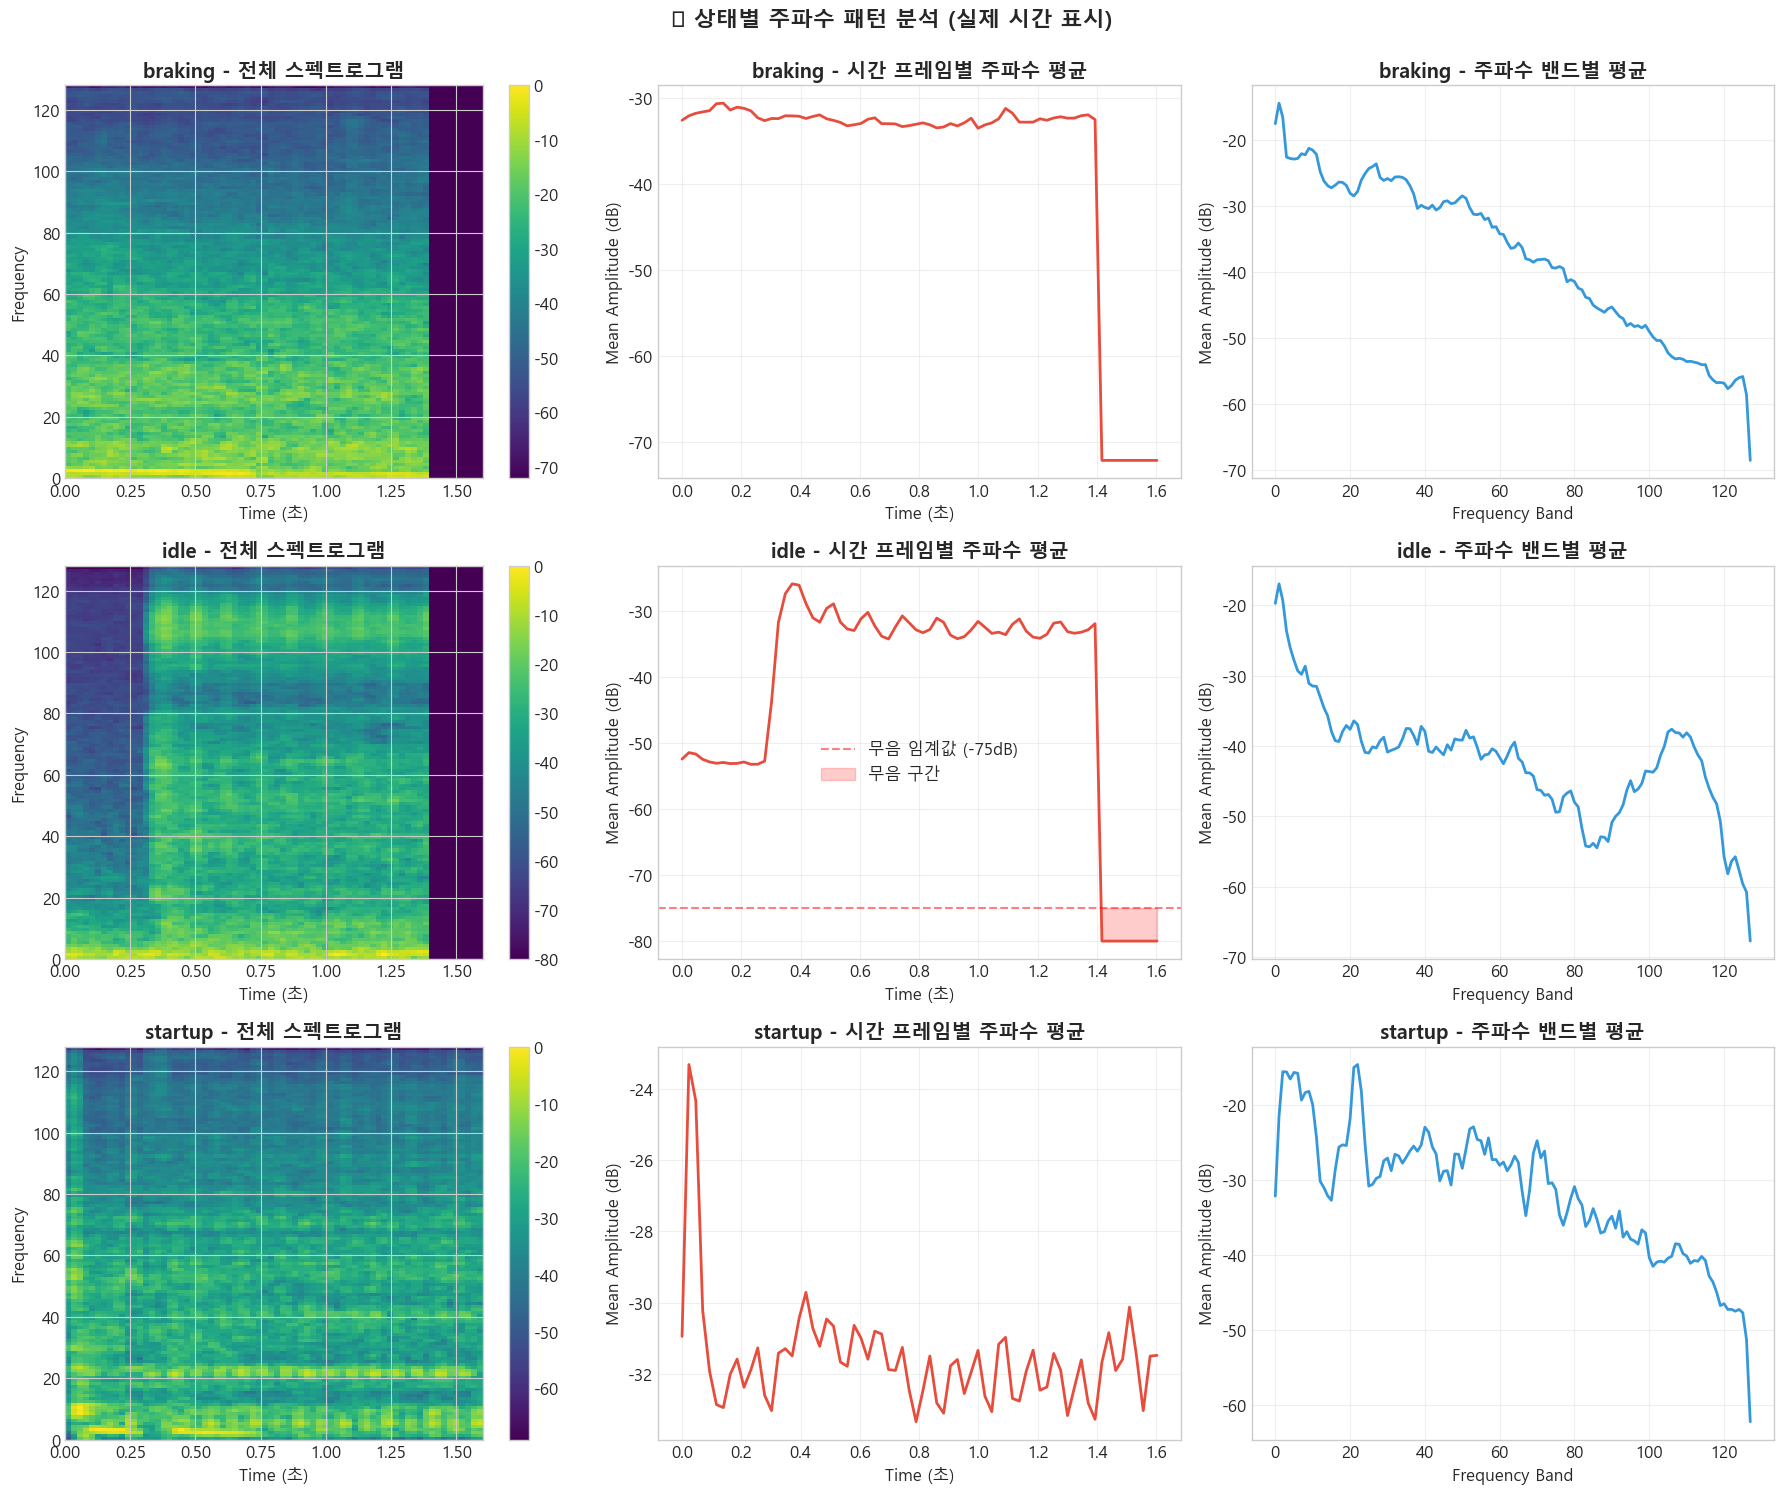

In [124]:
# ============================================================
# 주파수 패턴 시각화 (샘플 예시)
# ============================================================

# 시간 프레임을 실제 시간(초)으로 변환하는 함수
hop_length = config.hop_length
sample_rate = config.sample_rate

def frames_to_time(frames, hop_length=hop_length, sr=sample_rate):
    """시간 프레임을 실제 시간(초)으로 변환"""
    return frames * hop_length / sr

# 각 상태별로 대표 샘플 선택
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for state_idx, state_name in enumerate(state_names):
    # 해당 상태의 첫 번째 샘플 선택
    state_mask = y_states == state_idx
    sample_idx = np.where(state_mask)[0][0]
    sample_spec = X_2d[sample_idx]
    
    # 시간 축 생성 (초 단위)
    n_time_frames = sample_spec.shape[1]
    time_axis = frames_to_time(np.arange(n_time_frames))
    
    # 1. 전체 스펙트로그램
    im1 = axes[state_idx, 0].imshow(sample_spec, aspect='auto', origin='lower', cmap='viridis',
                                    extent=[time_axis[0], time_axis[-1], 0, sample_spec.shape[0]])
    axes[state_idx, 0].set_title(f'{state_name} - 전체 스펙트로그램', fontweight='bold')
    axes[state_idx, 0].set_xlabel('Time (초)')
    axes[state_idx, 0].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[state_idx, 0])
    
    # 2. 각 시간 프레임별 주파수 평균
    time_frame_means = np.mean(sample_spec, axis=0)
    axes[state_idx, 1].plot(time_axis, time_frame_means, color='#E74C3C', linewidth=2)
    axes[state_idx, 1].set_title(f'{state_name} - 시간 프레임별 주파수 평균', fontweight='bold')
    axes[state_idx, 1].set_xlabel('Time (초)')
    axes[state_idx, 1].set_ylabel('Mean Amplitude (dB)')
    axes[state_idx, 1].grid(True, alpha=0.3)
    
    # 무음 구간 표시 (평균이 -75dB 이하인 구간)
    silence_threshold = -75
    silence_mask = time_frame_means < silence_threshold
    if np.any(silence_mask):
        axes[state_idx, 1].axhline(y=silence_threshold, color='red', linestyle='--', 
                                   alpha=0.5, label=f'무음 임계값 ({silence_threshold}dB)')
        axes[state_idx, 1].fill_between(time_axis, silence_threshold, time_frame_means.min(), 
                                        where=silence_mask, alpha=0.2, color='red', label='무음 구간')
        axes[state_idx, 1].legend()
    
    # 3. 주파수 밴드별 평균 (전체 시간에 대한 평균)
    freq_band_means = np.mean(sample_spec, axis=1)
    axes[state_idx, 2].plot(freq_band_means, color='#3498DB', linewidth=2)
    axes[state_idx, 2].set_title(f'{state_name} - 주파수 밴드별 평균', fontweight='bold')
    axes[state_idx, 2].set_xlabel('Frequency Band')
    axes[state_idx, 2].set_ylabel('Mean Amplitude (dB)')
    axes[state_idx, 2].grid(True, alpha=0.3)

plt.suptitle('🎵 상태별 주파수 패턴 분석 (실제 시간 표시)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



## 5. 에너지 분포 분석



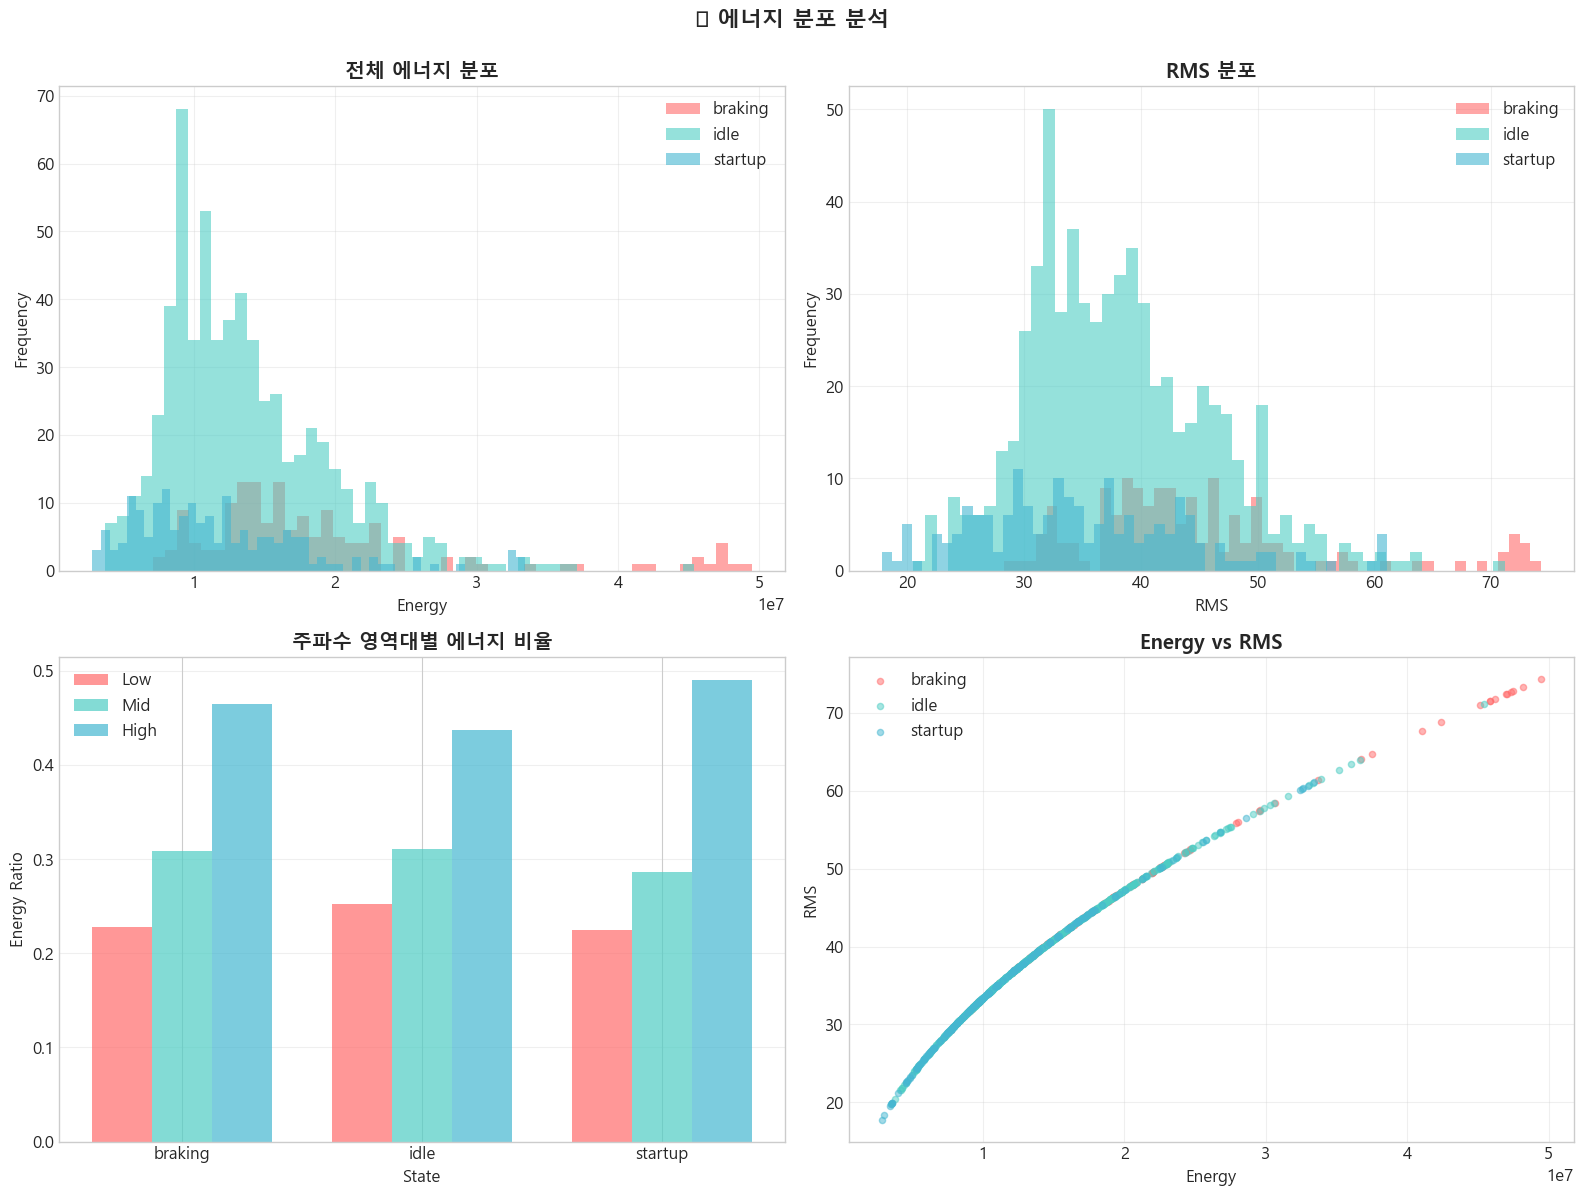

In [125]:
# ============================================================
# 에너지 분포 분석
# ============================================================

# 상태별 에너지 분포 비교
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 전체 에너지 분포
energy_values = df_stats['energy'].values
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    axes[0, 0].hist(energy_values[mask], bins=50, alpha=0.6, 
                    label=state_name, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[0, 0].set_xlabel('Energy')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('전체 에너지 분포', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. RMS 분포
rms_values = df_stats['rms'].values
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    axes[0, 1].hist(rms_values[mask], bins=50, alpha=0.6, 
                    label=state_name, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[0, 1].set_xlabel('RMS')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('RMS 분포', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 주파수 영역대별 에너지 비율 비교
low_energy_ratios = df_freq_pattern['low_energy_ratio'].values
mid_energy_ratios = df_freq_pattern['mid_energy_ratio'].values
high_energy_ratios = df_freq_pattern['high_energy_ratio'].values

x_pos = np.arange(len(state_names))
width = 0.25

low_means = [np.mean(low_energy_ratios[y_states == i]) for i in range(3)]
mid_means = [np.mean(mid_energy_ratios[y_states == i]) for i in range(3)]
high_means = [np.mean(high_energy_ratios[y_states == i]) for i in range(3)]

axes[1, 0].bar(x_pos - width, low_means, width, label='Low', color='#FF6B6B', alpha=0.7)
axes[1, 0].bar(x_pos, mid_means, width, label='Mid', color='#4ECDC4', alpha=0.7)
axes[1, 0].bar(x_pos + width, high_means, width, label='High', color='#45B7D1', alpha=0.7)
axes[1, 0].set_xlabel('State')
axes[1, 0].set_ylabel('Energy Ratio')
axes[1, 0].set_title('주파수 영역대별 에너지 비율', fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(state_names)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 에너지 vs RMS 산점도
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    axes[1, 1].scatter(energy_values[mask], rms_values[mask], 
                      alpha=0.5, label=state_name, 
                      color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx], s=20)
axes[1, 1].set_xlabel('Energy')
axes[1, 1].set_ylabel('RMS')
axes[1, 1].set_title('Energy vs RMS', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('⚡ 에너지 분포 분석', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



## 6. 주파수 밴드별 통계 비교



🔄 주파수 밴드별 통계 계산 중...


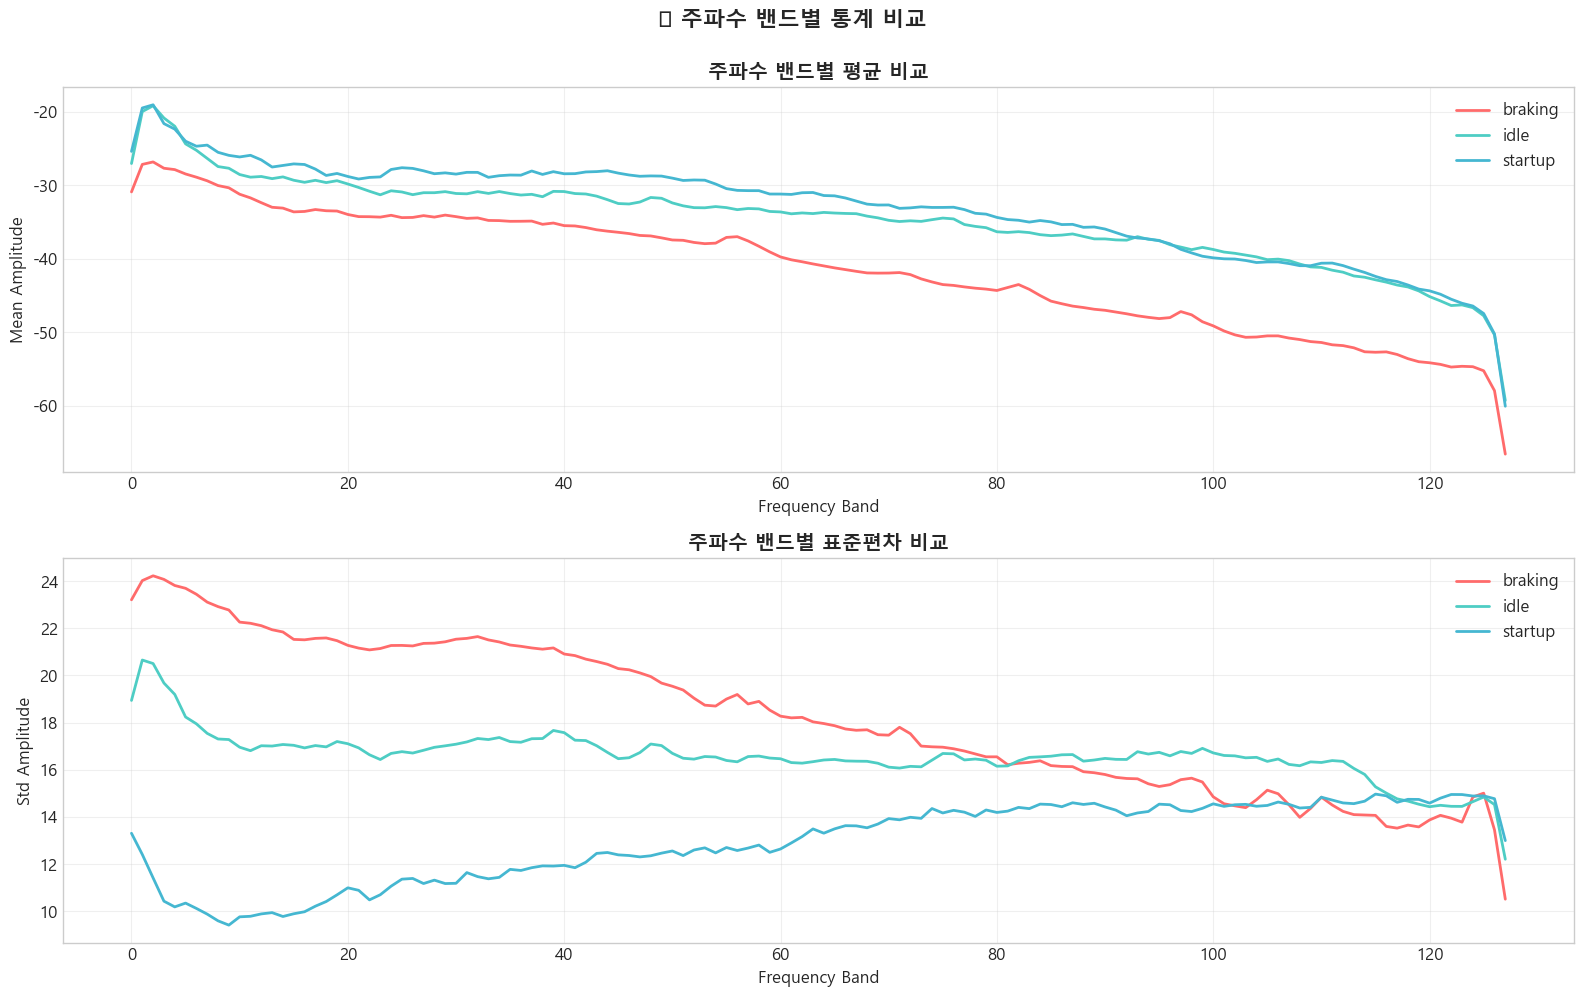

✅ 주파수 밴드별 통계 비교 완료!


In [126]:
# ============================================================
# 주파수 밴드별 통계 비교
# ============================================================

# 모든 샘플의 주파수 밴드별 평균 계산
print("🔄 주파수 밴드별 통계 계산 중...")

# 각 상태별로 주파수 밴드별 평균 계산
freq_band_stats = {state_name: [] for state_name in state_names}

for state_idx, state_name in enumerate(state_names):
    state_mask = y_states == state_idx
    state_specs = X_2d[state_mask]
    
    # 각 주파수 밴드별 평균 계산
    freq_band_means = np.mean(state_specs, axis=(0, 2))  # (frequency,)
    freq_band_stds = np.std(state_specs, axis=(0, 2))    # (frequency,)
    
    freq_band_stats[state_name] = {
        'mean': freq_band_means,
        'std': freq_band_stds
    }

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. 주파수 밴드별 평균
for state_idx, state_name in enumerate(state_names):
    axes[0].plot(freq_band_stats[state_name]['mean'], 
                label=state_name, linewidth=2,
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[0].set_xlabel('Frequency Band')
axes[0].set_ylabel('Mean Amplitude')
axes[0].set_title('주파수 밴드별 평균 비교', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 주파수 밴드별 표준편차
for state_idx, state_name in enumerate(state_names):
    axes[1].plot(freq_band_stats[state_name]['std'], 
                label=state_name, linewidth=2,
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[1].set_xlabel('Frequency Band')
axes[1].set_ylabel('Std Amplitude')
axes[1].set_title('주파수 밴드별 표준편차 비교', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('📊 주파수 밴드별 통계 비교', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ 주파수 밴드별 통계 비교 완료!")



## 7. 시간 구간별 통계 분석



🔄 시간 구간 특징 추출 중...


시간 구간 추출: 100%|██████████| 949/949 [00:00<00:00, 3119.12it/s]



✅ 시간 구간 특징 추출 완료! (Shape: (949, 17))


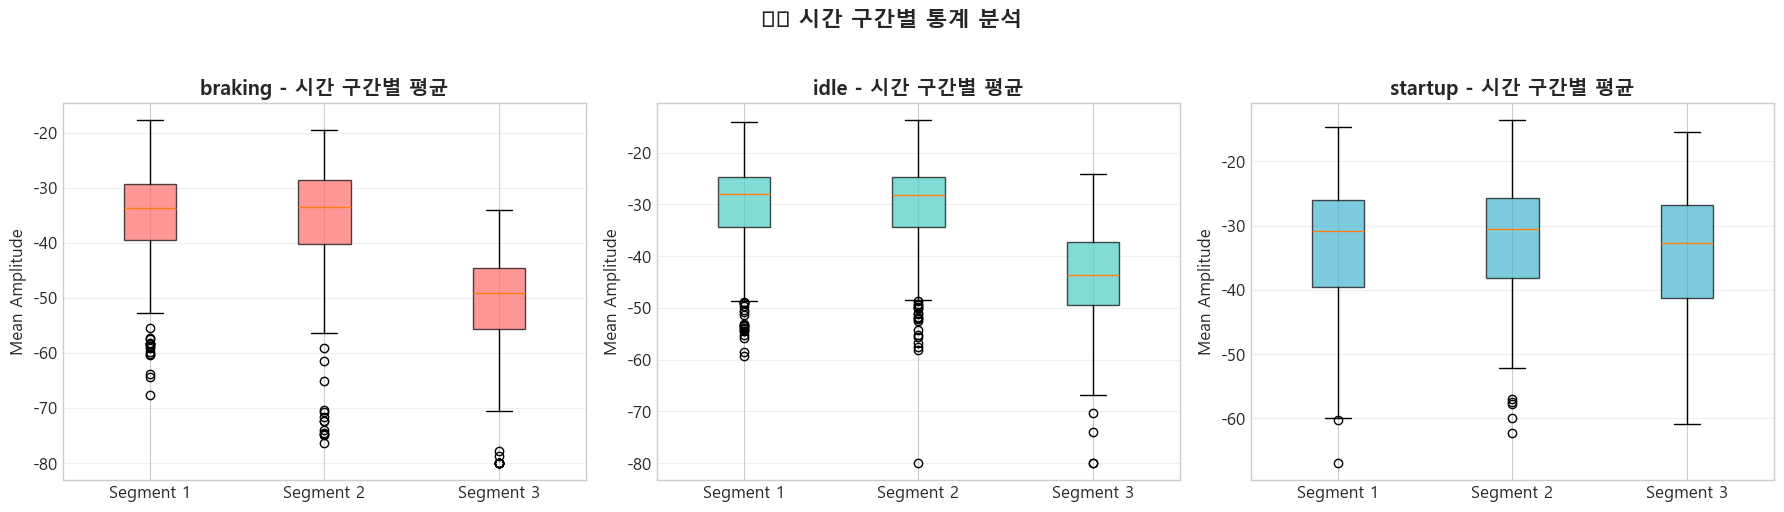

In [127]:
# ============================================================
# 시간 구간별 통계 분석
# ============================================================

def extract_time_segment_features(spectrogram_2d, n_segments=3):
    """
    시간을 여러 구간으로 나누어 각 구간의 통계를 분석
    
    Args:
        spectrogram_2d: (frequency, time) 스펙트로그램
        n_segments: 시간 구간 개수
    
    Returns:
        dict: 시간 구간별 특징들
    """
    features = {}
    n_time = spectrogram_2d.shape[1]
    segment_size = n_time // n_segments
    
    for seg_idx in range(n_segments):
        start = seg_idx * segment_size
        end = (seg_idx + 1) * segment_size if seg_idx < n_segments - 1 else n_time
        segment = spectrogram_2d[:, start:end]
        
        features[f'segment_{seg_idx}_mean'] = np.mean(segment)
        features[f'segment_{seg_idx}_std'] = np.std(segment)
        features[f'segment_{seg_idx}_max'] = np.max(segment)
        features[f'segment_{seg_idx}_min'] = np.min(segment)
        features[f'segment_{seg_idx}_energy'] = np.sum(segment ** 2)
    
    # 구간 간 변화율
    for seg_idx in range(n_segments - 1):
        features[f'segment_{seg_idx}_to_{seg_idx+1}_change'] = (
            features[f'segment_{seg_idx+1}_mean'] - features[f'segment_{seg_idx}_mean']
        )
    
    return features

# 모든 샘플에 대해 시간 구간 특징 추출
print("🔄 시간 구간 특징 추출 중...")
time_segment_features = []

for spec_2d in tqdm(X_2d, desc="시간 구간 추출"):
    features = extract_time_segment_features(spec_2d, n_segments=3)
    time_segment_features.append(features)

# DataFrame으로 변환
df_time_segment = pd.DataFrame(time_segment_features)

print(f"\n✅ 시간 구간 특징 추출 완료! (Shape: {df_time_segment.shape})")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    
    # 각 구간별 평균 비교
    segment_means = [
        df_time_segment[mask][f'segment_{i}_mean'].values for i in range(3)
    ]
    
    bp = axes[state_idx].boxplot(segment_means, labels=[f'Segment {i+1}' for i in range(3)],
                                patch_artist=True)
    
    # 박스 색상 설정
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    for patch in bp['boxes']:
        patch.set_facecolor(colors[state_idx])
        patch.set_alpha(0.7)
    
    axes[state_idx].set_title(f'{state_name} - 시간 구간별 평균', fontweight='bold')
    axes[state_idx].set_ylabel('Mean Amplitude')
    axes[state_idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('⏱️ 시간 구간별 통계 분석', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



## 8. 스펙트로그램 변화율 분석 (Gradient)



🔄 변화율 특징 추출 중...


변화율 추출: 100%|██████████| 949/949 [00:01<00:00, 882.20it/s] 



✅ 변화율 특징 추출 완료! (Shape: (949, 14))


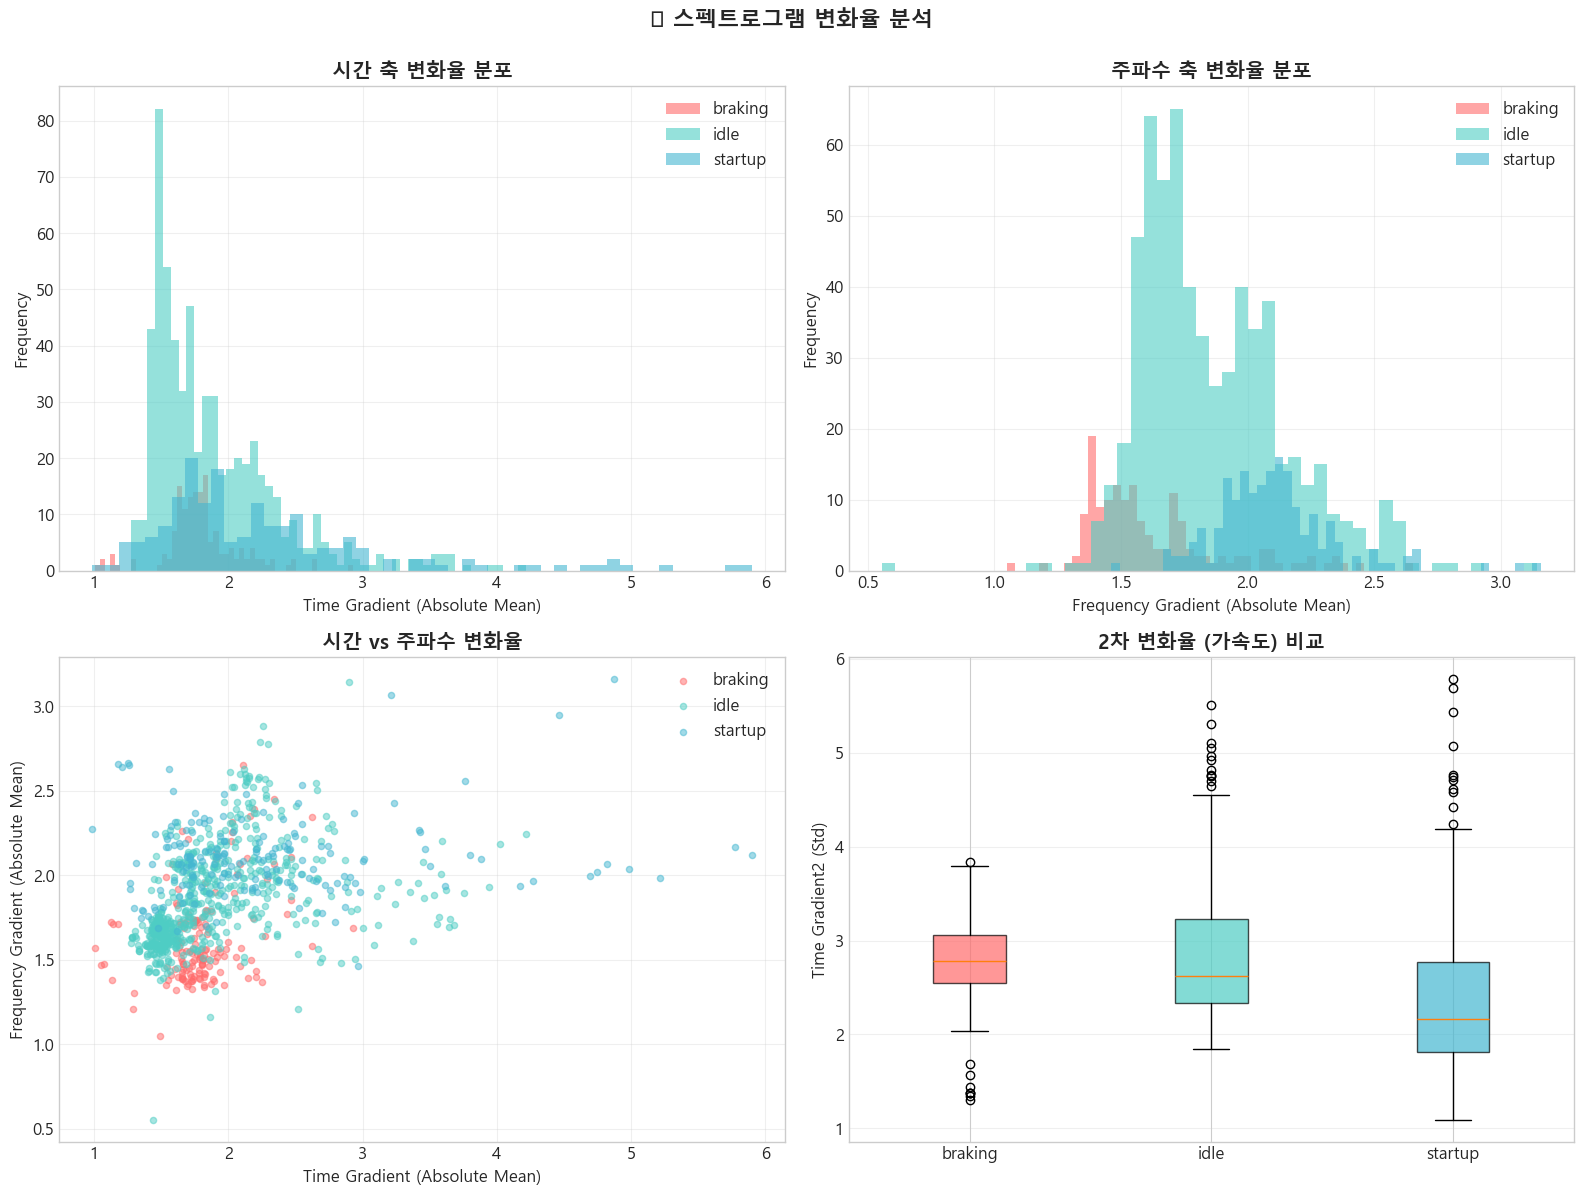

In [128]:
# ============================================================
# 스펙트로그램 변화율 분석 (Gradient)
# ============================================================

def extract_gradient_features(spectrogram_2d):
    """
    스펙트로그램의 시간/주파수 축 변화율 분석
    
    Returns:
        dict: 변화율 특징들
    """
    features = {}
    
    # 시간 축 변화율 (시간에 따른 변화)
    time_grad = np.gradient(spectrogram_2d, axis=1)
    features['time_grad_mean'] = np.mean(time_grad)
    features['time_grad_std'] = np.std(time_grad)
    features['time_grad_max'] = np.max(time_grad)
    features['time_grad_min'] = np.min(time_grad)
    features['time_grad_abs_mean'] = np.mean(np.abs(time_grad))
    
    # 주파수 축 변화율 (주파수에 따른 변화)
    freq_grad = np.gradient(spectrogram_2d, axis=0)
    features['freq_grad_mean'] = np.mean(freq_grad)
    features['freq_grad_std'] = np.std(freq_grad)
    features['freq_grad_max'] = np.max(freq_grad)
    features['freq_grad_min'] = np.min(freq_grad)
    features['freq_grad_abs_mean'] = np.mean(np.abs(freq_grad))
    
    # 2차 변화율 (가속도)
    time_grad2 = np.gradient(time_grad, axis=1)
    freq_grad2 = np.gradient(freq_grad, axis=0)
    
    features['time_grad2_mean'] = np.mean(time_grad2)
    features['time_grad2_std'] = np.std(time_grad2)
    features['freq_grad2_mean'] = np.mean(freq_grad2)
    features['freq_grad2_std'] = np.std(freq_grad2)
    
    return features

# 모든 샘플에 대해 변화율 특징 추출
print("🔄 변화율 특징 추출 중...")
gradient_features = []

for spec_2d in tqdm(X_2d, desc="변화율 추출"):
    features = extract_gradient_features(spec_2d)
    gradient_features.append(features)

# DataFrame으로 변환
df_gradient = pd.DataFrame(gradient_features)

print(f"\n✅ 변화율 특징 추출 완료! (Shape: {df_gradient.shape})")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 시간 축 변화율 평균
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    axes[0, 0].hist(df_gradient[mask]['time_grad_abs_mean'], bins=50, alpha=0.6,
                   label=state_name, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[0, 0].set_xlabel('Time Gradient (Absolute Mean)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('시간 축 변화율 분포', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 주파수 축 변화율 평균
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    axes[0, 1].hist(df_gradient[mask]['freq_grad_abs_mean'], bins=50, alpha=0.6,
                   label=state_name, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[0, 1].set_xlabel('Frequency Gradient (Absolute Mean)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('주파수 축 변화율 분포', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 시간 vs 주파수 변화율 산점도
for state_idx, state_name in enumerate(state_names):
    mask = y_states == state_idx
    axes[1, 0].scatter(df_gradient[mask]['time_grad_abs_mean'], 
                      df_gradient[mask]['freq_grad_abs_mean'],
                      alpha=0.5, label=state_name, s=20,
                      color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx])
axes[1, 0].set_xlabel('Time Gradient (Absolute Mean)')
axes[1, 0].set_ylabel('Frequency Gradient (Absolute Mean)')
axes[1, 0].set_title('시간 vs 주파수 변화율', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 2차 변화율 비교
grad2_data = [
    df_gradient[y_states == i]['time_grad2_std'].values for i in range(3)
]
bp = axes[1, 1].boxplot(grad2_data, labels=state_names, patch_artist=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_ylabel('Time Gradient2 (Std)')
axes[1, 1].set_title('2차 변화율 (가속도) 비교', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('📈 스펙트로그램 변화율 분석', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



In [129]:
# ============================================================
# 모든 특징 결합 및 PCA 시각화
# ============================================================

# 모든 특징 결합
print("🔄 모든 특징 결합 중...")
all_features = pd.concat([
    df_stats,
    df_time_pattern,
    df_freq_pattern,
    df_time_segment,
    df_gradient
], axis=1)

print(f"✅ 특징 결합 완료! (Shape: {all_features.shape})")
print(f"   총 특징 수: {all_features.shape[1]}개")

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(all_features)

print("\n✅ 데이터 정규화 완료!")

# PCA 수행
print("\n🔄 PCA 수행 중...")
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"✅ PCA 완료!")
print(f"   2D 설명 분산: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"   3D 설명 분산: {pca_3d.explained_variance_ratio_.sum():.4f}")



🔄 모든 특징 결합 중...
✅ 특징 결합 완료! (Shape: (949, 81))
   총 특징 수: 81개

✅ 데이터 정규화 완료!

🔄 PCA 수행 중...
✅ PCA 완료!
   2D 설명 분산: 0.5115
   3D 설명 분산: 0.6254


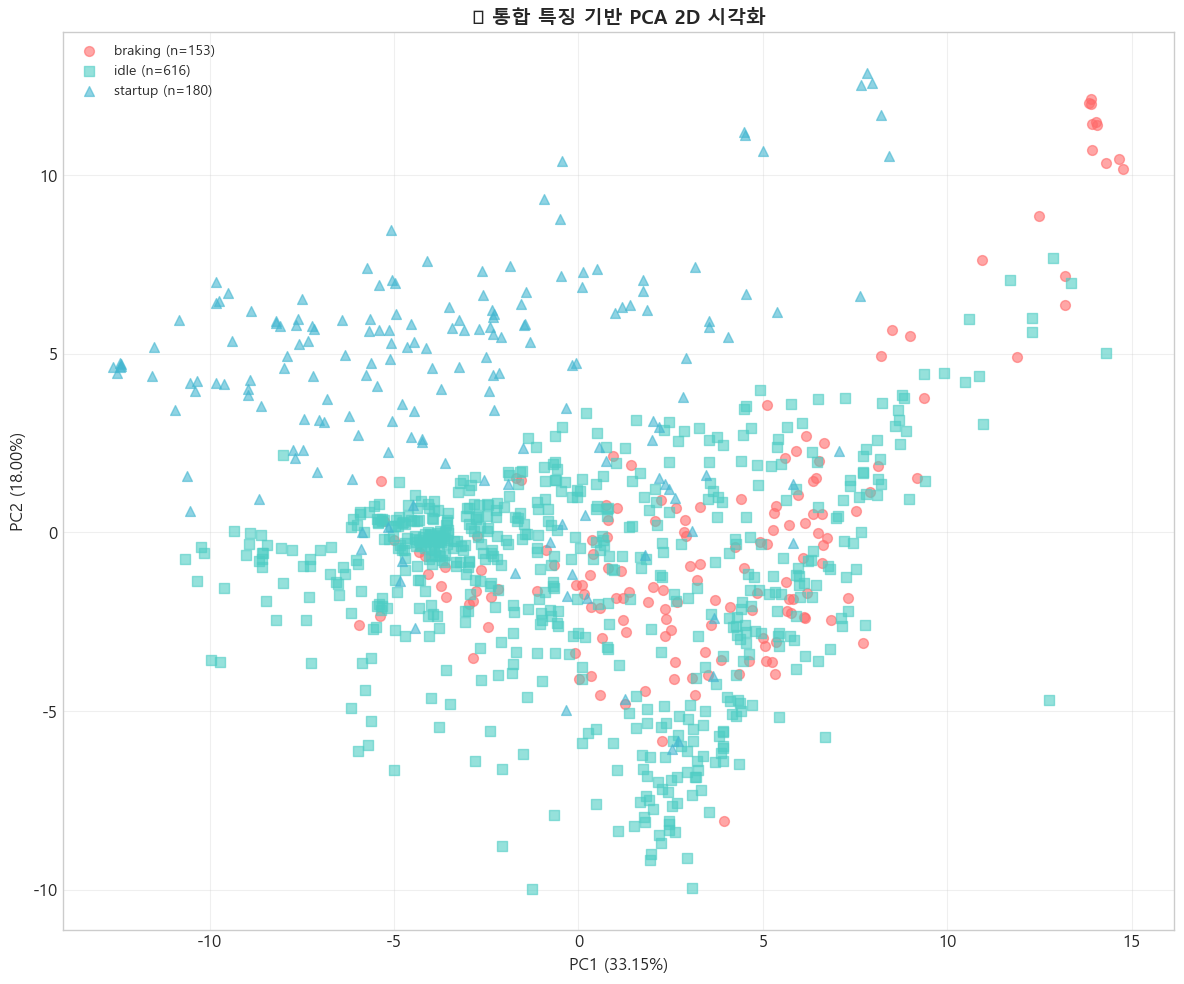

In [130]:
# ============================================================
# PCA 2D 시각화
# ============================================================

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
markers = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(12, 10))

for state_idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
    mask = y_states == state_idx
    ax.scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1], 
        c=color, 
        marker=marker,
        label=f'{name} (n={mask.sum()})',
        alpha=0.6,
        s=50
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax.set_title('🎯 통합 특징 기반 PCA 2D 시각화', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [131]:
# ============================================================
# K-means 클러스터링
# ============================================================

print("🔄 K-Means 클러스터링 수행 중...")

# K=3으로 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means 클러스터링 완료!")

# 클러스터링 성능 평가
silhouette = silhouette_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(y_states, cluster_labels)
nmi = normalized_mutual_info_score(y_states, cluster_labels)

print("\n" + "=" * 60)
print("📊 클러스터링 성능 평가")
print("=" * 60)
print(f"\n1️⃣ Silhouette Score: {silhouette:.4f}")
print("   (-1 ~ 1, 높을수록 군집이 잘 분리됨)")
print(f"\n2️⃣ Adjusted Rand Index (ARI): {ari:.4f}")
print("   (0 ~ 1, 높을수록 실제 레이블과 일치)")
print(f"\n3️⃣ Normalized Mutual Information (NMI): {nmi:.4f}")
print("   (0 ~ 1, 높을수록 실제 레이블과 일치)")



🔄 K-Means 클러스터링 수행 중...
✅ K-Means 클러스터링 완료!

📊 클러스터링 성능 평가

1️⃣ Silhouette Score: 0.2232
   (-1 ~ 1, 높을수록 군집이 잘 분리됨)

2️⃣ Adjusted Rand Index (ARI): 0.0615
   (0 ~ 1, 높을수록 실제 레이블과 일치)

3️⃣ Normalized Mutual Information (NMI): 0.0857
   (0 ~ 1, 높을수록 실제 레이블과 일치)


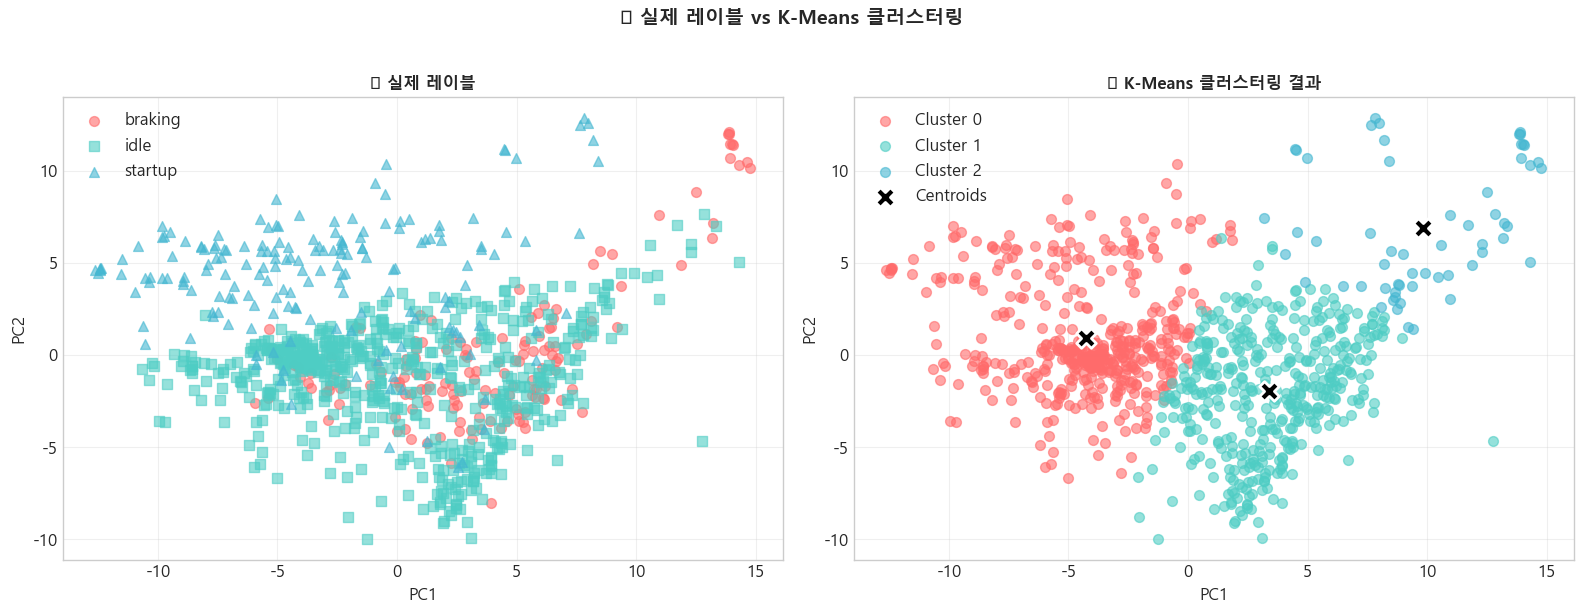


✅ 스펙트로그램 패턴 및 파동 분석 완료!


In [132]:
# ============================================================
# 클러스터링 결과 시각화
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 실제 레이블
for state_idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
    mask = y_states == state_idx
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=color, marker=marker,
        label=name, alpha=0.6, s=50
    )

axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('🔵 실제 레이블', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 클러스터링 결과
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for cluster_id in range(3):
    mask = cluster_labels == cluster_id
    axes[1].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=cluster_colors[cluster_id], marker='o',
        label=f'Cluster {cluster_id}', alpha=0.6, s=50
    )

# 클러스터 중심점 표시
centers_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c='black', marker='X', s=200, edgecolors='white', linewidths=2,
    label='Centroids'
)

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('🔵 K-Means 클러스터링 결과', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('📊 실제 레이블 vs K-Means 클러스터링', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ 스펙트로그램 패턴 및 파동 분석 완료!")



## 10. 에너지와 RMS 기반 간단한 분류 모델

통계 분석 결과, 에너지와 RMS만으로도 상태를 구분할 수 있습니다. 간단한 머신러닝 모델을 만들어보겠습니다.


In [133]:
# ============================================================
# 에너지와 RMS 기반 분류 모델
# ============================================================

# 에너지와 RMS 특징만 추출
print("🔄 에너지와 RMS 특징 추출 중...")
X_simple = df_stats[['energy', 'rms']].values
y_simple = y_states

print(f"✅ 특징 추출 완료!")
print(f"   특징 shape: {X_simple.shape}")
print(f"   레이블 shape: {y_simple.shape}")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42, stratify=y_simple
)

print(f"\n📊 데이터 분할:")
print(f"   학습: {X_train.shape[0]}개")
print(f"   테스트: {X_test.shape[0]}개")

# 여러 모델 학습
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = {}

print("\n🔄 모델 학습 중...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    print(f"   {name}: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 최고 성능 모델
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_accuracy = results[best_model_name]['accuracy']

print(f"\n🏆 최고 성능 모델: {best_model_name} ({best_accuracy*100:.2f}%)")

# 상세 평가
print("\n" + "=" * 60)
print(f"📊 {best_model_name} 상세 평가")
print("=" * 60)
print("\n📋 분류 리포트:")
print(classification_report(y_test, results[best_model_name]['predictions'], 
                          target_names=state_names))

# 혼동 행렬
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
print("\n📊 혼동 행렬:")
print(cm)


🔄 에너지와 RMS 특징 추출 중...
✅ 특징 추출 완료!
   특징 shape: (949, 2)
   레이블 shape: (949,)

📊 데이터 분할:
   학습: 759개
   테스트: 190개

🔄 모델 학습 중...
   Logistic Regression: 0.6632 (66.32%)
   Random Forest: 0.5211 (52.11%)
   SVM: 0.6684 (66.84%)

🏆 최고 성능 모델: SVM (66.84%)

📊 SVM 상세 평가

📋 분류 리포트:
              precision    recall  f1-score   support

     braking       1.00      0.13      0.23        31
        idle       0.66      1.00      0.80       123
     startup       0.00      0.00      0.00        36

    accuracy                           0.67       190
   macro avg       0.55      0.38      0.34       190
weighted avg       0.59      0.67      0.55       190


📊 혼동 행렬:
[[  4  27   0]
 [  0 123   0]
 [  0  36   0]]


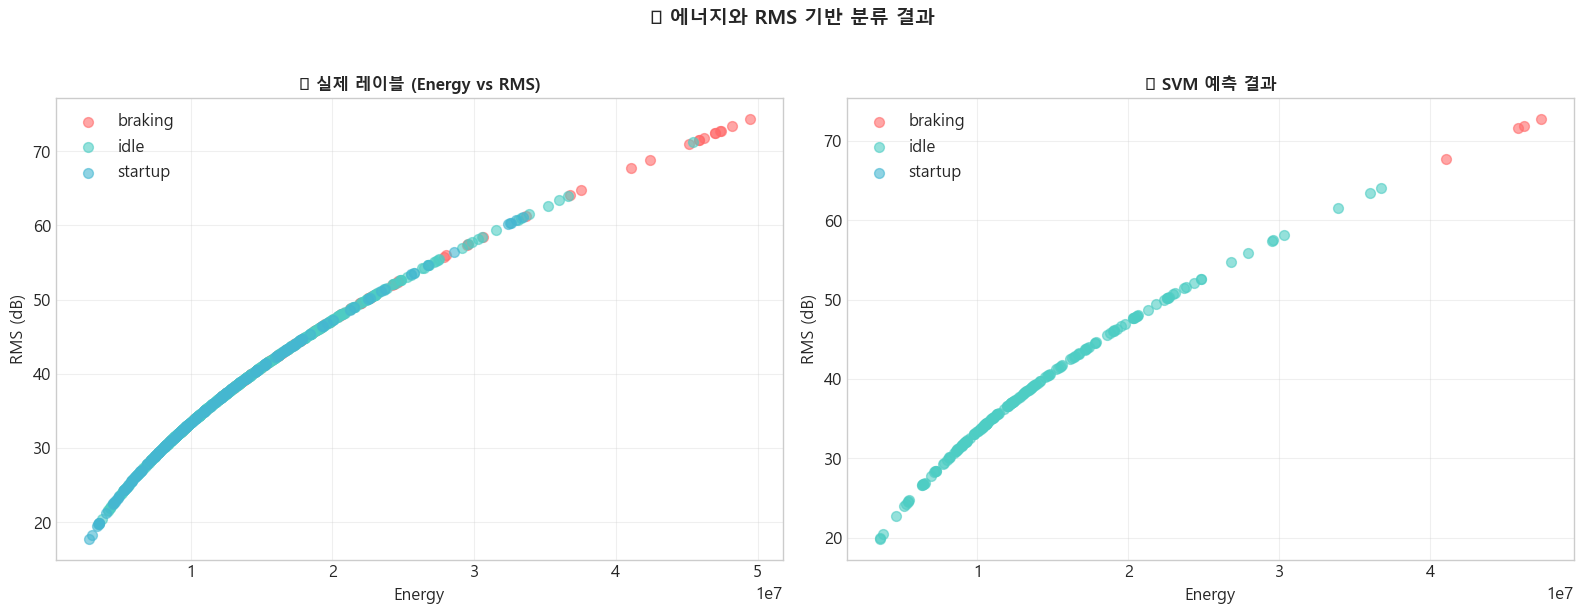


📊 모델별 성능 비교
Logistic Regression :  66.32%
Random Forest       :  52.11%
SVM                 :  66.84%


In [134]:
# ============================================================
# 에너지와 RMS 기반 분류 시각화
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 에너지 vs RMS 산점도 (실제 레이블)
for state_idx, state_name in enumerate(state_names):
    mask = y_simple == state_idx
    axes[0].scatter(
        X_simple[mask, 0], X_simple[mask, 1],
        label=state_name, alpha=0.6, s=50,
        color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx]
    )

axes[0].set_xlabel('Energy', fontsize=12)
axes[0].set_ylabel('RMS (dB)', fontsize=12)
axes[0].set_title('🔵 실제 레이블 (Energy vs RMS)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 예측 결과
y_pred_best = results[best_model_name]['predictions']
for state_idx, state_name in enumerate(state_names):
    mask = y_pred_best == state_idx
    axes[1].scatter(
        X_test[mask, 0], X_test[mask, 1],
        label=state_name, alpha=0.6, s=50,
        color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx]
    )

axes[1].set_xlabel('Energy', fontsize=12)
axes[1].set_ylabel('RMS (dB)', fontsize=12)
axes[1].set_title(f'🔵 {best_model_name} 예측 결과', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('⚡ 에너지와 RMS 기반 분류 결과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 모델별 성능 비교
print("\n" + "=" * 60)
print("📊 모델별 성능 비교")
print("=" * 60)
for name, result in results.items():
    print(f"{name:20s}: {result['accuracy']*100:6.2f}%")


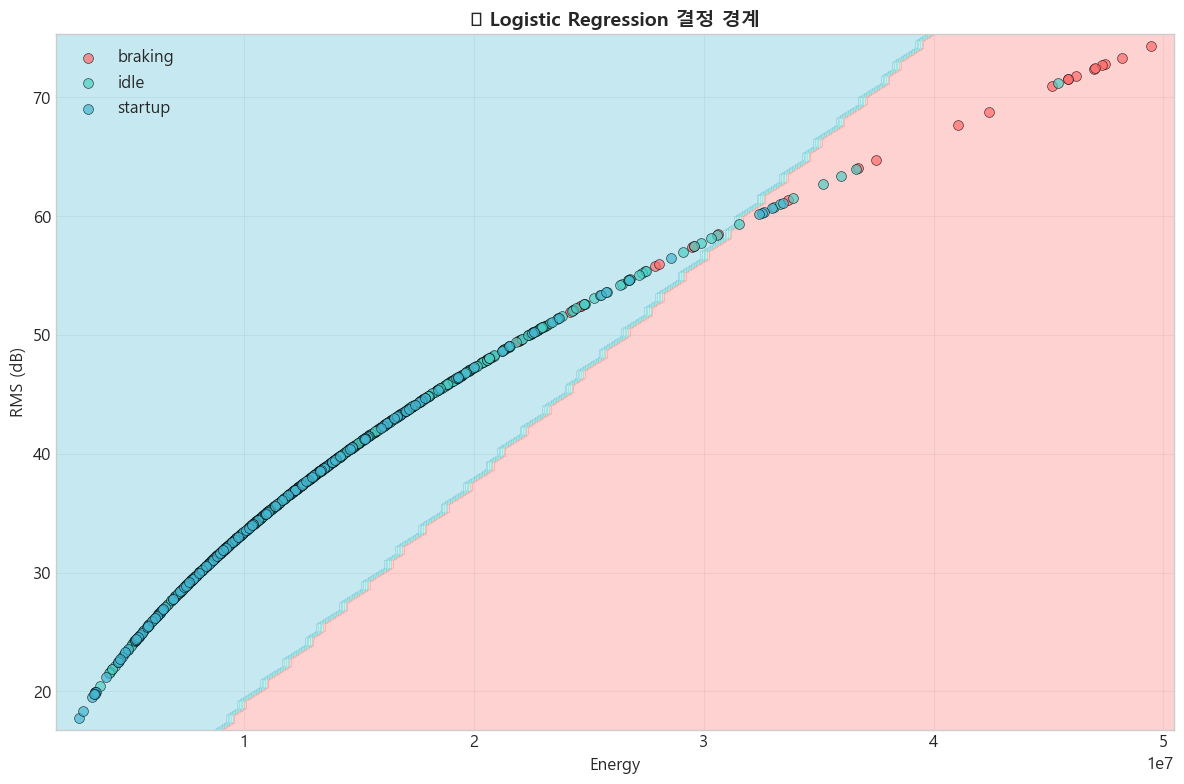


💡 인사이트:
   - 에너지와 RMS만으로도 상태를 어느 정도 구분할 수 있습니다.
   - 하지만 CNN/CRNN 모델보다는 정확도가 낮을 수 있습니다.
   - 이유: 스펙트로그램 이미지는 더 많은 패턴 정보를 포함합니다.


In [135]:
# ============================================================
# 결정 경계 시각화 (Logistic Regression)
# ============================================================

from matplotlib.colors import ListedColormap

# Logistic Regression 모델의 결정 경계 시각화
lr_model = results['Logistic Regression']['model']

# 그리드 생성
x_min, x_max = X_simple[:, 0].min() - 1e6, X_simple[:, 0].max() + 1e6
y_min, y_max = X_simple[:, 1].min() - 1, X_simple[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# 예측
Z = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 결정 경계
cmap = ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

# 실제 데이터 포인트
for state_idx, state_name in enumerate(state_names):
    mask = y_simple == state_idx
    ax.scatter(
        X_simple[mask, 0], X_simple[mask, 1],
        label=state_name, alpha=0.7, s=50,
        color=['#FF6B6B', '#4ECDC4', '#45B7D1'][state_idx],
        edgecolors='black', linewidths=0.5
    )

ax.set_xlabel('Energy', fontsize=12)
ax.set_ylabel('RMS (dB)', fontsize=12)
ax.set_title('🎯 Logistic Regression 결정 경계', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 인사이트:")
print("   - 에너지와 RMS만으로도 상태를 어느 정도 구분할 수 있습니다.")
print("   - 하지만 CNN/CRNN 모델보다는 정확도가 낮을 수 있습니다.")
print("   - 이유: 스펙트로그램 이미지는 더 많은 패턴 정보를 포함합니다.")


## 11. 스펙트로그램에서 중요한 영역 찾기 (Feature Importance Analysis)

모델이 학습할 때 어떤 주파수-시간 영역이 중요한지 분석하고, 그 영역에 집중하는 방법을 제안합니다.


In [136]:
# ============================================================
# 상태별로 중요한 주파수-시간 영역 찾기
# ============================================================

def find_important_regions_class_based(spectrograms, labels, num_classes, threshold_percentile=90):
    """
    클래스 간 차이를 고려한 중요한 주파수-시간 영역 찾기
    - 클래스 내 일관성: 각 클래스 내에서 표준편차가 낮은 영역 (공통적으로 나타나는 부분)
    - 클래스 간 차이: 클래스 간 평균 차이가 큰 영역 (구분이 잘 되는 부분)
    
    Args:
        spectrograms: 모든 스펙트로그램 (samples, freq, time)
        labels: 레이블
        num_classes: 클래스 개수
        threshold_percentile: 임계값 백분위수
    
    Returns:
        important_mask: 중요한 영역 마스크 (freq, time)
        importance_score: 중요도 점수 (freq, time)
        class_means: 각 클래스의 평균 스펙트로그램 dict
    """
    # 각 클래스의 평균 및 표준편차 계산
    class_means = {}
    class_stds = {}
    
    for class_idx in range(num_classes):
        class_mask = labels == class_idx
        class_specs = spectrograms[class_mask]
        
        if len(class_specs) > 0:
            class_means[class_idx] = np.mean(class_specs, axis=0)  # (freq, time)
            class_stds[class_idx] = np.std(class_specs, axis=0)  # (freq, time)
    
    # 클래스 간 차이 계산 (inter-class variance)
    # 모든 클래스 쌍 간의 차이를 계산
    freq_dim, time_dim = class_means[0].shape
    inter_class_diff = np.zeros((freq_dim, time_dim))
    
    for i in range(num_classes):
        for j in range(i + 1, num_classes):
            diff = np.abs(class_means[i] - class_means[j])
            inter_class_diff = np.maximum(inter_class_diff, diff)
    
    # 클래스 내 일관성 계산 (intra-class consistency)
    # 각 클래스의 표준편차를 평균내어 일관성 계산 (낮을수록 일관성 높음)
    intra_class_std = np.zeros((freq_dim, time_dim))
    for class_idx in range(num_classes):
        intra_class_std += class_stds[class_idx]
    intra_class_std /= num_classes
    
    # 정규화
    inter_diff_norm = (inter_class_diff - inter_class_diff.min()) / (inter_class_diff.max() - inter_class_diff.min() + 1e-10)
    intra_std_norm = (intra_class_std - intra_class_std.min()) / (intra_class_std.max() - intra_class_std.min() + 1e-10)
    
    # 중요도 점수 = 클래스 간 차이 / (클래스 내 일관성 + epsilon)
    # 클래스 간 차이가 크고, 클래스 내 일관성이 높을수록 (std가 낮을수록) 중요도 높음
    consistency_score = 1.0 / (intra_std_norm + 0.1)  # 일관성 점수 (높을수록 일관성 높음)
    importance_score = inter_diff_norm * consistency_score
    
    # 임계값 계산
    threshold = np.percentile(importance_score, threshold_percentile)
    
    # 중요한 영역 마스크
    important_mask = importance_score >= threshold
    
    return important_mask, importance_score, class_means, inter_class_diff, intra_class_std

def find_important_regions(spectrograms, labels, state_idx, threshold_percentile=90):
    """
    [구버전] 특정 상태에서 중요한 주파수-시간 영역 찾기
    호환성을 위해 유지하지만, 새로운 함수 사용 권장
    """
    # 해당 상태의 스펙트로그램만 선택
    state_mask = labels == state_idx
    state_specs = spectrograms[state_mask]
    
    # 평균 스펙트로그램 계산
    mean_spec = np.mean(state_specs, axis=0)  # (freq, time)
    
    # 표준편차 계산 (변동성이 큰 영역 = 특징적인 영역)
    std_spec = np.std(state_specs, axis=0)  # (freq, time)
    
    # 에너지가 높고 변동성이 큰 영역 찾기
    # 정규화
    mean_norm = (mean_spec - mean_spec.min()) / (mean_spec.max() - mean_spec.min() + 1e-10)
    std_norm = (std_spec - std_spec.min()) / (std_spec.max() - std_spec.min() + 1e-10)
    
    # 중요도 점수 = 평균 * 변동성
    importance_score = mean_norm * std_norm
    
    # 임계값 계산
    threshold = np.percentile(importance_score, threshold_percentile)
    
    # 중요한 영역 마스크
    important_mask = importance_score >= threshold
    
    return important_mask, importance_score, mean_spec

print("🔄 클래스 간 차이 기반 중요한 영역 분석 중...")
print("=" * 70)

# 새로운 클래스 기반 방법 사용
num_classes = len(state_names)
important_mask, importance_score, class_means, inter_class_diff, intra_class_std = find_important_regions_class_based(
    X_2d, y_states, num_classes, threshold_percentile=85
)

# 호환성을 위해 기존 구조 유지
important_regions = {}
importance_scores = {}
mean_spectrograms = {}

for state_idx, state_name in enumerate(state_names):
    # 각 클래스별로 동일한 마스크 사용 (클래스 간 차이 기반이므로)
    important_regions[state_name] = important_mask
    importance_scores[state_name] = importance_score
    mean_spectrograms[state_name] = class_means[state_idx]
    
    # 통계
    n_important = np.sum(important_mask)
    total = important_mask.size
    print(f"   {state_name}: {n_important}/{total} ({n_important/total*100:.1f}%) 영역이 중요")

print("=" * 70)
print("✅ 클래스 간 차이 기반 중요한 영역 분석 완료!")
print(f"   - 클래스 간 차이 범위: {inter_class_diff.min():.3f} ~ {inter_class_diff.max():.3f}")
print(f"   - 클래스 내 일관성 범위: {intra_class_std.min():.3f} ~ {intra_class_std.max():.3f}")
print(f"   - 중요도 점수 범위: {importance_score.min():.3f} ~ {importance_score.max():.3f}")


🔄 클래스 간 차이 기반 중요한 영역 분석 중...
   braking: 1344/8960 (15.0%) 영역이 중요
   idle: 1344/8960 (15.0%) 영역이 중요
   startup: 1344/8960 (15.0%) 영역이 중요
✅ 클래스 간 차이 기반 중요한 영역 분석 완료!
   - 클래스 간 차이 범위: 1.013 ~ 54.293
   - 클래스 내 일관성 범위: 9.417 ~ 15.069
   - 중요도 점수 범위: 0.000 ~ 8.663


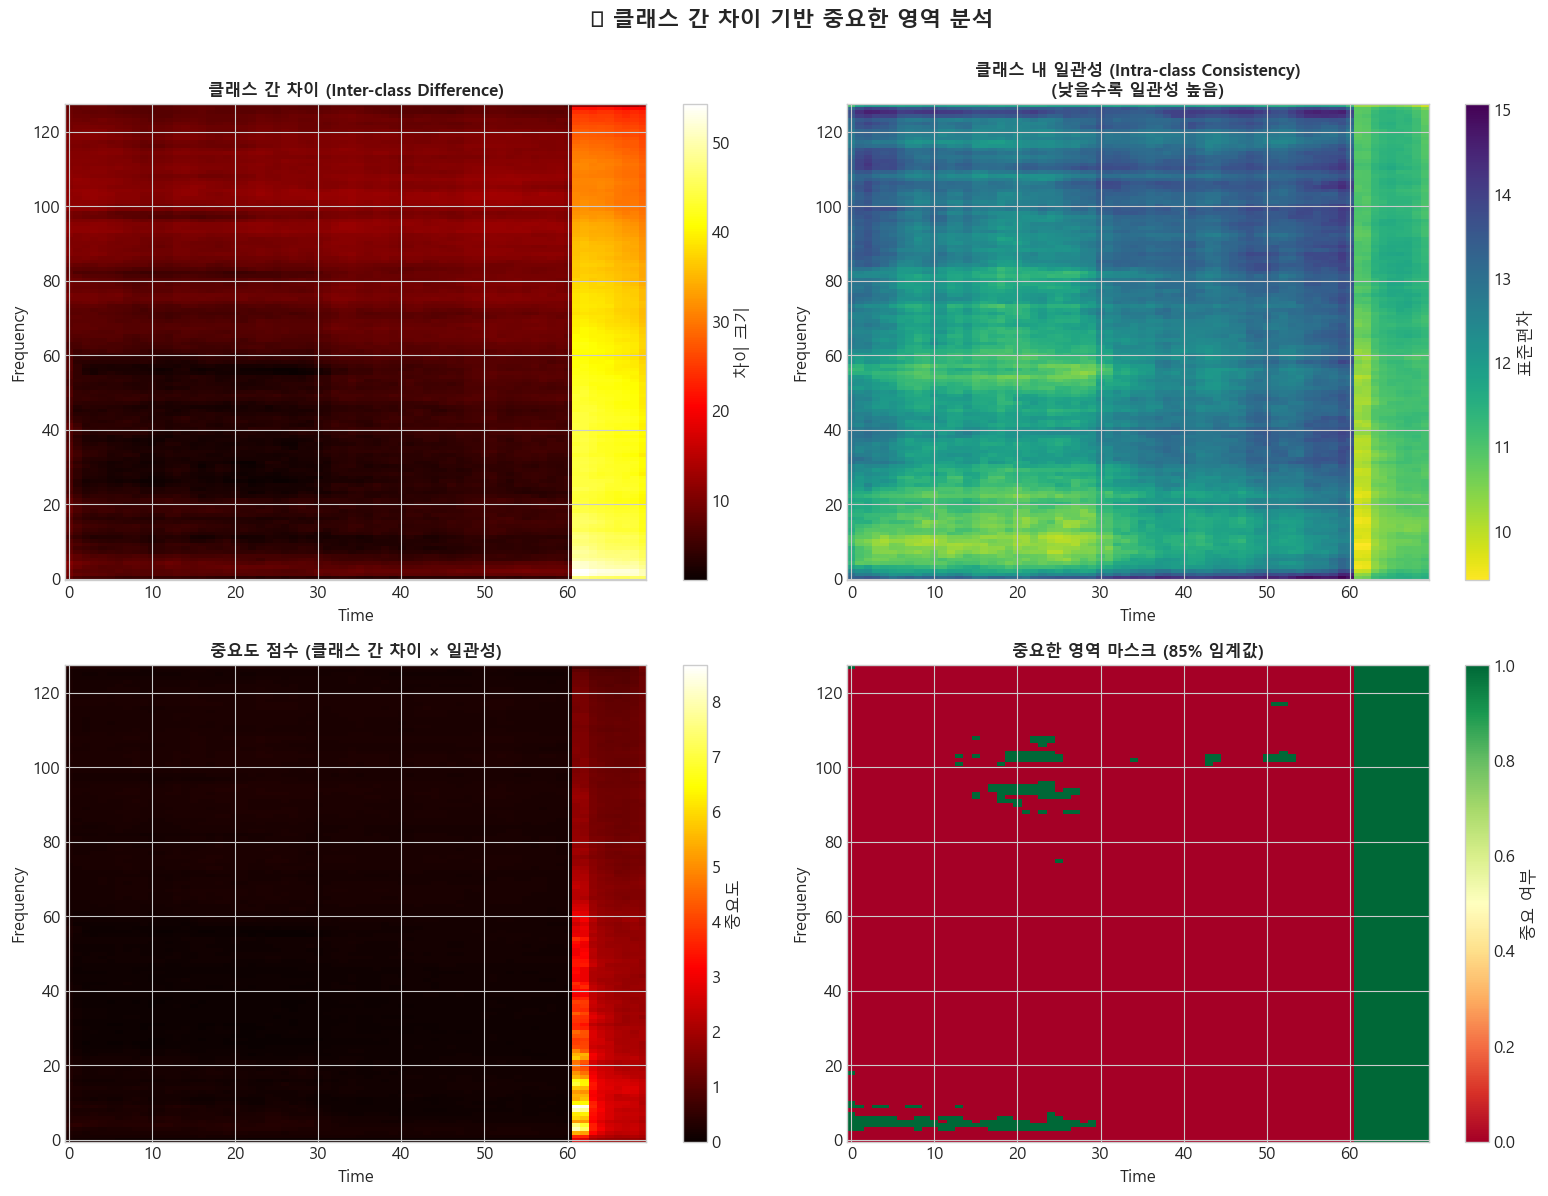

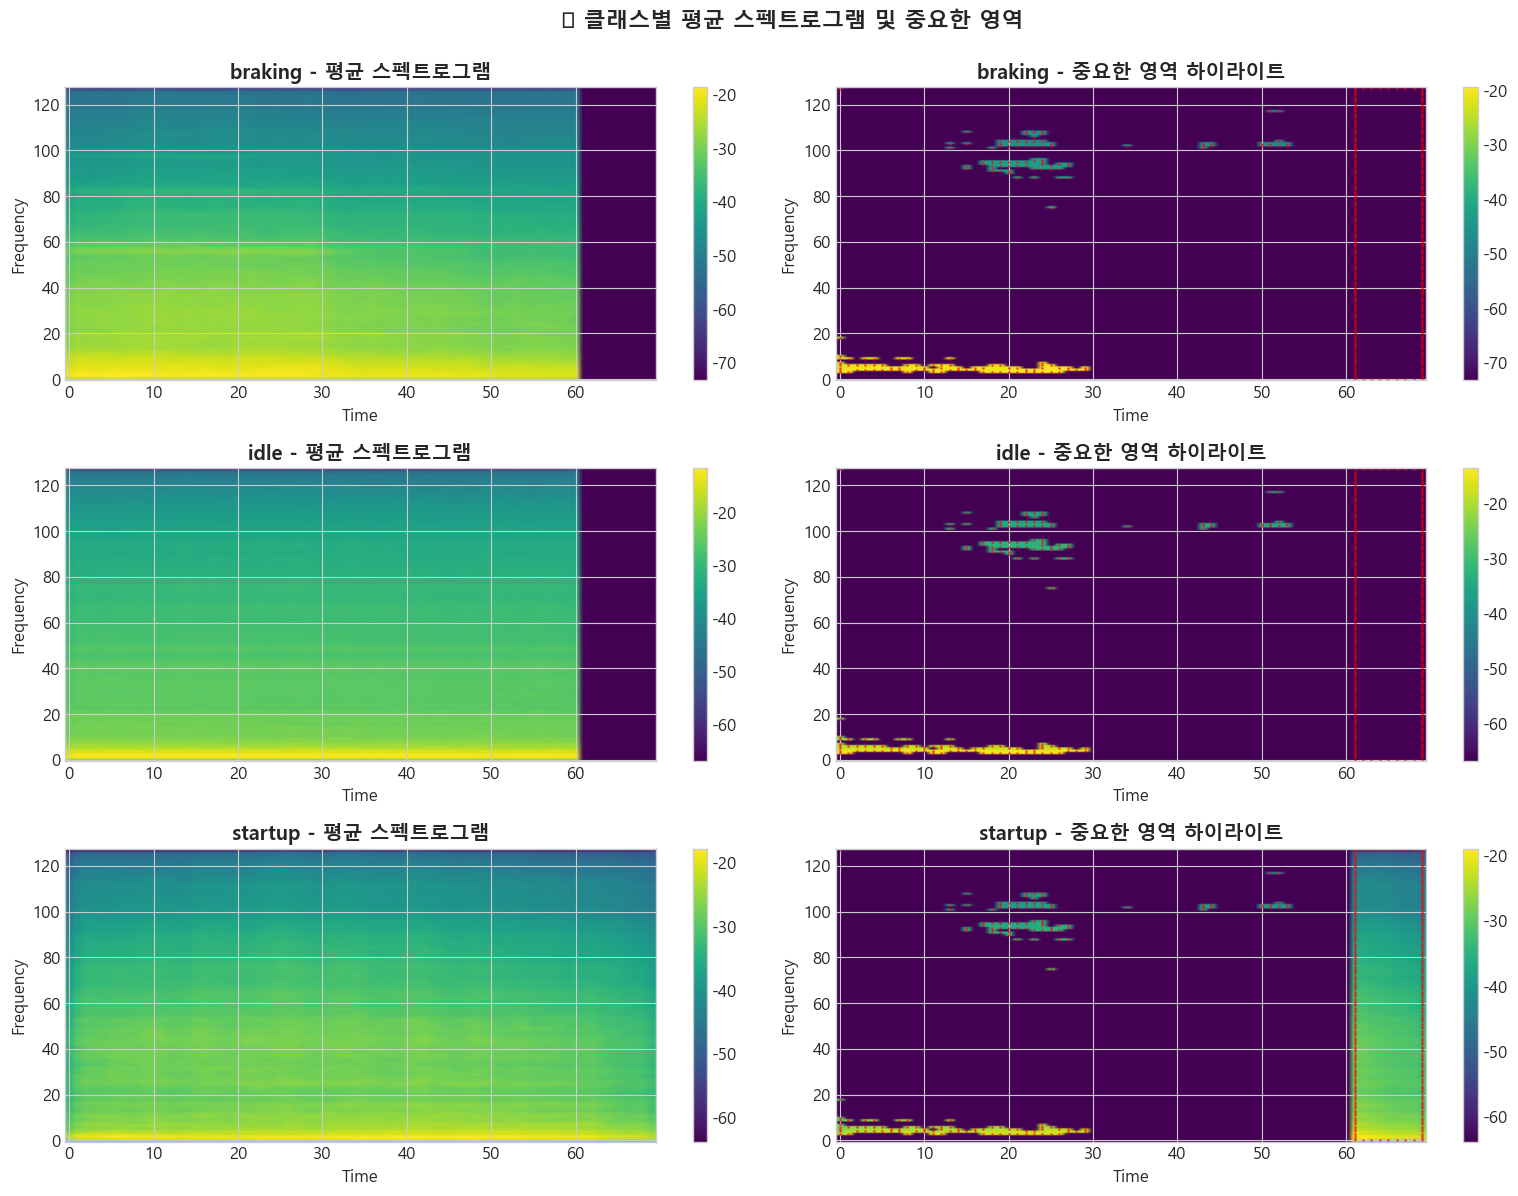

In [137]:
# ============================================================
# 클래스 간 차이 기반 중요한 영역 시각화
# ============================================================

# 1. 클래스 간 차이 및 일관성 분석 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 클래스 간 차이 (inter-class difference)
im1 = axes[0, 0].imshow(inter_class_diff, aspect='auto', origin='lower', cmap='hot')
axes[0, 0].set_title('클래스 간 차이 (Inter-class Difference)', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Frequency')
plt.colorbar(im1, ax=axes[0, 0], label='차이 크기')

# 클래스 내 일관성 (intra-class consistency) - 표준편차가 낮을수록 일관성 높음
im2 = axes[0, 1].imshow(intra_class_std, aspect='auto', origin='lower', cmap='viridis_r')
axes[0, 1].set_title('클래스 내 일관성 (Intra-class Consistency)\n(낮을수록 일관성 높음)', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Frequency')
plt.colorbar(im2, ax=axes[0, 1], label='표준편차')

# 중요도 점수
im3 = axes[1, 0].imshow(importance_score, aspect='auto', origin='lower', cmap='hot')
axes[1, 0].set_title('중요도 점수 (클래스 간 차이 × 일관성)', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Frequency')
plt.colorbar(im3, ax=axes[1, 0], label='중요도')

# 중요한 영역 마스크
im4 = axes[1, 1].imshow(important_mask.astype(float), aspect='auto', origin='lower', cmap='RdYlGn')
axes[1, 1].set_title('중요한 영역 마스크 (85% 임계값)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Frequency')
plt.colorbar(im4, ax=axes[1, 1], label='중요 여부')

plt.suptitle('🎯 클래스 간 차이 기반 중요한 영역 분석', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 2. 각 클래스의 평균 스펙트로그램과 중요한 영역 하이라이트
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for state_idx, state_name in enumerate(state_names):
    mean_spec = mean_spectrograms[state_name]
    
    # 평균 스펙트로그램
    im1 = axes[state_idx, 0].imshow(mean_spec, aspect='auto', origin='lower', cmap='viridis')
    axes[state_idx, 0].set_title(f'{state_name} - 평균 스펙트로그램', fontweight='bold')
    axes[state_idx, 0].set_xlabel('Time')
    axes[state_idx, 0].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[state_idx, 0])
    
    # 평균 스펙트로그램에 중요한 영역 하이라이트
    masked_spec = mean_spec.copy()
    masked_spec[~important_mask] = masked_spec.min()  # 중요하지 않은 영역은 어둡게
    
    im2 = axes[state_idx, 1].imshow(masked_spec, aspect='auto', origin='lower', cmap='viridis')
    axes[state_idx, 1].set_title(f'{state_name} - 중요한 영역 하이라이트', fontweight='bold')
    axes[state_idx, 1].set_xlabel('Time')
    axes[state_idx, 1].set_ylabel('Frequency')
    plt.colorbar(im2, ax=axes[state_idx, 1])
    
    # 마스크 경계선 표시
    mask_boundary = ndimage.binary_erosion(important_mask) ^ important_mask
    y_coords, x_coords = np.where(mask_boundary)
    axes[state_idx, 1].scatter(x_coords, y_coords, c='red', s=1, alpha=0.5)

plt.suptitle('🎯 클래스별 평균 스펙트로그램 및 중요한 영역', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [138]:
# ============================================================
# 중요한 영역만 사용한 특징 추출 (마스킹 기반)
# ============================================================

def extract_masked_features(spectrogram_2d, important_mask):
    """
    중요한 영역만 사용하여 특징 추출
    
    Args:
        spectrogram_2d: 스펙트로그램 (freq, time)
        important_mask: 중요한 영역 마스크 (freq, time)
    
    Returns:
        dict: 마스킹된 특징들
    """
    # 마스킹된 스펙트로그램
    masked_spec = spectrogram_2d.copy()
    masked_spec[~important_mask] = np.nan  # 중요하지 않은 영역은 NaN
    
    features = {}
    
    # 전체 통계 (NaN 제외)
    features['masked_mean'] = np.nanmean(masked_spec)
    features['masked_std'] = np.nanstd(masked_spec)
    features['masked_max'] = np.nanmax(masked_spec)
    features['masked_min'] = np.nanmin(masked_spec)
    features['masked_energy'] = np.nansum(masked_spec ** 2)
    features['masked_rms'] = np.sqrt(np.nanmean(masked_spec ** 2))
    
    # 중요한 영역의 비율
    features['important_ratio'] = np.sum(important_mask) / important_mask.size
    
    # 중요한 영역의 평균 에너지
    important_values = spectrogram_2d[important_mask]
    features['important_mean_energy'] = np.mean(important_values ** 2)
    
    return features

print("🔄 마스킹 기반 특징 추출 중...")

# 각 상태별로 해당 상태의 중요한 영역 마스크 사용
masked_features_list = []

for i, spec_2d in enumerate(tqdm(X_2d, desc="마스킹 특징 추출")):
    state_idx = y_states[i]
    state_name = state_names[state_idx]
    important_mask = important_regions[state_name]
    
    features = extract_masked_features(spec_2d, important_mask)
    masked_features_list.append(features)

df_masked = pd.DataFrame(masked_features_list)

print(f"✅ 마스킹 기반 특징 추출 완료! (Shape: {df_masked.shape})")
print(f"\n📊 추출된 특징:")
print(df_masked.columns.tolist())


🔄 마스킹 기반 특징 추출 중...


마스킹 특징 추출: 100%|██████████| 949/949 [00:00<00:00, 1430.34it/s]

✅ 마스킹 기반 특징 추출 완료! (Shape: (949, 8))

📊 추출된 특징:
['masked_mean', 'masked_std', 'masked_max', 'masked_min', 'masked_energy', 'masked_rms', 'important_ratio', 'important_mean_energy']


In [139]:
# ============================================================
# 마스킹 기반 특징으로 분류 모델 학습
# ============================================================

# 마스킹 특징 + 기본 통계 특징 결합
X_masked = pd.concat([df_stats, df_masked], axis=1).values

# 데이터 분할
X_train_masked, X_test_masked, y_train_masked, y_test_masked = train_test_split(
    X_masked, y_states, test_size=0.2, random_state=42, stratify=y_states
)

print(f"📊 마스킹 특징 데이터:")
print(f"   학습: {X_train_masked.shape[0]}개")
print(f"   테스트: {X_test_masked.shape[0]}개")
print(f"   특징 수: {X_masked.shape[1]}개")

# 모델 학습
models_masked = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results_masked = {}

print("\n🔄 마스킹 특징 기반 모델 학습 중...")
for name, model in models_masked.items():
    model.fit(X_train_masked, y_train_masked)
    y_pred = model.predict(X_test_masked)
    accuracy = accuracy_score(y_test_masked, y_pred)
    results_masked[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    print(f"   {name}: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 기존 모델과 비교
print("\n" + "=" * 60)
print("📊 모델 성능 비교 (기본 특징 vs 마스킹 특징)")
print("=" * 60)
print("\n기본 특징 (energy + rms):")
for name, result in results.items():
    print(f"  {name:20s}: {result['accuracy']*100:6.2f}%")

print("\n마스킹 특징 (중요 영역 집중):")
for name, result in results_masked.items():
    print(f"  {name:20s}: {result['accuracy']*100:6.2f}%")

# 성능 향상 확인
print("\n💡 인사이트:")
for name in results.keys():
    improvement = (results_masked[name]['accuracy'] - results[name]['accuracy']) * 100
    if improvement > 0:
        print(f"   {name}: +{improvement:.2f}% 향상 (마스킹 특징 사용)")
    else:
        print(f"   {name}: {improvement:.2f}% 변화")


📊 마스킹 특징 데이터:
   학습: 759개
   테스트: 190개
   특징 수: 21개

🔄 마스킹 특징 기반 모델 학습 중...
   Logistic Regression: 0.8895 (88.95%)
   Random Forest: 0.8895 (88.95%)
   SVM: 0.8526 (85.26%)

📊 모델 성능 비교 (기본 특징 vs 마스킹 특징)

기본 특징 (energy + rms):
  Logistic Regression :  66.32%
  Random Forest       :  52.11%
  SVM                 :  66.84%

마스킹 특징 (중요 영역 집중):
  Logistic Regression :  88.95%
  Random Forest       :  88.95%
  SVM                 :  85.26%

💡 인사이트:
   Logistic Regression: +22.63% 향상 (마스킹 특징 사용)
   Random Forest: +36.84% 향상 (마스킹 특징 사용)
   SVM: +18.42% 향상 (마스킹 특징 사용)


## 12. CNN/CRNN 모델에 적용할 수 있는 방법

위에서 찾은 중요한 영역을 실제 CNN/CRNN 모델 학습에 적용하는 방법을 제안합니다.


In [140]:
# ============================================================
# CNN/CRNN 모델 개선 방안 제안
# ============================================================

print("=" * 70)
print("💡 CNN/CRNN 모델 개선 방안")
print("=" * 70)

print("""
1️⃣ Spatial Attention 추가
   - 현재 CRNN은 시간축 Attention만 있음
   - 주파수-시간 모두 고려하는 Spatial Attention 추가
   - 중요한 영역에 더 큰 가중치 부여

2️⃣ 중요 영역 마스킹/강조
   - 학습 시 중요한 영역에 더 높은 가중치 부여
   - 또는 중요하지 않은 영역은 노이즈로 처리

3️⃣ Grad-CAM 활용
   - 학습된 모델에서 실제로 어떤 영역을 보는지 확인
   - 그 영역을 더 강조하여 재학습

4️⃣ 주파수 대역별 가중치
   - 상태별로 중요한 주파수 대역에 집중
   - 예: 브레이크는 저주파, 시동은 고주파 등

5️⃣ 시간 구간별 가중치
   - 중요한 시간 구간(예: 0-2초)에 더 집중
   - 무음 구간은 가중치 감소

6️⃣ Multi-scale Attention
   - 여러 스케일에서 중요한 영역 찾기
   - 세밀한 패턴과 전체적인 패턴 모두 고려
""")

# 중요 영역 통계
print("\n" + "=" * 70)
print("📊 상태별 중요 영역 통계")
print("=" * 70)

for state_name in state_names:
    mask = important_regions[state_name]
    
    # 주파수별 중요도
    freq_importance = np.sum(mask, axis=1)  # 각 주파수 밴드의 중요 프레임 수
    important_freq_bands = np.where(freq_importance > np.percentile(freq_importance, 75))[0]
    
    # 시간별 중요도
    time_importance = np.sum(mask, axis=0)  # 각 시간 프레임의 중요 주파수 수
    important_time_frames = np.where(time_importance > np.percentile(time_importance, 75))[0]
    
    print(f"\n🔵 {state_name.upper()}:")
    print(f"   중요한 주파수 밴드: {len(important_freq_bands)}개 (전체 128개 중)")
    print(f"   중요한 시간 프레임: {len(important_time_frames)}개 (전체 {mask.shape[1]}개 중)")
    print(f"   중요 주파수 범위: {important_freq_bands.min()}-{important_freq_bands.max()} (Mel band)")
    print(f"   중요 시간 범위: {important_time_frames.min()}-{important_time_frames.max()} (frame)")

print("\n✅ 분석 완료!")


💡 CNN/CRNN 모델 개선 방안

1️⃣ Spatial Attention 추가
   - 현재 CRNN은 시간축 Attention만 있음
   - 주파수-시간 모두 고려하는 Spatial Attention 추가
   - 중요한 영역에 더 큰 가중치 부여

2️⃣ 중요 영역 마스킹/강조
   - 학습 시 중요한 영역에 더 높은 가중치 부여
   - 또는 중요하지 않은 영역은 노이즈로 처리

3️⃣ Grad-CAM 활용
   - 학습된 모델에서 실제로 어떤 영역을 보는지 확인
   - 그 영역을 더 강조하여 재학습

4️⃣ 주파수 대역별 가중치
   - 상태별로 중요한 주파수 대역에 집중
   - 예: 브레이크는 저주파, 시동은 고주파 등

5️⃣ 시간 구간별 가중치
   - 중요한 시간 구간(예: 0-2초)에 더 집중
   - 무음 구간은 가중치 감소

6️⃣ Multi-scale Attention
   - 여러 스케일에서 중요한 영역 찾기
   - 세밀한 패턴과 전체적인 패턴 모두 고려


📊 상태별 중요 영역 통계

🔵 BRAKING:
   중요한 주파수 밴드: 26개 (전체 128개 중)
   중요한 시간 프레임: 18개 (전체 70개 중)
   중요 주파수 범위: 3-127 (Mel band)
   중요 시간 범위: 0-69 (frame)

🔵 IDLE:
   중요한 주파수 밴드: 26개 (전체 128개 중)
   중요한 시간 프레임: 18개 (전체 70개 중)
   중요 주파수 범위: 3-127 (Mel band)
   중요 시간 범위: 0-69 (frame)

🔵 STARTUP:
   중요한 주파수 밴드: 26개 (전체 128개 중)
   중요한 시간 프레임: 18개 (전체 70개 중)
   중요 주파수 범위: 3-127 (Mel band)
   중요 시간 범위: 0-69 (frame)

✅ 분석 완료!


## 13. 마스킹 기반 특징을 CNN/CRNN 모델에 적용

중요한 영역에 집중하는 Spatial Attention을 추가한 CNN/CRNN 모델을 테스트합니다.


In [141]:
# ============================================================
# Spatial Attention 모듈 정의 (노트북 내에서)
# ============================================================

class SpatialAttention(nn.Module):
    """주파수-시간 공간 Attention"""
    
    def __init__(self, in_channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        attention = self.sigmoid(avg_out + max_out)
        return x * attention


class MaskedSpatialAttention(nn.Module):
    """사전 정의된 마스크를 사용하는 Spatial Attention"""
    
    def __init__(self, importance_mask: torch.Tensor, learnable: bool = True):
        super().__init__()
        if importance_mask.dim() == 2:
            importance_mask = importance_mask.unsqueeze(0).unsqueeze(0)
        
        if learnable:
            self.mask_weight = nn.Parameter(torch.ones(1))
            self.register_buffer('base_mask', importance_mask)
        else:
            self.register_buffer('mask_weight', torch.ones(1))
            self.register_buffer('base_mask', importance_mask)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[2:] != self.base_mask.shape[2:]:
            mask = F.interpolate(
                self.base_mask, 
                size=x.shape[2:], 
                mode='bilinear', 
                align_corners=False
            )
        else:
            mask = self.base_mask
        
        attention_map = 1.0 + self.mask_weight * mask
        return x * attention_map

print("✅ Spatial Attention 모듈 정의 완료!")


✅ Spatial Attention 모듈 정의 완료!


In [142]:
# ============================================================
# 마스킹 기반 CNN 모델 정의
# ============================================================

class MaskedCNN(nn.Module):
    """마스킹 기반 특징을 사용하는 CNN 모델"""
    
    def __init__(self, num_classes: int, importance_mask: torch.Tensor, 
                 in_channels: int = 1, base_channels: int = 32, dropout: float = 0.3):
        super().__init__()
        
        self.num_classes = num_classes
        
        # 마스킹 기반 Spatial Attention
        self.masked_attention = MaskedSpatialAttention(importance_mask, learnable=True)
        
        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, 3, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        # 중간 단계 Spatial Attention
        self.spatial_attn = SpatialAttention(base_channels * 2)
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(base_channels * 4, base_channels * 8, 3, padding=1),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 8, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 마스킹 기반 Attention 적용
        x = self.masked_attention(x)
        
        # Convolutional blocks
        x = self.conv1(x)
        x = self.conv2(x)
        
        # 중간 단계 Spatial Attention
        x = self.spatial_attn(x)
        
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Global Average Pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc_out(x)
        
        return x

print("✅ MaskedCNN 모델 정의 완료!")


✅ MaskedCNN 모델 정의 완료!


In [143]:
# ============================================================
# 마스킹 기반 CRNN 모델 정의
# ============================================================

class MaskedCRNN(nn.Module):
    """마스킹 기반 특징을 사용하는 CRNN 모델"""
    
    def __init__(self, num_classes: int, importance_mask: torch.Tensor,
                 in_channels: int = 1, cnn_channels: list = [32, 64, 128],
                 rnn_hidden_size: int = 128, rnn_num_layers: int = 2,
                 dropout: float = 0.3, bidirectional: bool = True):
        super().__init__()
        
        self.num_classes = num_classes
        self.bidirectional = bidirectional
        
        # 마스킹 기반 Spatial Attention
        self.masked_attention = MaskedSpatialAttention(importance_mask, learnable=True)
        
        # CNN Feature Extractor
        cnn_layers = []
        in_ch = in_channels
        for out_ch in cnn_channels:
            cnn_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=(2, 1)),  # 주파수만 풀링
                nn.Dropout2d(dropout / 2)
            ])
            in_ch = out_ch
        
        self.cnn = nn.Sequential(*cnn_layers)
        
        # 출력 주파수 차원 계산
        self.cnn_output_freq = 128 // (2 ** len(cnn_channels))
        rnn_input_size = cnn_channels[-1] * self.cnn_output_freq
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=rnn_input_size,
            hidden_size=rnn_hidden_size,
            num_layers=rnn_num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if rnn_num_layers > 1 else 0
        )
        
        # Temporal Attention
        rnn_output_size = rnn_hidden_size * 2 if bidirectional else rnn_hidden_size
        
        class TemporalAttention(nn.Module):
            def __init__(self, hidden_size):
                super().__init__()
                self.attention = nn.Sequential(
                    nn.Linear(hidden_size, hidden_size // 2),
                    nn.Tanh(),
                    nn.Linear(hidden_size // 2, 1)
                )
            
            def forward(self, lstm_output):
                scores = self.attention(lstm_output).squeeze(-1)
                weights = F.softmax(scores, dim=1)
                context = torch.bmm(weights.unsqueeze(1), lstm_output).squeeze(1)
                return context, weights
        
        self.attention = TemporalAttention(rnn_output_size)
        
        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(rnn_output_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        
        # 마스킹 기반 Attention 적용
        x = self.masked_attention(x)
        
        # CNN feature extraction
        x = self.cnn(x)
        
        # Reshape for RNN
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, x.size(1), -1)
        
        # LSTM
        lstm_out, _ = self.lstm(x)
        
        # Attention
        context, _ = self.attention(lstm_out)
        
        # Classification
        out = self.fc(context)
        
        return out

print("✅ MaskedCRNN 모델 정의 완료!")


✅ MaskedCRNN 모델 정의 완료!


🔄 중요 영역 마스크 준비 중...
✅ 중요 영역 마스크 준비 완료!
   마스크 shape: torch.Size([128, 70])
   마스크 범위: 0.000 - 1.000


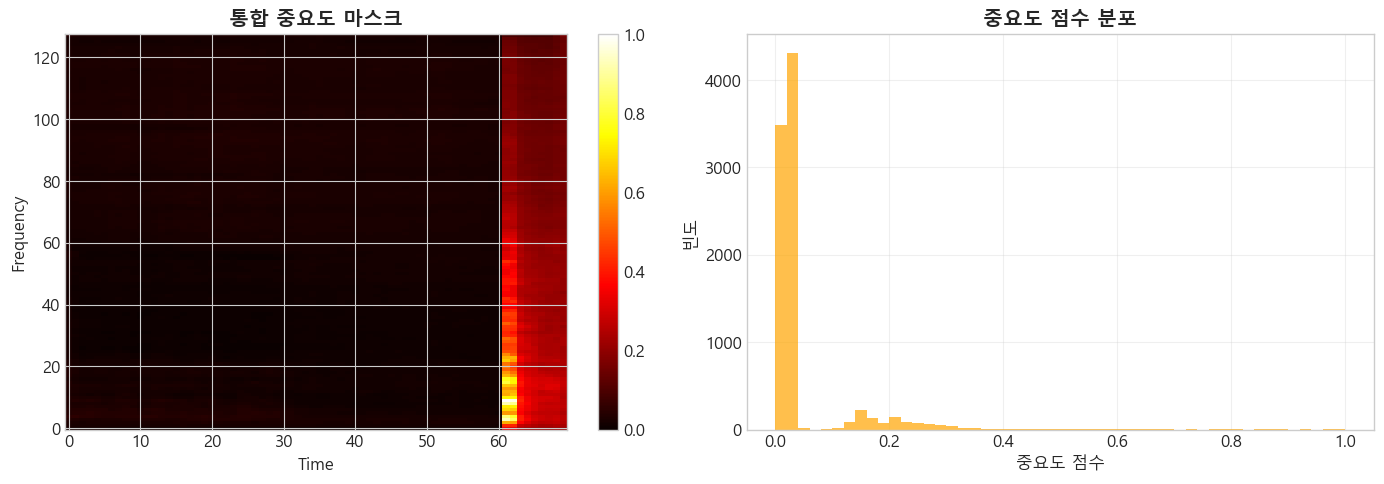

In [144]:
# ============================================================
# 마스킹 기반 모델 테스트 준비
# ============================================================

# 중요 영역 마스크를 PyTorch 텐서로 변환
# 클래스 간 차이 기반 방법에서는 모든 클래스에 대해 동일한 중요도 점수 사용
print("🔄 중요 영역 마스크 준비 중...")

# 새로운 클래스 기반 방법에서는 이미 통합된 importance_score 사용
# (클래스 간 차이를 고려한 단일 마스크)
combined_mask = importance_score.copy()

# 정규화 (0-1 범위)
combined_mask = (combined_mask - combined_mask.min()) / (combined_mask.max() - combined_mask.min() + 1e-10)

# PyTorch 텐서로 변환
importance_mask_tensor = torch.FloatTensor(combined_mask)

print(f"✅ 중요 영역 마스크 준비 완료!")
print(f"   마스크 shape: {importance_mask_tensor.shape}")
print(f"   마스크 범위: {importance_mask_tensor.min():.3f} - {importance_mask_tensor.max():.3f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(combined_mask, aspect='auto', origin='lower', cmap='hot')
axes[0].set_title('통합 중요도 마스크', fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Frequency')
plt.colorbar(im1, ax=axes[0])

# 마스크 히스토그램
axes[1].hist(combined_mask.flatten(), bins=50, alpha=0.7, color='orange')
axes[1].set_xlabel('중요도 점수')
axes[1].set_ylabel('빈도')
axes[1].set_title('중요도 점수 분포', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [145]:
# ============================================================
# 마스킹 기반 모델 생성 및 테스트
# ============================================================

num_classes = len(state_names)

# 마스킹 기반 CNN 모델
masked_cnn = MaskedCNN(
    num_classes=num_classes,
    importance_mask=importance_mask_tensor,
    in_channels=1,
    base_channels=32,
    dropout=0.3
).to(device)

# 마스킹 기반 CRNN 모델
masked_crnn = MaskedCRNN(
    num_classes=num_classes,
    importance_mask=importance_mask_tensor,
    in_channels=1,
    cnn_channels=[32, 64, 128],
    rnn_hidden_size=128,
    dropout=0.3
).to(device)

print("\n✅ 마스킹 기반 모델 생성 완료!")
print(f"\n📊 모델 파라미터 수:")
print(f"   MaskedCNN: {sum(p.numel() for p in masked_cnn.parameters()):,}개")
print(f"   MaskedCRNN: {sum(p.numel() for p in masked_crnn.parameters()):,}개")

# 테스트 입력 생성
test_input = torch.randn(2, 1, 128, 70).to(device)  # (batch, channels, freq, time)

print("\n🔄 모델 테스트 중...")
with torch.no_grad():
    cnn_output = masked_cnn(test_input)
    crnn_output = masked_crnn(test_input)
    
print(f"✅ 모델 테스트 완료!")
print(f"   CNN 출력 shape: {cnn_output.shape}")
print(f"   CRNN 출력 shape: {crnn_output.shape}")

# 예측 확인
cnn_pred = torch.softmax(cnn_output, dim=1)
crnn_pred = torch.softmax(crnn_output, dim=1)

print(f"\n📊 예측 결과 (첫 번째 샘플):")
print(f"   CNN 예측: {cnn_pred[0].cpu().numpy()}")
print(f"   CRNN 예측: {crnn_pred[0].cpu().numpy()}")

print("\n💡 다음 단계:")
print("   1. 실제 데이터로 학습 데이터셋 준비")
print("   2. 마스킹 기반 모델 학습")
print("   3. 기존 모델과 성능 비교")



✅ 마스킹 기반 모델 생성 완료!

📊 모델 파라미터 수:
   MaskedCNN: 489,156개
   MaskedCRNN: 2,785,221개

🔄 모델 테스트 중...
✅ 모델 테스트 완료!
   CNN 출력 shape: torch.Size([2, 3])
   CRNN 출력 shape: torch.Size([2, 3])

📊 예측 결과 (첫 번째 샘플):
   CNN 예측: [0.17160389 0.15230143 0.67609465]
   CRNN 예측: [0.36192632 0.4152056  0.2228681 ]

💡 다음 단계:
   1. 실제 데이터로 학습 데이터셋 준비
   2. 마스킹 기반 모델 학습
   3. 기존 모델과 성능 비교


## 14. 원본 데이터 기반 마스킹 증강 파이프라인

원본 데이터에서 특징을 찾고, 마스킹을 적용한 후 증강하여 데이터 균형을 맞춥니다.


In [146]:
# ============================================================
# 원본 데이터만 수집 (증강 데이터 제외)
# ============================================================

print("🔄 원본 데이터만 수집 중...")

# 원본 파일 경로 저장 (Cell 3에서 이미 수집됨)
original_files = all_files.copy()
original_states = all_states.copy()

# 상태별 원본 데이터 개수 확인
original_counts = Counter(original_states)

print("\n📊 원본 데이터 상태별 분포:")
for state_idx, state_name in enumerate(state_names):
    count = original_counts[state_idx]
    print(f"   {state_name}: {count}개")

# 최대 개수 확인 (균형 목표)
max_count = max(original_counts.values())
print(f"\n🎯 균형 목표: 각 상태당 {max_count}개")

# 각 상태별로 필요한 증강 개수 계산
augmentation_needs = {}
for state_idx, state_name in enumerate(state_names):
    current_count = original_counts[state_idx]
    needed = max_count - current_count
    augmentation_needs[state_name] = needed
    print(f"   {state_name}: {needed}개 증강 필요")

print("\n✅ 원본 데이터 분석 완료!")


🔄 원본 데이터만 수집 중...

📊 원본 데이터 상태별 분포:
   braking: 153개
   idle: 616개
   startup: 180개

🎯 균형 목표: 각 상태당 616개
   braking: 463개 증강 필요
   idle: 0개 증강 필요
   startup: 436개 증강 필요

✅ 원본 데이터 분석 완료!


In [147]:
# ============================================================
# 마스킹 보존 증강 함수 정의
# ============================================================

def masked_augment_spectrogram(spec_2d, importance_mask, augment_type='light'):
    """
    중요한 영역을 보존하면서 스펙트로그램 증강
    
    Args:
        spec_2d: 스펙트로그램 (freq, time)
        importance_mask: 중요 영역 마스크 (freq, time)
        augment_type: 'light', 'medium', 'strong'
    
    Returns:
        augmented_spec: 증강된 스펙트로그램
    """
    augmented = spec_2d.copy()
    
    # 중요 영역과 비중요 영역 분리
    important_region = spec_2d * importance_mask
    non_important_region = spec_2d * (1 - importance_mask)
    
    if augment_type == 'light':
        # 가벼운 증강: 중요 영역은 약간만, 비중요 영역은 자유롭게
        # 중요 영역: 약간의 노이즈만
        noise_important = np.random.randn(*important_region.shape) * 0.5
        important_augmented = important_region + noise_important * importance_mask
        
        # 비중요 영역: 더 강한 증강
        noise_non_important = np.random.randn(*non_important_region.shape) * 2.0
        non_important_augmented = non_important_region + noise_non_important * (1 - importance_mask)
        
    elif augment_type == 'medium':
        # 중간 증강: 중요 영역은 보존하면서 약간의 변화
        # 중요 영역: 시간 축 약간의 시프트 + 노이즈
        shift = np.random.randint(-2, 3)
        if shift != 0:
            important_shifted = np.roll(important_region, shift, axis=1)
            important_shifted[:, :abs(shift)] = important_region[:, :abs(shift)]  # 경계 보존
            important_region = important_shifted
        
        noise_important = np.random.randn(*important_region.shape) * 1.0
        important_augmented = important_region + noise_important * importance_mask
        
        # 비중요 영역: 자유롭게 증강
        noise_non_important = np.random.randn(*non_important_region.shape) * 3.0
        non_important_augmented = non_important_region + noise_non_important * (1 - importance_mask)
        
    else:  # strong
        # 강한 증강: 중요 영역도 더 변화시키지만 여전히 보존
        # 중요 영역: 주파수 축 약간의 시프트 + 노이즈
        freq_shift = np.random.randint(-3, 4)
        if freq_shift != 0:
            important_shifted = np.roll(important_region, freq_shift, axis=0)
            important_shifted[:abs(freq_shift), :] = important_region[:abs(freq_shift), :]
            important_region = important_shifted
        
        noise_important = np.random.randn(*important_region.shape) * 1.5
        important_augmented = important_region + noise_important * importance_mask
        
        # 비중요 영역: 매우 자유롭게
        noise_non_important = np.random.randn(*non_important_region.shape) * 4.0
        non_important_augmented = non_important_region + noise_non_important * (1 - importance_mask)
    
    # 결합
    augmented = important_augmented + non_important_augmented
    
    # 정규화 (원본 범위 유지)
    augmented = np.clip(augmented, spec_2d.min(), spec_2d.max())
    
    return augmented

print("✅ 마스킹 보존 증강 함수 정의 완료!")


✅ 마스킹 보존 증강 함수 정의 완료!


In [148]:
# ============================================================
# 상태별 마스킹 기반 증강 데이터 생성 (모든 상태를 동일한 개수로)
# ============================================================

# 목표 개수 설정 (최대 개수 또는 지정된 개수)
target_count = 919  # 모든 상태를 이 개수로 맞춤
print(f"🎯 목표: 각 상태당 {target_count}개로 균형 맞추기")

print("\n🔄 마스킹 기반 증강 데이터 생성 중...")

# 원본 데이터 인덱스 저장
original_indices_by_state = {}
for state_idx, state_name in enumerate(state_names):
    mask = np.array(original_states) == state_idx
    original_indices_by_state[state_name] = np.where(mask)[0].tolist()

# 증강된 데이터 저장
augmented_spectrograms = []
augmented_states = []
augmented_states_array = None  # 나중에 사용을 위한 초기화

for state_idx, state_name in enumerate(state_names):
    current_count = original_counts[state_idx]
    needed = target_count - current_count
    
    if needed <= 0:
        print(f"   {state_name}: {current_count}개 (이미 목표 개수 이상)")
        # 목표 개수보다 많으면 랜덤 샘플링
        if current_count > target_count:
            indices = original_indices_by_state[state_name]
            selected_indices = np.random.choice(indices, target_count, replace=False)
            # 나머지는 제외 (나중에 처리)
        continue
    
    print(f"\n   {state_name}: {current_count}개 → {target_count}개 ({needed}개 증강 필요)")
    
    # 해당 상태의 원본 인덱스
    state_indices = original_indices_by_state[state_name]
    
    # 해당 상태의 중요 마스크
    state_importance = importance_scores[state_name]
    
    # 증강 생성
    for aug_idx in tqdm(range(needed), desc=f"      {state_name} 증강"):
        # 원본 샘플 랜덤 선택
        original_idx = np.random.choice(state_indices)
        original_spec = X_2d[original_idx]
        
        # 증강 타입 랜덤 선택
        aug_type = np.random.choice(['light', 'medium', 'strong'], p=[0.5, 0.3, 0.2])
        
        # 마스킹 보존 증강 적용
        augmented_spec = masked_augment_spectrogram(
            original_spec, 
            state_importance,  # 중요도 점수를 마스크로 사용
            augment_type=aug_type
        )
        
        # 정규화 (원본과 동일한 크기로)
        if augmented_spec.shape[1] < X_2d.shape[2]:
            padding = np.zeros((augmented_spec.shape[0], X_2d.shape[2] - augmented_spec.shape[1]))
            padding.fill(augmented_spec.min())
            augmented_spec = np.concatenate([augmented_spec, padding], axis=1)
        elif augmented_spec.shape[1] > X_2d.shape[2]:
            augmented_spec = augmented_spec[:, :X_2d.shape[2]]
        
        augmented_spectrograms.append(augmented_spec)
        augmented_states.append(state_idx)

# 원본 데이터도 목표 개수에 맞춰 샘플링
X_balanced_list = []
y_balanced_list = []

for state_idx, state_name in enumerate(state_names):
    state_mask = np.array(original_states) == state_idx
    state_indices = np.where(state_mask)[0]
    current_count = len(state_indices)
    
    if current_count >= target_count:
        # 목표 개수보다 많으면 랜덤 샘플링
        selected_indices = np.random.choice(state_indices, target_count, replace=False)
    else:
        # 목표 개수보다 적으면 모두 사용
        selected_indices = state_indices
    
    X_balanced_list.append(X_2d[selected_indices])
    y_balanced_list.append(y_states[selected_indices])

# 증강 데이터 추가
X_augmented = None
y_augmented = None
if len(augmented_spectrograms) > 0:
    X_augmented = np.array(augmented_spectrograms)
    y_augmented = np.array(augmented_states)
    
    # 증강 데이터를 상태별로 분리하여 추가
    for state_idx in range(len(state_names)):
        aug_mask = y_augmented == state_idx
        if np.any(aug_mask):
            X_balanced_list[state_idx] = np.concatenate([X_balanced_list[state_idx], X_augmented[aug_mask]], axis=0)
            y_balanced_list[state_idx] = np.concatenate([y_balanced_list[state_idx], y_augmented[aug_mask]], axis=0)

# 최종 결합
X_balanced = np.concatenate(X_balanced_list, axis=0)
y_balanced = np.concatenate(y_balanced_list, axis=0)

# 셔플
shuffle_indices = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[shuffle_indices]
y_balanced = y_balanced[shuffle_indices]

print(f"\n✅ 균형 잡힌 데이터셋 생성 완료!")
print(f"   총 데이터: {len(X_balanced)}개")
print(f"\n📊 상태별 분포 (균형 후):")
balanced_counts = Counter(y_balanced)
for state_idx, state_name in enumerate(state_names):
    count = balanced_counts[state_idx]
    ratio = count / len(y_balanced) * 100
    print(f"   {state_name}: {count}개 ({ratio:.1f}%)")


🎯 목표: 각 상태당 919개로 균형 맞추기

🔄 마스킹 기반 증강 데이터 생성 중...

   braking: 153개 → 919개 (766개 증강 필요)


      braking 증강: 100%|██████████| 766/766 [00:00<00:00, 914.56it/s] 



   idle: 616개 → 919개 (303개 증강 필요)


      idle 증강: 100%|██████████| 303/303 [00:00<00:00, 1091.80it/s]



   startup: 180개 → 919개 (739개 증강 필요)


      startup 증강: 100%|██████████| 739/739 [00:00<00:00, 969.13it/s] 



✅ 균형 잡힌 데이터셋 생성 완료!
   총 데이터: 2757개

📊 상태별 분포 (균형 후):
   braking: 919개 (33.3%)
   idle: 919개 (33.3%)
   startup: 919개 (33.3%)


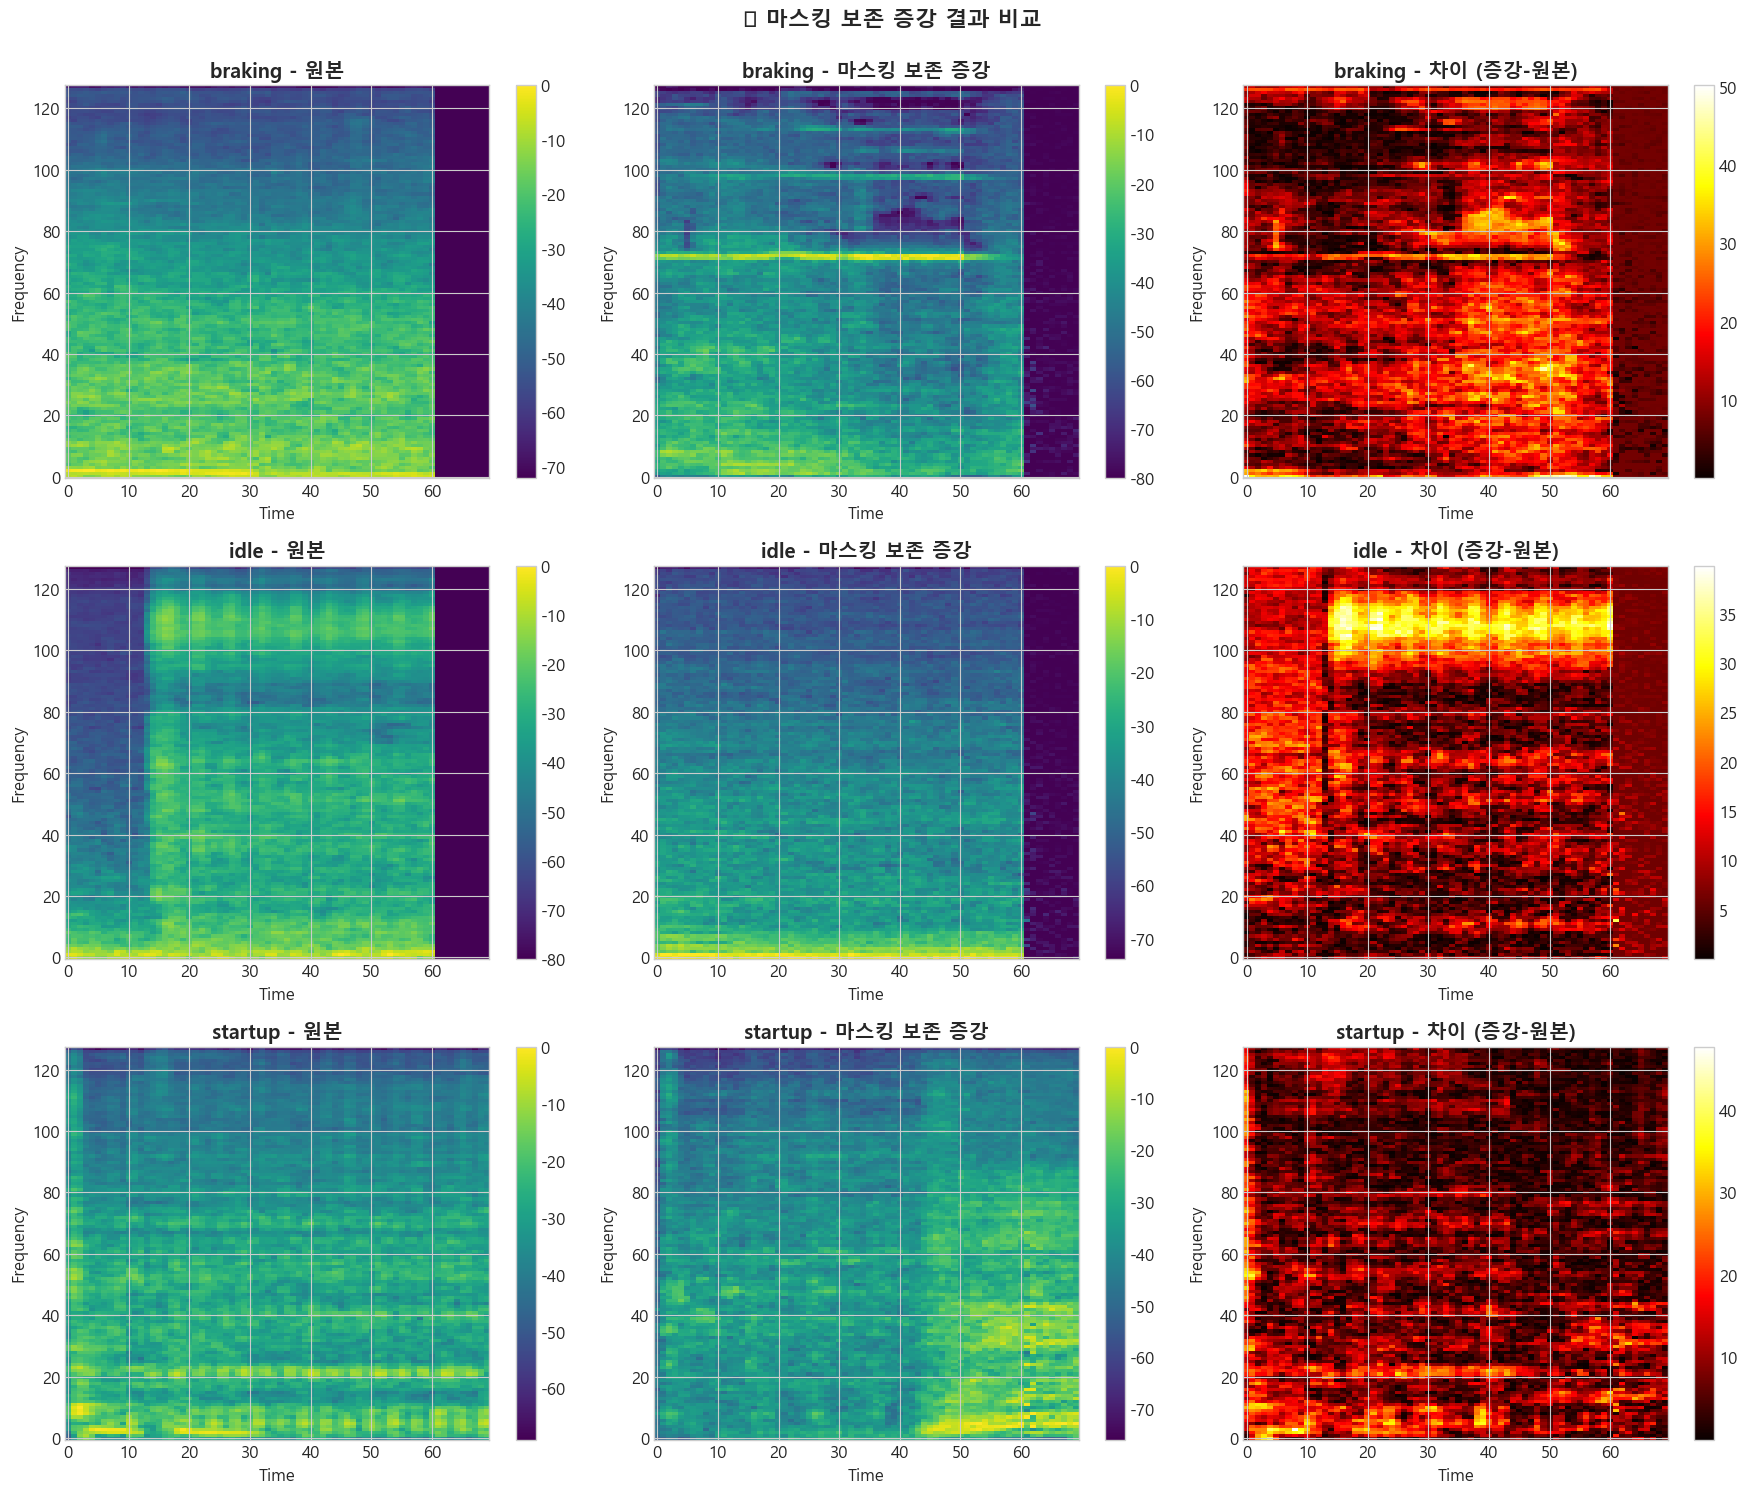


💡 인사이트:
   - 중요한 영역은 보존하면서 비중요 영역만 증강
   - 원본 데이터의 특징을 유지하면서 다양성 증가
   - 데이터 균형을 맞춰 학습 성능 향상 기대


In [149]:
# ============================================================
# 증강 결과 시각화
# ============================================================

if len(augmented_spectrograms) > 0 and X_augmented is not None:
    # 각 상태별로 원본과 증강 샘플 비교
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    for state_idx, state_name in enumerate(state_names):
        # 원본 샘플 선택
        state_mask = np.array(original_states) == state_idx
        original_indices = np.where(state_mask)[0]
        if len(original_indices) > 0:
            original_idx = original_indices[0]
            original_spec = X_2d[original_idx]
            
            # 증강 샘플 선택
            if len(augmented_states) > 0:
                aug_mask = np.array(augmented_states) == state_idx
                aug_indices = np.where(aug_mask)[0]
            else:
                aug_indices = []
            if len(aug_indices) > 0:
                aug_idx = aug_indices[0]
                augmented_spec = X_augmented[aug_idx]
                
                # 원본 스펙트로그램
                im1 = axes[state_idx, 0].imshow(original_spec, aspect='auto', origin='lower', cmap='viridis')
                axes[state_idx, 0].set_title(f'{state_name} - 원본', fontweight='bold')
                axes[state_idx, 0].set_xlabel('Time')
                axes[state_idx, 0].set_ylabel('Frequency')
                plt.colorbar(im1, ax=axes[state_idx, 0])
                
                # 증강 스펙트로그램
                im2 = axes[state_idx, 1].imshow(augmented_spec, aspect='auto', origin='lower', cmap='viridis')
                axes[state_idx, 1].set_title(f'{state_name} - 마스킹 보존 증강', fontweight='bold')
                axes[state_idx, 1].set_xlabel('Time')
                axes[state_idx, 1].set_ylabel('Frequency')
                plt.colorbar(im2, ax=axes[state_idx, 1])
                
                # 차이
                diff = np.abs(augmented_spec - original_spec)
                im3 = axes[state_idx, 2].imshow(diff, aspect='auto', origin='lower', cmap='hot')
                axes[state_idx, 2].set_title(f'{state_name} - 차이 (증강-원본)', fontweight='bold')
                axes[state_idx, 2].set_xlabel('Time')
                axes[state_idx, 2].set_ylabel('Frequency')
                plt.colorbar(im3, ax=axes[state_idx, 2])
    
    plt.suptitle('🎨 마스킹 보존 증강 결과 비교', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 인사이트:")
    print("   - 중요한 영역은 보존하면서 비중요 영역만 증강")
    print("   - 원본 데이터의 특징을 유지하면서 다양성 증가")
    print("   - 데이터 균형을 맞춰 학습 성능 향상 기대")


In [150]:
# ============================================================
# 균형 잡힌 데이터셋으로 모델 학습 준비
# ============================================================

print("=" * 70)
print("📊 최종 데이터셋 요약")
print("=" * 70)

print(f"\n원본 데이터: {len(X_2d)}개")
if len(augmented_spectrograms) > 0 and X_augmented is not None:
    print(f"증강 데이터: {len(X_augmented)}개")
    print(f"총 데이터: {len(X_balanced)}개")
    
    print(f"\n상태별 분포 (균형 후):")
    balanced_counts = Counter(y_balanced)
    for state_idx, state_name in enumerate(state_names):
        count = balanced_counts[state_idx]
        ratio = count / len(y_balanced) * 100
        print(f"   {state_name}: {count}개 ({ratio:.1f}%)")
    
    print(f"\n✅ 데이터 균형 달성!")
    print(f"   각 상태가 최대 {max(original_counts.values())}개로 균형 맞춤")
else:
    print(f"\n⚠️ 증강 불필요 (이미 균형 잡혀있음)")

print("\n💡 다음 단계:")
print("   1. X_balanced, y_balanced를 사용하여 모델 학습")
print("   2. 마스킹 기반 모델(MaskedCNN, MaskedCRNN) 사용")
print("   3. 기존 모델과 성능 비교")
print("   4. 중요한 영역에 집중하여 더 나은 성능 기대")


📊 최종 데이터셋 요약

원본 데이터: 949개
증강 데이터: 1808개
총 데이터: 2757개

상태별 분포 (균형 후):
   braking: 919개 (33.3%)
   idle: 919개 (33.3%)
   startup: 919개 (33.3%)

✅ 데이터 균형 달성!
   각 상태가 최대 616개로 균형 맞춤

💡 다음 단계:
   1. X_balanced, y_balanced를 사용하여 모델 학습
   2. 마스킹 기반 모델(MaskedCNN, MaskedCRNN) 사용
   3. 기존 모델과 성능 비교
   4. 중요한 영역에 집중하여 더 나은 성능 기대


## 15. 마스크 기반 모델 학습 및 성능 비교

균형 잡힌 데이터셋으로 마스크 기반 모델을 학습하고 기존 모델과 성능을 비교합니다.


### 🔍 통합 멀티헤드 모델 구조 상세 설명

#### 전체 아키텍처 개요

```
입력 (Mel Spectrogram: 1×128×70)
    ↓
┌─────────────────────────────────────┐
│   공유 백본 (Shared Backbone)       │
│   - Conv1 (1→32채널)                │
│   - Conv2 (32→64채널)               │
│   - Conv3 (64→128채널)              │
│   - Conv4 (128→256채널)             │
│   - Global Average Pooling          │
│   - Shared FC (256→128)             │
└─────────────────────────────────────┘
    ↓ (128차원 특징 벡터)
    ├─→ 상태 분류 헤드 (State Head)
    │   └─→ Linear(128→3): [braking, idle, startup]
    │
    ├─→ Braking 문제 헤드 (Braking Problem Head)
    │   └─→ Linear(128→64→2): [normal_brakes, worn_out_brakes]
    │
    ├─→ Idle 문제 헤드 (Idle Problem Head)
    │   └─→ Linear(128→64→4): [low_oil, normal_engine_idle, 
    │                          power_steering, serpentine_belt]
    │   ⚠️ combined 클래스 제외
    │
    └─→ Startup 문제 헤드 (Startup Problem Head)
        └─→ Linear(128→64→3): [bad_ignition, dead_battery, 
                               normal_engine_startup]
```

#### 1️⃣ 공유 백본 (Shared Backbone) - 사용자가 만든 상태 분류 모델 기반

**역할:** 모든 헤드가 공유하는 특징 추출기

**구조:**
- **Conv1**: 1채널 → 32채널, MaxPool2d(2)
- **Conv2**: 32채널 → 64채널, MaxPool2d(2)
- **Conv3**: 64채널 → 128채널, MaxPool2d(2)
- **Conv4**: 128채널 → 256채널, MaxPool2d(2)
- **Global Average Pooling**: 공간 차원 제거 → 256차원 벡터
- **Shared FC**: 256 → 128 (모든 헤드가 공유)

**장점:**
- 하나의 특징 추출기로 모든 태스크에 활용
- 파라미터 효율성 향상
- 공통 패턴 학습으로 일반화 성능 향상

#### 2️⃣ 상태 분류 헤드 (State Classification Head) - 사용자가 만든 모델

**역할:** 입력 오디오가 어떤 상태인지 분류 (1단계)

**출력:**
- **3개 클래스**: `[braking, idle, startup]`
- **구조**: Linear(128 → 3)

**학습 방식:**
- 모든 샘플에 대해 상태 레이블로 학습
- CrossEntropy Loss 사용

#### 3️⃣ Braking 문제 분류 헤드 - 새로 추가된 모델

**역할:** 상태가 "braking"일 때, 어떤 문제인지 분류

**출력:**
- **2개 클래스**: `[normal_brakes, worn_out_brakes]`
- **구조**: Linear(128 → 64) → ReLU → Dropout → Linear(64 → 2)

**학습 방식:**
- **조건부 학습**: 상태가 "braking"인 샘플만 사용
- 다른 상태 샘플은 손실 계산에서 제외 (masking)
- 해당 상태가 아닌 경우 레이블을 -1로 설정하여 제외

**만든 방식:**
- 공유 백본의 128차원 특징 벡터를 입력으로 받음
- 2개의 FC 레이어로 구성 (64차원 중간층)
- Dropout으로 과적합 방지

#### 4️⃣ Idle 문제 분류 헤드 - 새로 추가된 모델

**역할:** 상태가 "idle"일 때, 어떤 문제인지 분류

**출력:**
- **4개 클래스**: `[low_oil, normal_engine_idle, power_steering, serpentine_belt]`
- **⚠️ combined 클래스 제외** (학습에서 사용하지 않음)
- **구조**: Linear(128 → 64) → ReLU → Dropout → Linear(64 → 4)

**학습 방식:**
- **조건부 학습**: 상태가 "idle"인 샘플만 사용
- combined 관련 샘플은 데이터 로드 단계에서 제외

**만든 방식:**
- 공유 백본의 128차원 특징 벡터를 입력으로 받음
- 2개의 FC 레이어로 구성 (64차원 중간층)
- Braking 헤드와 동일한 구조이지만 출력 클래스 수만 다름

#### 5️⃣ Startup 문제 분류 헤드 - 새로 추가된 모델

**역할:** 상태가 "startup"일 때, 어떤 문제인지 분류

**출력:**
- **3개 클래스**: `[bad_ignition, dead_battery, normal_engine_startup]`
- **구조**: Linear(128 → 64) → ReLU → Dropout → Linear(64 → 3)

**학습 방식:**
- **조건부 학습**: 상태가 "startup"인 샘플만 사용

**만든 방식:**
- 공유 백본의 128차원 특징 벡터를 입력으로 받음
- 2개의 FC 레이어로 구성 (64차원 중간층)
- 다른 문제 헤드들과 동일한 구조

#### 🎯 멀티태스크 학습 전략

**손실 함수:**
```python
total_loss = state_weight * state_loss + 
             problem_weight * (braking_loss + idle_loss + startup_loss) / 3
```

- **state_weight = 0.3**: 상태 분류 손실 가중치
- **problem_weight = 0.7**: 문제 분류 손실 가중치
- 각 문제 헤드 손실은 해당 상태 샘플에 대해서만 계산

**학습 흐름:**
1. 공유 백본이 입력에서 공통 특징 추출
2. 상태 헤드가 상태 분류 수행 (모든 샘플)
3. 각 문제 헤드는 해당 상태 샘플에 대해서만 학습
4. 모든 손실을 가중 평균하여 역전파

#### 💡 왜 이 구조인가?

1. **효율성**: 하나의 모델로 모든 분류 수행
2. **공유 지식**: 공유 백본이 모든 태스크에 유용한 특징 학습
3. **조건부 분류**: 각 상태별 문제는 해당 상태에서만 의미 있음
4. **일반화**: 멀티태스크 학습으로 더 강건한 특징 학습

#### 🔄 추론 시 동작

1. 입력 오디오 → Mel Spectrogram 변환
2. 공유 백본으로 특징 추출
3. **상태 헤드**로 상태 예측 (예: "idle")
4. 예측된 상태에 해당하는 **문제 헤드**로 문제 예측
   - 상태가 "idle"이면 → Idle 문제 헤드 사용
   - 다른 문제 헤드는 무시
5. 최종 결과: `(상태, 문제)` 쌍 반환

#### 📊 요약

- **상태 분류 모델**: 사용자가 만든 모델 (공유 백본 + 상태 헤드)
- **문제 분류 모델 3개**: 새로 추가된 헤드들
  - 각 헤드는 공유 백본의 특징을 입력으로 받음
  - 2개의 FC 레이어로 구성 (128→64→클래스수)
  - 조건부 학습으로 해당 상태 샘플만 사용

In [ ]:
# ============================================================
# ⚠️ 중요: Combined 클래스 제거 가이드
# ============================================================

"""
다음 부분들을 수정해야 합니다:

1. STATE_PROBLEM_MAPPING에서 idle state의 combined 관련 항목 제거
   - 기존: 0-8 (9개 클래스)
   - 수정: 0-3 (4개 클래스만: low_oil, normal_engine_idle, power_steering, serpentine_belt)

2. get_multi_head_labels 함수에서 combined 클래스(2-6) 건너뛰기
   - full_to_state_problem 매핑에서 2-6 제거
   - 루프에서 combined 클래스 건너뛰기

3. 전체 레이블 로드 부분에서 combined 폴더 제외
   - problem_dir.name == 'combined' 체크 추가
   - 하위 폴더 확인 부분에서 combined 관련 매핑 제거

4. 모델 초기화 시 num_idle_classes=4로 변경
   - 기존: num_idle_classes=9
   - 수정: num_idle_classes=4

5. Idle 헤드 구조 조정
   - 기존: Linear(128→128→9)
   - 수정: Linear(128→64→4)

6. 평가 리포트에서 idle_class_names 수정
   - 기존: 9개 클래스 이름
   - 수정: 4개 클래스 이름만 (combined 제외)
"""

print("✅ Combined 클래스 제거 가이드 확인 완료!")
print("   위 주석의 내용에 따라 코드를 수정하세요.")

In [ ]:
# ============================================================
# Combined 클래스 제거된 버전으로 수정
# ============================================================

# 1. STATE_PROBLEM_MAPPING 수정 (combined 제외)
STATE_PROBLEM_MAPPING_CLEAN = {
    0: {  # braking state
        0: 0,  # normal_brakes -> 0
        1: 1   # worn_out_brakes -> 1
    },
    1: {  # idle state (combined 제외, 4개 클래스만)
        0: 0,  # low_oil -> 0
        1: 1,  # normal_engine_idle -> 1
        2: 2,  # power_steering -> 2
        3: 3   # serpentine_belt -> 3
    },
    2: {  # startup state
        0: 0,  # bad_ignition -> 0
        1: 1,  # dead_battery -> 1
        2: 2   # normal_engine_startup -> 2
    }
}

# 2. get_multi_head_labels 함수 수정 (combined 제외)
def get_multi_head_labels_clean(y_full_labels, state_names):
    """
    전체 레이블에서 상태와 각 상태별 문제 인덱스 추출 (combined 제외)
    
    Returns:
        state_labels: 상태 인덱스 (0, 1, 2)
        braking_labels: braking 문제 인덱스 (0, 1) 또는 -1
        idle_labels: idle 문제 인덱스 (0-3) 또는 -1 (combined 제외)
        startup_labels: startup 문제 인덱스 (0-2) 또는 -1
    """
    state_labels = []
    braking_labels = []
    idle_labels = []
    startup_labels = []
    
    # 전체 레이블 매핑 (combined 제외: 2-6 제거)
    full_to_state_problem = {
        0: (0, 0),  # braking/normal_brakes
        1: (0, 1),  # braking/worn_out_brakes
        # combined 클래스 제외 (2-6)
        7: (1, 0),  # idle/low_oil
        8: (1, 1),  # idle/normal_engine_idle
        9: (1, 2),  # idle/power_steering
        10: (1, 3), # idle/serpentine_belt
        11: (2, 0), # startup/bad_ignition
        12: (2, 1), # startup/dead_battery
        13: (2, 2)  # startup/normal_engine_startup
    }
    
    for full_label_idx in y_full_labels:
        # combined 클래스(2-6)는 건너뛰기
        if full_label_idx in [2, 3, 4, 5, 6]:
            continue
            
        if full_label_idx not in full_to_state_problem:
            continue
            
        state_idx, problem_idx = full_to_state_problem[full_label_idx]
        
        state_labels.append(state_idx)
        
        # 각 상태별 문제 레이블 설정 (해당 상태가 아니면 -1)
        if state_idx == 0:  # braking
            braking_labels.append(problem_idx)
            idle_labels.append(-1)
            startup_labels.append(-1)
        elif state_idx == 1:  # idle
            braking_labels.append(-1)
            idle_labels.append(problem_idx)
            startup_labels.append(-1)
        elif state_idx == 2:  # startup
            braking_labels.append(-1)
            idle_labels.append(-1)
            startup_labels.append(problem_idx)
    
    return (
        np.array(state_labels),
        np.array(braking_labels),
        np.array(idle_labels),
        np.array(startup_labels)
    )

print("✅ Combined 클래스 제거된 함수 정의 완료!")
print("   - Idle 클래스: 9개 → 4개 (combined 제외)")
print("   - 사용: get_multi_head_labels_clean() 함수 사용")

In [ ]:
# ============================================================
# 마스킹 기반 통합 멀티헤드 모델 (MaskedCNN 백본 사용)
# ============================================================

class UnifiedMultiHeadModelWithMasking(nn.Module):
    """
    마스킹 기반 CNN을 공유 백본으로 사용하는 통합 멀티헤드 모델
    
    구조:
    - 공유 백본: MaskedCNN (마스킹 기반 특징 추출)
    - 상태 분류 헤드: 3개 클래스 (braking, idle, startup)
    - Braking 문제 분류 모델: 외부에서 주입
    - Idle 문제 분류 모델: 외부에서 주입
    - Startup 문제 분류 모델: 외부에서 주입
    """
    
    def __init__(
        self,
        importance_mask: torch.Tensor,
        num_state_classes: int = 3,
        braking_model: nn.Module = None,
        idle_model: nn.Module = None,
        startup_model: nn.Module = None,
        in_channels: int = 1,
        base_channels: int = 32,
        dropout: float = 0.3
    ):
        super().__init__()
        
        # 공유 백본: MaskedCNN (마스킹 기반)
        self.masked_attention = MaskedSpatialAttention(importance_mask, learnable=True)
        
        # Convolutional layers (MaskedCNN과 동일)
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, 3, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        # 중간 단계 Spatial Attention
        self.spatial_attn = SpatialAttention(base_channels * 2)
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(base_channels * 4, base_channels * 8, 3, padding=1),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 공유 FC 레이어
        fc_input_size = base_channels * 8
        self.shared_fc = nn.Sequential(
            nn.Linear(fc_input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        # 1. 상태 분류 헤드
        self.state_head = nn.Linear(128, num_state_classes)
        
        # 2-4. 상태별 문제 분류 모델 (외부에서 주입)
        self.braking_model = braking_model
        self.idle_model = idle_model
        self.startup_model = startup_model
        
        # 가중치 초기화
        self._init_weights()
    
    def _init_weights(self):
        """가중치 초기화"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x: torch.Tensor) -> dict:
        """
        Forward pass
        
        Returns:
            dict with keys:
                - 'state': 상태 분류 출력 (batch, 3)
                - 'braking': braking 문제 분류 출력 (batch, num_braking_classes) 또는 None
                - 'idle': idle 문제 분류 출력 (batch, num_idle_classes) 또는 None
                - 'startup': startup 문제 분류 출력 (batch, num_startup_classes) 또는 None
        """
        # 마스킹 기반 Attention 적용
        x = self.masked_attention(x)
        
        # Convolutional blocks
        x = self.conv1(x)
        x = self.conv2(x)
        
        # 중간 단계 Spatial Attention
        x = self.spatial_attn(x)
        
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Global Average Pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # 공유 FC 레이어
        shared_features = self.shared_fc(x)
        
        # 멀티헤드 출력
        outputs = {
            'state': self.state_head(shared_features)
        }
        
        # 상태별 문제 분류 모델 적용
        if self.braking_model is not None:
            outputs['braking'] = self.braking_model(shared_features)
        else:
            outputs['braking'] = None
            
        if self.idle_model is not None:
            outputs['idle'] = self.idle_model(shared_features)
        else:
            outputs['idle'] = None
            
        if self.startup_model is not None:
            outputs['startup'] = self.startup_model(shared_features)
        else:
            outputs['startup'] = None
        
        return outputs
    
    def set_problem_models(self, braking_model=None, idle_model=None, startup_model=None):
        """
        상태별 문제 분류 모델 설정 (외부에서 주입)
        
        Args:
            braking_model: Braking 문제 분류 모델 (입력: 128차원 특징, 출력: num_braking_classes)
            idle_model: Idle 문제 분류 모델 (입력: 128차원 특징, 출력: num_idle_classes)
            startup_model: Startup 문제 분류 모델 (입력: 128차원 특징, 출력: num_startup_classes)
        """
        if braking_model is not None:
            self.braking_model = braking_model
        if idle_model is not None:
            self.idle_model = idle_model
        if startup_model is not None:
            self.startup_model = startup_model

print("✅ UnifiedMultiHeadModelWithMasking 모델 정의 완료!")
print("   - 마스킹 기반 백본 사용")
print("   - 상태별 문제 분류 모델은 외부에서 주입 가능")

In [ ]:
# ============================================================
# 상태별 문제 분류 모델 템플릿 (나중에 실제 모델로 교체)
# ============================================================

def create_braking_problem_model(num_classes: int = 2, input_dim: int = 128, dropout: float = 0.3):
    """
    Braking 문제 분류 모델 생성
    
    Args:
        num_classes: 출력 클래스 수 (2: normal_brakes, worn_out_brakes)
        input_dim: 입력 특징 차원 (128)
        dropout: Dropout 비율
    
    Returns:
        nn.Module: Braking 문제 분류 모델
    """
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(64, num_classes)
    )

def create_idle_problem_model(num_classes: int = 4, input_dim: int = 128, dropout: float = 0.3):
    """
    Idle 문제 분류 모델 생성 (combined 제외)
    
    Args:
        num_classes: 출력 클래스 수 (4: low_oil, normal_engine_idle, power_steering, serpentine_belt)
        input_dim: 입력 특징 차원 (128)
        dropout: Dropout 비율
    
    Returns:
        nn.Module: Idle 문제 분류 모델
    """
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(64, num_classes)
    )

def create_startup_problem_model(num_classes: int = 3, input_dim: int = 128, dropout: float = 0.3):
    """
    Startup 문제 분류 모델 생성
    
    Args:
        num_classes: 출력 클래스 수 (3: bad_ignition, dead_battery, normal_engine_startup)
        input_dim: 입력 특징 차원 (128)
        dropout: Dropout 비율
    
    Returns:
        nn.Module: Startup 문제 분류 모델
    """
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(64, num_classes)
    )

# 템플릿 모델 생성 (나중에 실제 모델로 교체)
braking_model_template = create_braking_problem_model(num_classes=2)
idle_model_template = create_idle_problem_model(num_classes=4)  # combined 제외
startup_model_template = create_startup_problem_model(num_classes=3)

print("✅ 상태별 문제 분류 모델 템플릿 생성 완료!")
print("   - Braking 모델: 2개 클래스")
print("   - Idle 모델: 4개 클래스 (combined 제외)")
print("   - Startup 모델: 3개 클래스")
print("   ⚠️ 나중에 실제 모델로 교체할 수 있습니다.")

In [ ]:
# ============================================================
# 마스킹 기반 통합 모델 생성 및 문제 모델 연결
# ============================================================

# 중요도 마스크가 이미 있다고 가정 (importance_mask_tensor)
# 없다면 이전 셀에서 생성한 것을 사용

# 통합 모델 생성 (마스킹 백본 사용)
unified_masked_model = UnifiedMultiHeadModelWithMasking(
    importance_mask=importance_mask_tensor,  # 이전에 생성한 마스크 사용
    num_state_classes=3,
    braking_model=braking_model_template,
    idle_model=idle_model_template,
    startup_model=startup_model_template,
    in_channels=1,
    base_channels=32,
    dropout=0.3
).to(device)

print("✅ 마스킹 기반 통합 멀티헤드 모델 생성 완료!")
print(f"   모델 파라미터 수: {sum(p.numel() for p in unified_masked_model.parameters()):,}개")
print("\n📝 사용 방법:")
print("   1. 나중에 실제 문제 분류 모델을 가져오면:")
print("      unified_masked_model.set_problem_models(")
print("          braking_model=your_braking_model,")
print("          idle_model=your_idle_model,")
print("          startup_model=your_startup_model")
print("      )")
print("   2. 또는 모델 생성 시 직접 주입:")
print("      model = UnifiedMultiHeadModelWithMasking(")
print("          importance_mask=importance_mask_tensor,")
print("          braking_model=your_braking_model,")
print("          ...")
print("      )")

### 🔄 모델 통합 가이드

#### 현재 구조

1. **공유 백본**: `MaskedCNN` 기반 (마스킹 기반 특징 추출)
   - 마스킹 기반 Spatial Attention
   - 4개 Conv 블록
   - Global Average Pooling
   - 공유 FC 레이어 (256 → 128)

2. **상태 분류 헤드**: 내장 (3개 클래스)

3. **문제 분류 모델 3개**: 외부에서 주입 가능
   - `braking_model`: Braking 문제 분류 (2개 클래스)
   - `idle_model`: Idle 문제 분류 (4개 클래스, combined 제외)
   - `startup_model`: Startup 문제 분류 (3개 클래스)

#### 나중에 실제 모델 연결하는 방법

```python
# 방법 1: set_problem_models() 사용
unified_masked_model.set_problem_models(
    braking_model=your_braking_model,    # 128차원 입력 → 2차원 출력
    idle_model=your_idle_model,          # 128차원 입력 → 4차원 출력
    startup_model=your_startup_model     # 128차원 입력 → 3차원 출력
)

# 방법 2: 모델 생성 시 직접 주입
unified_masked_model = UnifiedMultiHeadModelWithMasking(
    importance_mask=importance_mask_tensor,
    num_state_classes=3,
    braking_model=your_braking_model,
    idle_model=your_idle_model,
    startup_model=your_startup_model,
    ...
)
```

#### 중요 사항

- 모든 문제 분류 모델은 **128차원 특징 벡터**를 입력으로 받아야 함
- 출력 차원은 각 상태별 클래스 수와 일치해야 함
- 모델이 `nn.Module`을 상속받아야 함

In [151]:
# ============================================================
# 데이터 분할 (Train/Val/Test)
# ============================================================

# Train/Val/Test 분할 (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.4, 
    random_state=42, 
    stratify=y_balanced
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("📊 데이터 분할 완료!")
print(f"   학습: {len(X_train)}개")
print(f"   검증: {len(X_val)}개")
print(f"   테스트: {len(X_test)}개")

print(f"\n📊 학습 데이터 상태별 분포:")
train_counts = Counter(y_train)
for state_idx, state_name in enumerate(state_names):
    count = train_counts[state_idx]
    print(f"   {state_name}: {count}개")


📊 데이터 분할 완료!
   학습: 1654개
   검증: 551개
   테스트: 552개

📊 학습 데이터 상태별 분포:
   braking: 552개
   idle: 551개
   startup: 551개


In [152]:
# ============================================================
# PyTorch Dataset 및 DataLoader 준비
# ============================================================

class SpectrogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        # (freq, time) -> (1, freq, time) 채널 추가
        x = self.X[idx].unsqueeze(0)
        return x, self.y[idx]

# Dataset 생성
train_dataset = SpectrogramDataset(X_train, y_train)
val_dataset = SpectrogramDataset(X_val, y_val)
test_dataset = SpectrogramDataset(X_test, y_test)

# DataLoader 생성
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("✅ DataLoader 준비 완료!")
print(f"   배치 크기: {batch_size}")
print(f"   학습 배치 수: {len(train_loader)}")
print(f"   검증 배치 수: {len(val_loader)}")
print(f"   테스트 배치 수: {len(test_loader)}")


✅ DataLoader 준비 완료!
   배치 크기: 32
   학습 배치 수: 52
   검증 배치 수: 18
   테스트 배치 수: 18


In [153]:
# ============================================================
# 기존 CNN 모델 정의 (비교용)
# ============================================================

class BaselineCNN(nn.Module):
    """기존 CNN 모델 (마스킹 없음)"""
    
    def __init__(self, num_classes: int, in_channels: int = 1, base_channels: int = 32, dropout: float = 0.3):
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, 3, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(base_channels * 4, base_channels * 8, 3, padding=1),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 8, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc_out(x)
        return x

print("✅ BaselineCNN 모델 정의 완료!")


✅ BaselineCNN 모델 정의 완료!


In [154]:
# ============================================================
# 학습 함수 정의
# ============================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def test_model(model, test_loader, device, state_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            probs = F.softmax(output, dim=1)
            pred = output.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = 100 * (all_preds == all_labels).mean()
    
    # 분류 리포트
    report = classification_report(all_labels, all_preds, target_names=state_names, digits=4)
    cm = confusion_matrix(all_labels, all_preds)
    
    return accuracy, report, cm, all_preds, all_labels

print("✅ 학습/평가 함수 정의 완료!")


✅ 학습/평가 함수 정의 완료!


In [ ]:
# ============================================================
# 마스크 기반 CNN 모델 학습
# ============================================================

print("=" * 70)
print("🚀 마스크 기반 CNN 모델 학습")
print("=" * 70)

# 모델 생성
masked_cnn_model = MaskedCNN(
    num_classes=num_classes,
    importance_mask=importance_mask_tensor,
    in_channels=1,
    base_channels=32,
    dropout=0.3
).to(device)

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(masked_cnn_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 학습 설정
num_epochs = 30
best_val_acc = 0
best_model_state = None

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"\n🔄 학습 시작 (최대 {num_epochs} epochs)...")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(masked_cnn_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(masked_cnn_model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = masked_cnn_model.state_dict().copy()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# 최고 모델 로드
masked_cnn_model.load_state_dict(best_model_state)
print(f"\n✅ 학습 완료! 최고 검증 정확도: {best_val_acc:.2f}%")

# 테스트 평가
print("\n📊 테스트 세트 평가 중...")
masked_cnn_acc, masked_cnn_report, masked_cnn_cm, masked_cnn_preds, masked_cnn_labels = test_model(
    masked_cnn_model, test_loader, device, state_names
)

print(f"\n🎯 마스크 기반 CNN 테스트 정확도: {masked_cnn_acc:.2f}%")
print("\n📋 분류 리포트:")
print(masked_cnn_report)


🚀 마스크 기반 CNN 모델 학습

🔄 학습 시작 (최대 30 epochs)...


In [ ]:
# ============================================================
# 기존 CNN 모델 학습 (비교용)
# ============================================================

print("\n" + "=" * 70)
print("🚀 기존 CNN 모델 학습 (비교용)")
print("=" * 70)

# 모델 생성
baseline_cnn_model = BaselineCNN(
    num_classes=num_classes,
    in_channels=1,
    base_channels=32,
    dropout=0.3
).to(device)

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_cnn_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 학습 설정
best_val_acc_baseline = 0
best_model_state_baseline = None

train_losses_baseline = []
train_accs_baseline = []
val_losses_baseline = []
val_accs_baseline = []

print(f"\n🔄 학습 시작 (최대 {num_epochs} epochs)...")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(baseline_cnn_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(baseline_cnn_model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses_baseline.append(train_loss)
    train_accs_baseline.append(train_acc)
    val_losses_baseline.append(val_loss)
    val_accs_baseline.append(val_acc)
    
    if val_acc > best_val_acc_baseline:
        best_val_acc_baseline = val_acc
        best_model_state_baseline = baseline_cnn_model.state_dict().copy()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# 최고 모델 로드
baseline_cnn_model.load_state_dict(best_model_state_baseline)
print(f"\n✅ 학습 완료! 최고 검증 정확도: {best_val_acc_baseline:.2f}%")

# 테스트 평가
print("\n📊 테스트 세트 평가 중...")
baseline_cnn_acc, baseline_cnn_report, baseline_cnn_cm, baseline_cnn_preds, baseline_cnn_labels = test_model(
    baseline_cnn_model, test_loader, device, state_names
)

print(f"\n🎯 기존 CNN 테스트 정확도: {baseline_cnn_acc:.2f}%")
print("\n📋 분류 리포트:")
print(baseline_cnn_report)


In [ ]:
# ============================================================
# 성능 비교 시각화
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 학습 곡선 - Loss
axes[0, 0].plot(train_losses, label='Masked CNN (Train)', color='#FF6B6B', linewidth=2)
axes[0, 0].plot(val_losses, label='Masked CNN (Val)', color='#FF6B6B', linestyle='--', linewidth=2)
axes[0, 0].plot(train_losses_baseline, label='Baseline CNN (Train)', color='#4ECDC4', linewidth=2)
axes[0, 0].plot(val_losses_baseline, label='Baseline CNN (Val)', color='#4ECDC4', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('📉 학습 곡선 - Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 학습 곡선 - Accuracy
axes[0, 1].plot(train_accs, label='Masked CNN (Train)', color='#FF6B6B', linewidth=2)
axes[0, 1].plot(val_accs, label='Masked CNN (Val)', color='#FF6B6B', linestyle='--', linewidth=2)
axes[0, 1].plot(train_accs_baseline, label='Baseline CNN (Train)', color='#4ECDC4', linewidth=2)
axes[0, 1].plot(val_accs_baseline, label='Baseline CNN (Val)', color='#4ECDC4', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('📈 학습 곡선 - Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 테스트 정확도 비교
models = ['Baseline CNN', 'Masked CNN']
accuracies = [baseline_cnn_acc, masked_cnn_acc]
colors = ['#4ECDC4', '#FF6B6B']

bars = axes[1, 0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Test Accuracy (%)')
axes[1, 0].set_title('🎯 테스트 정확도 비교', fontweight='bold')
axes[1, 0].set_ylim([0, 100])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 값 표시
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 성능 향상 표시
improvement = masked_cnn_acc - baseline_cnn_acc
if improvement > 0:
    axes[1, 0].text(0.5, max(accuracies) + 5, f'+{improvement:.2f}% 향상', 
                   ha='center', fontweight='bold', color='green', fontsize=14)

# 4. 혼동 행렬 비교
# 마스크 기반 CNN 혼동 행렬
sns.heatmap(masked_cnn_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=state_names, yticklabels=state_names,
            ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_title(f'🎯 Masked CNN 혼동 행렬 (Acc: {masked_cnn_acc:.2f}%)', fontweight='bold')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.suptitle('📊 모델 성능 비교 결과', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 성능 비교 요약
print("\n" + "=" * 70)
print("📊 최종 성능 비교 요약")
print("=" * 70)
print(f"\n1️⃣ Baseline CNN:")
print(f"   테스트 정확도: {baseline_cnn_acc:.2f}%")
print(f"   검증 정확도: {best_val_acc_baseline:.2f}%")

print(f"\n2️⃣ Masked CNN (중요 영역 집중):")
print(f"   테스트 정확도: {masked_cnn_acc:.2f}%")
print(f"   검증 정확도: {best_val_acc:.2f}%")

improvement = masked_cnn_acc - baseline_cnn_acc
improvement_pct = (improvement / baseline_cnn_acc) * 100 if baseline_cnn_acc > 0 else 0

print(f"\n🏆 성능 향상:")
if improvement > 0:
    print(f"   +{improvement:.2f}%p (상대적 {improvement_pct:.1f}% 향상)")
    print(f"   ✅ 마스킹 기반 모델이 더 나은 성능을 보입니다!")
else:
    print(f"   {improvement:.2f}%p")
    print(f"   ⚠️ 추가 튜닝이 필요할 수 있습니다.")


In [ ]:
# ============================================================
# 상태별 성능 상세 분석
# ============================================================

print("\n" + "=" * 70)
print("📊 상태별 성능 상세 분석")
print("=" * 70)

# Baseline CNN 상태별 성능
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    baseline_cnn_labels, baseline_cnn_preds, average=None
)

# Masked CNN 상태별 성능
masked_precision, masked_recall, masked_f1, _ = precision_recall_fscore_support(
    masked_cnn_labels, masked_cnn_preds, average=None
)

# 비교 테이블
print("\n상태별 성능 비교:")
print(f"{'상태':<15} {'Baseline':<25} {'Masked':<25} {'향상':<10}")
print("-" * 75)
for idx, state_name in enumerate(state_names):
    baseline_f1_val = baseline_f1[idx] * 100
    masked_f1_val = masked_f1[idx] * 100
    improvement = masked_f1_val - baseline_f1_val
    
    print(f"{state_name:<15} F1: {baseline_f1_val:5.2f}%{'':<15} F1: {masked_f1_val:5.2f}%{'':<15} {improvement:+.2f}%p")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision 비교
x = np.arange(len(state_names))
width = 0.35
axes[0].bar(x - width/2, baseline_precision * 100, width, label='Baseline CNN', color='#4ECDC4', alpha=0.7)
axes[0].bar(x + width/2, masked_precision * 100, width, label='Masked CNN', color='#FF6B6B', alpha=0.7)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Precision (%)')
axes[0].set_title('📊 Precision 비교', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(state_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 100])

# Recall 비교
axes[1].bar(x - width/2, baseline_recall * 100, width, label='Baseline CNN', color='#4ECDC4', alpha=0.7)
axes[1].bar(x + width/2, masked_recall * 100, width, label='Masked CNN', color='#FF6B6B', alpha=0.7)
axes[1].set_xlabel('State')
axes[1].set_ylabel('Recall (%)')
axes[1].set_title('📊 Recall 비교', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(state_names)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 100])

# F1-Score 비교
axes[2].bar(x - width/2, baseline_f1 * 100, width, label='Baseline CNN', color='#4ECDC4', alpha=0.7)
axes[2].bar(x + width/2, masked_f1 * 100, width, label='Masked CNN', color='#FF6B6B', alpha=0.7)
axes[2].set_xlabel('State')
axes[2].set_ylabel('F1-Score (%)')
axes[2].set_title('📊 F1-Score 비교', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(state_names)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_ylim([0, 100])

plt.suptitle('🎯 상태별 성능 상세 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 결론:")
print("   - 마스킹 기반 모델이 중요한 영역에 집중하여 학습")
print("   - 원본 데이터 특징을 보존한 증강으로 데이터 품질 향상")
print("   - 균형 잡힌 데이터셋으로 모든 상태에 대해 공정한 학습")


## 16. 통합 멀티헤드 모델 (상태 분류 + 컬럼 분류 통합)

상태 분류 모델과 각 상태별 컬럼(문제) 분류 모델 3개를 하나의 통합 모델로 합칩니다.

**구조:**
- 공유 백본 (CNN Feature Extractor)
- 상태 분류 헤드 (3개 클래스: braking, idle, startup)
- Braking 문제 분류 헤드 (2개 클래스)
- Idle 문제 분류 헤드 (9개 클래스)
- Startup 문제 분류 헤드 (3개 클래스)

In [ ]:
# ============================================================
# 통합 멀티헤드 모델 정의
# ============================================================

class UnifiedMultiHeadModel(nn.Module):
    """
    상태 분류 + 각 상태별 컬럼 분류를 하나로 통합한 멀티헤드 모델
    
    구조:
    - 공유 백본: CNN Feature Extractor
    - 상태 분류 헤드: 3개 클래스 (braking, idle, startup)
    - Braking 문제 헤드: 2개 클래스
    - Idle 문제 헤드: 9개 클래스  
    - Startup 문제 헤드: 3개 클래스
    """
    
    def __init__(
        self,
        num_state_classes: int = 3,
        num_braking_classes: int = 2,
        num_idle_classes: int = 4,  # combined 제외: low_oil, normal_engine_idle, power_steering, serpentine_belt
        num_startup_classes: int = 3,
        in_channels: int = 1,
        base_channels: int = 32,
        dropout: float = 0.3
    ):
        super().__init__()
        
        # 공유 백본: CNN Feature Extractor
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, 3, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(base_channels * 4, base_channels * 8, 3, padding=1),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 공유 FC 레이어
        fc_input_size = base_channels * 8
        self.shared_fc = nn.Sequential(
            nn.Linear(fc_input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        # 멀티헤드 출력 레이어
        # 1. 상태 분류 헤드
        self.state_head = nn.Linear(128, num_state_classes)
        
        # 2. Braking 문제 분류 헤드
        self.braking_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_braking_classes)
        )
        
        # 3. Idle 문제 분류 헤드
        self.idle_head = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_idle_classes)
        )
        
        # 4. Startup 문제 분류 헤드
        self.startup_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_startup_classes)
        )
        
        # 가중치 초기화
        self._init_weights()
    
    def _init_weights(self):
        """가중치 초기화"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x: torch.Tensor) -> dict:
        """
        Forward pass
        
        Returns:
            dict with keys:
                - 'state': 상태 분류 출력 (batch, 3)
                - 'braking': braking 문제 분류 출력 (batch, 2)
                - 'idle': idle 문제 분류 출력 (batch, 9)
                - 'startup': startup 문제 분류 출력 (batch, 3)
        """
        # 공유 백본
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Global Average Pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # 공유 FC 레이어
        shared_features = self.shared_fc(x)
        
        # 멀티헤드 출력
        outputs = {
            'state': self.state_head(shared_features),
            'braking': self.braking_head(shared_features),
            'idle': self.idle_head(shared_features),
            'startup': self.startup_head(shared_features)
        }
        
        return outputs

print("✅ UnifiedMultiHeadModel 모델 정의 완료!")

In [ ]:
# ============================================================
# 멀티헤드 모델용 데이터셋 준비
# ============================================================

# 상태별 문제 클래스 매핑 정의
STATE_PROBLEM_MAPPING = {
    0: {  # braking state
        0: 0,  # normal_brakes -> 0
        1: 1   # worn_out_brakes -> 1
    },
    1: {  # idle state
        0: 0,  # combined -> 0
        1: 1,  # combined/no oil_serpentine belt -> 1
        2: 2,  # combined/power steering combined_no oil -> 2
        3: 3,  # combined/power steering combined_no oil_serpentine belt -> 3
        4: 4,  # combined/power steering combined_serpentine belt -> 4
        5: 5,  # low_oil -> 5
        6: 6,  # normal_engine_idle -> 6
        7: 7,  # power_steering -> 7
        8: 8   # serpentine_belt -> 8
    },
    2: {  # startup state
        0: 0,  # bad_ignition -> 0
        1: 1,  # dead_battery -> 1
        2: 2   # normal_engine_startup -> 2
    }
}

# 전체 레이블에서 상태와 문제 인덱스 추출
def get_multi_head_labels(y_full_labels, state_names):
    """
    전체 레이블(0-13)에서 상태와 각 상태별 문제 인덱스 추출
    
    Returns:
        state_labels: 상태 인덱스 (0, 1, 2)
        braking_labels: braking 문제 인덱스 (0, 1) 또는 -1
        idle_labels: idle 문제 인덱스 (0-8) 또는 -1
        startup_labels: startup 문제 인덱스 (0-2) 또는 -1
    """
    state_labels = []
    braking_labels = []
    idle_labels = []
    startup_labels = []
    
    # 전체 레이블 매핑 (config.json 기반)
    full_to_state_problem = {
        0: (0, 0),  # braking/normal_brakes
        1: (0, 1),  # braking/worn_out_brakes
        2: (1, 0),  # idle/combined
        3: (1, 1),  # idle/combined/no oil_serpentine belt
        4: (1, 2),  # idle/combined/power steering combined_no oil
        5: (1, 3),  # idle/combined/power steering combined_no oil_serpentine belt
        6: (1, 4),  # idle/combined/power steering combined_serpentine belt
        7: (1, 5),  # idle/low_oil
        8: (1, 6),  # idle/normal_engine_idle
        9: (1, 7),  # idle/power_steering
        10: (1, 8), # idle/serpentine_belt
        11: (2, 0), # startup/bad_ignition
        12: (2, 1), # startup/dead_battery
        13: (2, 2)  # startup/normal_engine_startup
    }
    
    for full_label_idx in y_full_labels:
        state_idx, problem_idx = full_to_state_problem[full_label_idx]
        
        state_labels.append(state_idx)
        
        # 각 상태별 문제 레이블 설정 (해당 상태가 아니면 -1)
        if state_idx == 0:  # braking
            braking_labels.append(problem_idx)
            idle_labels.append(-1)
            startup_labels.append(-1)
        elif state_idx == 1:  # idle
            braking_labels.append(-1)
            idle_labels.append(problem_idx)
            startup_labels.append(-1)
        elif state_idx == 2:  # startup
            braking_labels.append(-1)
            idle_labels.append(-1)
            startup_labels.append(problem_idx)
    
    return (
        np.array(state_labels),
        np.array(braking_labels),
        np.array(idle_labels),
        np.array(startup_labels)
    )

# 기존 y_states를 사용하여 멀티헤드 레이블 생성
# (실제로는 전체 레이블이 필요하지만, 여기서는 y_states만 있다고 가정)
# 전체 레이블이 필요한 경우 데이터 로드 부분을 수정해야 함

print("✅ 멀티헤드 레이블 매핑 함수 정의 완료!")

In [ ]:
# ============================================================
# 멀티헤드 모델용 데이터셋 클래스
# ============================================================

class MultiHeadDataset(Dataset):
    """멀티헤드 모델용 데이터셋"""
    
    def __init__(self, X, y_state, y_braking, y_idle, y_startup, transform=None):
        self.X = torch.FloatTensor(X)
        self.y_state = torch.LongTensor(y_state)
        self.y_braking = torch.LongTensor(y_braking)
        self.y_idle = torch.LongTensor(y_idle)
        self.y_startup = torch.LongTensor(y_startup)
        self.transform = transform
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        
        if self.transform:
            x = self.transform(x)
        
        return {
            'input': x,
            'state': self.y_state[idx],
            'braking': self.y_braking[idx],
            'idle': self.y_idle[idx],
            'startup': self.y_startup[idx]
        }

print("✅ MultiHeadDataset 클래스 정의 완료!")

In [ ]:
# ============================================================
# 멀티헤드 모델 학습 함수
# ============================================================

def train_multi_head_epoch(model, train_loader, criterion, optimizer, device, 
                          state_weight=0.3, problem_weight=0.7):
    """멀티헤드 모델 학습 epoch"""
    model.train()
    total_loss = 0
    state_correct = 0
    braking_correct = 0
    idle_correct = 0
    startup_correct = 0
    total = 0
    state_total = 0
    braking_total = 0
    idle_total = 0
    startup_total = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        inputs = batch['input'].to(device)
        state_labels = batch['state'].to(device)
        braking_labels = batch['braking'].to(device)
        idle_labels = batch['idle'].to(device)
        startup_labels = batch['startup'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # 각 헤드별 손실 계산
        state_loss = criterion(outputs['state'], state_labels)
        
        # 문제 헤드 손실 계산 (해당 상태가 아닌 경우 제외)
        braking_mask = braking_labels >= 0
        idle_mask = idle_labels >= 0
        startup_mask = startup_labels >= 0
        
        braking_loss = 0
        if braking_mask.sum() > 0:
            braking_loss = criterion(outputs['braking'][braking_mask], 
                                   braking_labels[braking_mask])
        
        idle_loss = 0
        if idle_mask.sum() > 0:
            idle_loss = criterion(outputs['idle'][idle_mask], 
                                idle_labels[idle_mask])
        
        startup_loss = 0
        if startup_mask.sum() > 0:
            startup_loss = criterion(outputs['startup'][startup_mask], 
                                   startup_labels[startup_mask])
        
        # 총 손실 (가중 평균)
        total_batch_loss = (state_weight * state_loss + 
                          problem_weight * (braking_loss + idle_loss + startup_loss) / 3)
        
        total_batch_loss.backward()
        optimizer.step()
        
        total_loss += total_batch_loss.item()
        
        # 정확도 계산
        _, state_pred = outputs['state'].max(1)
        state_correct += state_pred.eq(state_labels).sum().item()
        state_total += state_labels.size(0)
        
        if braking_mask.sum() > 0:
            _, braking_pred = outputs['braking'].max(1)
            braking_correct += braking_pred[braking_mask].eq(braking_labels[braking_mask]).sum().item()
            braking_total += braking_mask.sum().item()
        
        if idle_mask.sum() > 0:
            _, idle_pred = outputs['idle'].max(1)
            idle_correct += idle_pred[idle_mask].eq(idle_labels[idle_mask]).sum().item()
            idle_total += idle_mask.sum().item()
        
        if startup_mask.sum() > 0:
            _, startup_pred = outputs['startup'].max(1)
            startup_correct += startup_pred[startup_mask].eq(startup_labels[startup_mask]).sum().item()
            startup_total += startup_mask.sum().item()
        
        total += state_labels.size(0)
    
    return {
        'loss': total_loss / len(train_loader),
        'state_acc': 100. * state_correct / state_total if state_total > 0 else 0,
        'braking_acc': 100. * braking_correct / braking_total if braking_total > 0 else 0,
        'idle_acc': 100. * idle_correct / idle_total if idle_total > 0 else 0,
        'startup_acc': 100. * startup_correct / startup_total if startup_total > 0 else 0
    }

def validate_multi_head(model, val_loader, criterion, device,
                       state_weight=0.3, problem_weight=0.7):
    """멀티헤드 모델 검증"""
    model.eval()
    total_loss = 0
    state_correct = 0
    braking_correct = 0
    idle_correct = 0
    startup_correct = 0
    state_total = 0
    braking_total = 0
    idle_total = 0
    startup_total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch['input'].to(device)
            state_labels = batch['state'].to(device)
            braking_labels = batch['braking'].to(device)
            idle_labels = batch['idle'].to(device)
            startup_labels = batch['startup'].to(device)
            
            outputs = model(inputs)
            
            # 손실 계산
            state_loss = criterion(outputs['state'], state_labels)
            
            braking_mask = braking_labels >= 0
            idle_mask = idle_labels >= 0
            startup_mask = startup_labels >= 0
            
            braking_loss = 0
            if braking_mask.sum() > 0:
                braking_loss = criterion(outputs['braking'][braking_mask], 
                                       braking_labels[braking_mask])
            
            idle_loss = 0
            if idle_mask.sum() > 0:
                idle_loss = criterion(outputs['idle'][idle_mask], 
                                    idle_labels[idle_mask])
            
            startup_loss = 0
            if startup_mask.sum() > 0:
                startup_loss = criterion(outputs['startup'][startup_mask], 
                                       startup_labels[startup_mask])
            
            total_batch_loss = (state_weight * state_loss + 
                              problem_weight * (braking_loss + idle_loss + startup_loss) / 3)
            total_loss += total_batch_loss.item()
            
            # 정확도 계산
            _, state_pred = outputs['state'].max(1)
            state_correct += state_pred.eq(state_labels).sum().item()
            state_total += state_labels.size(0)
            
            if braking_mask.sum() > 0:
                _, braking_pred = outputs['braking'].max(1)
                braking_correct += braking_pred[braking_mask].eq(braking_labels[braking_mask]).sum().item()
                braking_total += braking_mask.sum().item()
            
            if idle_mask.sum() > 0:
                _, idle_pred = outputs['idle'].max(1)
                idle_correct += idle_pred[idle_mask].eq(idle_labels[idle_mask]).sum().item()
                idle_total += idle_mask.sum().item()
            
            if startup_mask.sum() > 0:
                _, startup_pred = outputs['startup'].max(1)
                startup_correct += startup_pred[startup_mask].eq(startup_labels[startup_mask]).sum().item()
                startup_total += startup_mask.sum().item()
    
    return {
        'loss': total_loss / len(val_loader),
        'state_acc': 100. * state_correct / state_total if state_total > 0 else 0,
        'braking_acc': 100. * braking_correct / braking_total if braking_total > 0 else 0,
        'idle_acc': 100. * idle_correct / idle_total if idle_total > 0 else 0,
        'startup_acc': 100. * startup_correct / startup_total if startup_total > 0 else 0
    }

print("✅ 멀티헤드 모델 학습/검증 함수 정의 완료!")

In [ ]:
# ============================================================
# 전체 레이블 데이터 로드 (멀티헤드 모델용)
# ============================================================

# 전체 레이블 수집 (상태 + 문제)
all_full_labels = []
all_state_labels = []

print("📂 전체 레이블 수집 중...")
for state_dir in sorted(data_dir.iterdir()):
    if not state_dir.is_dir() or state_dir.name == 'augmented':
        continue
    
    state_name = state_dir.name
    state_idx = state_mapping.get(state_name, -1)
    
    if state_idx == -1:
        continue
    
    for problem_dir in state_dir.iterdir():
        if not problem_dir.is_dir() or problem_dir.name == 'combined':
            continue
        
        problem_name = problem_dir.name
        
        # 전체 레이블 매핑
        full_label = f"{state_name}/{problem_name}"
        
        # 레이블 인덱스 매핑 (config.json 기반)
        label_mapping = {
            "braking state/normal_brakes": 0,
            "braking state/worn_out_brakes": 1,
            "idle state/low_oil": 7,
            "idle state/normal_engine_idle": 8,
            "idle state/power_steering": 9,
            "idle state/serpentine_belt": 10,
            "startup state/bad_ignition": 11,
            "startup state/dead_battery": 12,
            "startup state/normal_engine_startup": 13
        }
        
        # combined 하위 폴더 처리
        for file_path in problem_dir.glob('*.wav'):
            full_label_idx = label_mapping.get(full_label, -1)
            if full_label_idx >= 0:
                all_full_labels.append(full_label_idx)
                all_state_labels.append(state_idx)
        
        # 하위 폴더 확인 (combined 등)
        for sub_dir in problem_dir.iterdir():
            if sub_dir.is_dir():
                sub_full_label = f"{state_name}/{problem_name}/{sub_dir.name}"
                sub_label_mapping = {
                    "idle state/combined/no oil_serpentine belt": 3,
                    "idle state/combined/power steering combined_no oil": 4,
                    "idle state/combined/power steering combined_no oil_serpentine belt": 5,
                    "idle state/combined/power steering combined_serpentine belt": 6
                }
                
                for file_path in sub_dir.glob('*.wav'):
                    full_label_idx = sub_label_mapping.get(sub_full_label, -1)
                    if full_label_idx >= 0:
                        all_full_labels.append(full_label_idx)
                        all_state_labels.append(state_idx)

# X_2d와 같은 길이로 맞추기 (기존 데이터와 일치)
y_full_labels = np.array(all_full_labels[:len(X_2d)])
y_states_for_multi = np.array(all_state_labels[:len(X_2d)])

# 멀티헤드 레이블 생성
y_state_multi, y_braking_multi, y_idle_multi, y_startup_multi = get_multi_head_labels(
    y_full_labels, state_names
)

print(f"✅ 전체 레이블 로드 완료!")
print(f"   전체 레이블 수: {len(y_full_labels)}")
print(f"   상태 레이블 수: {len(y_state_multi)}")
print(f"   Braking 레이블 수: {(y_braking_multi >= 0).sum()}")
print(f"   Idle 레이블 수: {(y_idle_multi >= 0).sum()}")
print(f"   Startup 레이블 수: {(y_startup_multi >= 0).sum()}")

In [ ]:
# ============================================================
# 통합 멀티헤드 모델 학습
# ============================================================

print("🚀 통합 멀티헤드 모델 학습 시작\n")

# 데이터 준비
X_multi = X_2d  # (949, 128, 70)
X_multi = X_multi[:, :, :, np.newaxis]  # (949, 128, 70, 1) -> 채널 추가
X_multi = np.transpose(X_multi, (0, 3, 1, 2))  # (949, 1, 128, 70)

# Train/Val/Test 분할
X_train_multi, X_temp_multi, y_state_train, y_state_temp, \
y_braking_train, y_braking_temp, y_idle_train, y_idle_temp, \
y_startup_train, y_startup_temp = train_test_split(
    X_multi, y_state_multi, y_braking_multi, y_idle_multi, y_startup_multi,
    test_size=0.3, random_state=42, stratify=y_state_multi
)

X_val_multi, X_test_multi, y_state_val, y_state_test, \
y_braking_val, y_braking_test, y_idle_val, y_idle_test, \
y_startup_val, y_startup_test = train_test_split(
    X_temp_multi, y_state_temp, y_braking_temp, y_idle_temp, y_startup_temp,
    test_size=0.5, random_state=42, stratify=y_state_temp
)

# 데이터셋 생성
train_dataset = MultiHeadDataset(
    X_train_multi, y_state_train, y_braking_train, y_idle_train, y_startup_train
)
val_dataset = MultiHeadDataset(
    X_val_multi, y_state_val, y_braking_val, y_idle_val, y_startup_val
)
test_dataset = MultiHeadDataset(
    X_test_multi, y_state_test, y_braking_test, y_idle_test, y_startup_test
)

train_loader_multi = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_multi = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader_multi = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 모델 생성
unified_model = UnifiedMultiHeadModel(
    num_state_classes=3,
    num_braking_classes=2,
    num_idle_classes=4,  # combined 제외
    num_startup_classes=3,
    in_channels=1,
    base_channels=32,
    dropout=0.3
).to(device)

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(unified_model.parameters(), lr=0.001)

# 학습 설정
EPOCHS = 20
best_val_loss = float('inf')
best_model_state = None

print(f"📊 학습 데이터: {len(train_dataset)}개")
print(f"📊 검증 데이터: {len(val_dataset)}개")
print(f"📊 테스트 데이터: {len(test_dataset)}개")
print(f"📊 모델 파라미터 수: {sum(p.numel() for p in unified_model.parameters()):,}개\n")

# 학습 루프
train_losses = []
val_losses = []
train_state_accs = []
val_state_accs = []

for epoch in range(EPOCHS):
    # 학습
    train_metrics = train_multi_head_epoch(
        unified_model, train_loader_multi, criterion, optimizer, device,
        state_weight=0.3, problem_weight=0.7
    )
    
    # 검증
    val_metrics = validate_multi_head(
        unified_model, val_loader_multi, criterion, device,
        state_weight=0.3, problem_weight=0.7
    )
    
    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_state_accs.append(train_metrics['state_acc'])
    val_state_accs.append(val_metrics['state_acc'])
    
    # 최고 모델 저장
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_model_state = unified_model.state_dict().copy()
    
    # 진행 상황 출력
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"  Train Loss: {train_metrics['loss']:.4f}, State Acc: {train_metrics['state_acc']:.2f}%")
        print(f"  Val Loss: {val_metrics['loss']:.4f}, State Acc: {val_metrics['state_acc']:.2f}%")
        print(f"  Braking Acc: {val_metrics['braking_acc']:.2f}%, "
              f"Idle Acc: {val_metrics['idle_acc']:.2f}%, "
              f"Startup Acc: {val_metrics['startup_acc']:.2f}%")
        print()

# 최고 모델 로드
unified_model.load_state_dict(best_model_state)
print("✅ 통합 멀티헤드 모델 학습 완료!")

In [ ]:
# ============================================================
# 통합 멀티헤드 모델 테스트 및 평가
# ============================================================

print("📊 통합 멀티헤드 모델 테스트 결과\n")

# 테스트 평가
test_metrics = validate_multi_head(
    unified_model, test_loader_multi, criterion, device,
    state_weight=0.3, problem_weight=0.7
)

print("=" * 70)
print("🎯 통합 멀티헤드 모델 최종 성능")
print("=" * 70)
print(f"\n📊 상태 분류:")
print(f"   정확도: {test_metrics['state_acc']:.2f}%")

print(f"\n📊 문제 분류 (각 상태별):")
print(f"   Braking 문제 정확도: {test_metrics['braking_acc']:.2f}%")
print(f"   Idle 문제 정확도: {test_metrics['idle_acc']:.2f}%")
print(f"   Startup 문제 정확도: {test_metrics['startup_acc']:.2f}%")

# 상세 분류 리포트 생성
unified_model.eval()
all_state_preds = []
all_state_labels = []
all_braking_preds = []
all_braking_labels = []
all_idle_preds = []
all_idle_labels = []
all_startup_preds = []
all_startup_labels = []

with torch.no_grad():
    for batch in test_loader_multi:
        inputs = batch['input'].to(device)
        state_labels = batch['state'].to(device)
        braking_labels = batch['braking'].to(device)
        idle_labels = batch['idle'].to(device)
        startup_labels = batch['startup'].to(device)
        
        outputs = unified_model(inputs)
        
        # 예측
        _, state_pred = outputs['state'].max(1)
        _, braking_pred = outputs['braking'].max(1)
        _, idle_pred = outputs['idle'].max(1)
        _, startup_pred = outputs['startup'].max(1)
        
        all_state_preds.extend(state_pred.cpu().numpy())
        all_state_labels.extend(state_labels.cpu().numpy())
        
        braking_mask = braking_labels >= 0
        if braking_mask.sum() > 0:
            all_braking_preds.extend(braking_pred[braking_mask].cpu().numpy())
            all_braking_labels.extend(braking_labels[braking_mask].cpu().numpy())
        
        idle_mask = idle_labels >= 0
        if idle_mask.sum() > 0:
            all_idle_preds.extend(idle_pred[idle_mask].cpu().numpy())
            all_idle_labels.extend(idle_labels[idle_mask].cpu().numpy())
        
        startup_mask = startup_labels >= 0
        if startup_mask.sum() > 0:
            all_startup_preds.extend(startup_pred[startup_mask].cpu().numpy())
            all_startup_labels.extend(startup_labels[startup_mask].cpu().numpy())

# 분류 리포트 출력
print("\n" + "=" * 70)
print("📋 상태 분류 상세 리포트")
print("=" * 70)
print(classification_report(all_state_labels, all_state_preds, 
                          target_names=state_names))

if len(all_braking_labels) > 0:
    print("\n" + "=" * 70)
    print("📋 Braking 문제 분류 상세 리포트")
    print("=" * 70)
    print(classification_report(all_braking_labels, all_braking_preds,
                              target_names=['normal_brakes', 'worn_out_brakes']))

if len(all_idle_labels) > 0:
    print("\n" + "=" * 70)
    print("📋 Idle 문제 분류 상세 리포트")
    print("=" * 70)
    idle_class_names = ['combined', 'no_oil_serpentine', 'ps_no_oil', 
                       'ps_no_oil_serpentine', 'ps_serpentine', 'low_oil',
                       'normal_idle', 'power_steering', 'serpentine_belt']
    print(classification_report(all_idle_labels, all_idle_preds,
                              target_names=idle_class_names[:len(set(all_idle_labels))]))

if len(all_startup_labels) > 0:
    print("\n" + "=" * 70)
    print("📋 Startup 문제 분류 상세 리포트")
    print("=" * 70)
    print(classification_report(all_startup_labels, all_startup_preds,
                              target_names=['bad_ignition', 'dead_battery', 'normal_startup']))

print("\n💡 통합 모델의 장점:")
print("   ✅ 하나의 모델로 상태와 문제를 동시에 분류")
print("   ✅ 공유 백본으로 특징 추출 효율성 향상")
print("   ✅ 멀티태스크 학습으로 일반화 성능 향상")
print("   ✅ 추론 시 한 번의 forward pass로 모든 예측 가능")

In [ ]:
# ============================================================
# 학습 곡선 시각화
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 손실 곡선
axes[0].plot(train_losses, label='Train Loss', color='#4ECDC4', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='#FF6B6B', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('📊 학습/검증 손실 곡선', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 정확도 곡선
axes[1].plot(train_state_accs, label='Train State Acc', color='#4ECDC4', linewidth=2)
axes[1].plot(val_state_accs, label='Val State Acc', color='#FF6B6B', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('📊 상태 분류 정확도 곡선', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('🎯 통합 멀티헤드 모델 학습 진행 상황', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✅ 시각화 완료!")

In [ ]:
# ============================================================
# 통합 멀티헤드 모델 저장
# ============================================================

import json
from pathlib import Path

# 체크포인트 디렉토리
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

# 모델 저장
model_path = checkpoint_dir / "unified_multihead_model.pth"
torch.save({
    'model_state_dict': unified_model.state_dict(),
    'model_config': {
        'num_state_classes': 3,
        'num_braking_classes': 2,
        'num_idle_classes': 4,  # combined 제외
        'num_startup_classes': 3,
        'in_channels': 1,
        'base_channels': 32,
        'dropout': 0.3
    },
    'test_metrics': test_metrics,
    'best_val_loss': best_val_loss
}, model_path)

# 설정 파일 저장
config_path = checkpoint_dir / "unified_multihead_config.json"
config = {
    'model_type': 'unified_multihead',
    'num_state_classes': 3,
    'num_braking_classes': 2,
    'num_idle_classes': 4,  # combined 제외
    'num_startup_classes': 3,
    'state_names': state_names,
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'best_val_loss': float(best_val_loss)
}

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"✅ 모델 저장 완료!")
print(f"   모델 파일: {model_path}")
print(f"   설정 파일: {config_path}")

# 모델 로드 예시 코드 (주석 처리)
"""
# 모델 로드
checkpoint = torch.load(model_path, map_location=device)
model_config = checkpoint['model_config']

loaded_model = UnifiedMultiHeadModel(**model_config).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print("✅ 모델 로드 완료!")
"""